# Step 0 — Project Setup and Baseline Artifact Audit

This step locates the project folders, creates the complete baseline analysis output structure, identifies the existing `word_logistic` artifacts and saves a reproducible project manifest.

No model analysis is performed in this step.

In [1]:
from pathlib import Path
import json, platform, sys

import pandas as pd
import sklearn

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


# Locate project folders
current_dir = Path.cwd().resolve()
search_locations = [current_dir, *current_dir.parents]
project_root = next((path for path in search_locations if (path / "Trace-The-Race-Dataset").is_dir()), None)

if project_root is None:
    raise FileNotFoundError("Trace-The-Race-Dataset folder was not found.")

dataset_root = project_root / "Trace-The-Race-Dataset"
feature_dir = dataset_root / "outputs" / "05_feature_engineering"
model_dir = dataset_root / "outputs" / "06_model_training"

analysis_root = project_root / "notebook" / "model_analysis" / "baselineanalysis"
setup_dir = analysis_root / "00_setup"


# Create analysis folders
stage_folders = ["00_setup", "01_baseline_reproduction", "02_oof_analysis", "03_loss_analysis", "04_shap_analysis", "05_session_objective_analysis", "06_group_analysis", "07_calibration_analysis", "08_manual_review", "09_counterfactual_analysis", "10_ablation_analysis", "11_final_research"]

for folder_name in stage_folders:
    (analysis_root / folder_name).mkdir(parents=True, exist_ok=True)



In [2]:
# Important existing artifacts
artifacts = {
    "master_train": dataset_root / "outputs" / "03_master_dataset" / "master_train.parquet",
    "train_processed": feature_dir / "train_processed.parquet",
    "validation_processed": feature_dir / "validation_processed.parquet",
    "train_metadata": feature_dir / "train_metadata.parquet",
    "validation_metadata": feature_dir / "validation_metadata.parquet",
    "train_labels": feature_dir / "train_labels.npy",
    "validation_labels": feature_dir / "validation_labels.npy",
    "word_vectorizer": feature_dir / "word_tfidf_vectorizer.joblib",
    "word_feature_names": feature_dir / "word_tfidf_feature_names.csv",
    "word_logistic_model": model_dir / "baseline_models" / "word_logistic.joblib",
    "baseline_results": model_dir / "baseline_results.csv",
    "baseline_predictions": model_dir / "baseline_predictions.parquet",
    "selected_baseline": model_dir / "selected_baseline_model.json"
}


# Read selected baseline information
selected_model_info = {}

if artifacts["selected_baseline"].exists():
    with open(artifacts["selected_baseline"], "r", encoding="utf-8") as file:
        selected_model_info = json.load(file)


# Build artifact inventory
inventory_rows = []

for artifact_name, artifact_path in artifacts.items():
    size_mb = artifact_path.stat().st_size / (1024 ** 2) if artifact_path.exists() else None

    inventory_rows.append({
        "artifact": artifact_name,
        "status": "Ready" if artifact_path.exists() else "Missing",
        "size_mb": size_mb,
        "path": str(artifact_path.relative_to(project_root))
    })

artifact_inventory = pd.DataFrame(inventory_rows)
artifact_inventory.to_csv(setup_dir / "artifact_inventory.csv", index=False)

In [3]:

# Save project paths
project_paths = {
    "project_root": str(project_root),
    "dataset_root": str(dataset_root),
    "feature_dir": str(feature_dir),
    "model_dir": str(model_dir),
    "analysis_root": str(analysis_root)
}

with open(setup_dir / "project_paths.json", "w", encoding="utf-8") as file:
    json.dump(project_paths, file, indent=2)


# Save baseline manifest
baseline_manifest = {
    "research_target": "word_logistic",
    "selected_model_information": selected_model_info,
    "feature_representation": "word_tfidf",
    "analysis_stage": "baseline_model_analysis"
}

with open(setup_dir / "baseline_manifest.json", "w", encoding="utf-8") as file:
    json.dump(baseline_manifest, file, indent=2)


# Save environment information
environment_info = {
    "python_version": sys.version.split()[0],
    "scikit_learn_version": sklearn.__version__,
    "platform": platform.platform()
}

with open(setup_dir / "environment_info.json", "w", encoding="utf-8") as file:
    json.dump(environment_info, file, indent=2)

In [4]:

# Final setup summary
selected_model = selected_model_info.get("model_key", "Not found")
ready_count = artifact_inventory["status"].eq("Ready").sum()

setup_summary = pd.DataFrame({
    "Item": ["Project root", "Analysis folder", "Research target", "Selected baseline", "Artifacts ready"],
    "Value": [str(project_root), str(analysis_root), "word_logistic", selected_model, f"{ready_count}/{len(artifact_inventory)}"]
})

print("Step 0 completed successfully.")
display(setup_summary)
display(artifact_inventory)

Step 0 completed successfully.


,Item,Value
0,Project root,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition
1,Analysis folder,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model...
2,Research target,word_logistic
3,Selected baseline,word_logistic
4,Artifacts ready,13/13


,artifact,status,size_mb,path
0,master_train,Ready,593.4141,Trace-The-Race-Dataset\outputs\03_master_dataset\master_train.parquet
1,train_processed,Ready,946.9335,Trace-The-Race-Dataset\outputs\05_feature_engineering\train_processed.parquet
2,validation_processed,Ready,233.5752,Trace-The-Race-Dataset\outputs\05_feature_engineering\validation_processed.parquet
3,train_metadata,Ready,0.5016,Trace-The-Race-Dataset\outputs\05_feature_engineering\train_metadata.parquet
4,validation_metadata,Ready,0.1302,Trace-The-Race-Dataset\outputs\05_feature_engineering\validation_metadata.parquet
5,train_labels,Ready,0.0269,Trace-The-Race-Dataset\outputs\05_feature_engineering\train_labels.npy
6,validation_labels,Ready,0.0067,Trace-The-Race-Dataset\outputs\05_feature_engineering\validation_labels.npy
7,word_vectorizer,Ready,2.0263,Trace-The-Race-Dataset\outputs\05_feature_engineering\word_tfidf_vectorizer.joblib
8,word_feature_names,Ready,0.6518,Trace-The-Race-Dataset\outputs\05_feature_engineering\word_tfidf_feature_names.csv
9,word_logistic_model,Ready,0.2297,Trace-The-Race-Dataset\outputs\06_model_training\baseline_models\word_logistic.joblib


# Step 1 — Reproduce the Existing `word_logistic` Baseline

## Objective

This step reproduces the strongest existing baseline using the already saved model and the untouched validation artifacts created during feature engineering.

The selected model is:

- **Model:** `word_logistic`
- **Representation:** Objective + full transcript
- **Encoding:** Word-level TF-IDF
- **Classifier:** Logistic Regression
- **Primary metric:** Log Loss

## Research Questions

1. Does the saved `word_logistic` artifact reproduce its original validation probabilities?
2. Do the recalculated Log Loss, AUROC, Accuracy and Brier Score match the saved baseline results?
3. Are the model dimensions consistent with the saved TF-IDF vocabulary?
4. Can this model artifact be trusted as the exact baseline for later analysis?

This step does not create five-fold OOF predictions. It only verifies the existing baseline lineage.

In [5]:
import json, joblib
import numpy as np
import pandas as pd

from scipy import sparse
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score


reproduction_dir = analysis_root / "01_baseline_reproduction"
reproduction_dir.mkdir(parents=True, exist_ok=True)


model_path = model_dir / "baseline_models" / "word_logistic.joblib"
matrix_path = feature_dir / "validation_word_tfidf.npz"
labels_path = feature_dir / "validation_labels.npy"
metadata_path = feature_dir / "validation_metadata.parquet"
vectorizer_path = feature_dir / "word_tfidf_vectorizer.joblib"

results_path = model_dir / "baseline_results.csv"
predictions_path = model_dir / "baseline_predictions.parquet"
selection_path = model_dir / "selected_baseline_model.json"


word_model = joblib.load(model_path)
word_vectorizer = joblib.load(vectorizer_path)

X_validation_word = sparse.load_npz(matrix_path).tocsr()
y_validation = np.load(labels_path)

validation_metadata = pd.read_parquet(metadata_path)
baseline_results = pd.read_csv(results_path)
saved_predictions = pd.read_parquet(predictions_path)

with open(selection_path, "r", encoding="utf-8") as file:
    selected_model_info = json.load(file)

print("Baseline artifacts loaded successfully.")

Baseline artifacts loaded successfully.


## 1.1 Baseline Identity and Dimensional Consistency

Before reproducing the metrics, we confirm that:

- the automatically selected baseline is `word_logistic`;
- its associated feature matrix is the word TF-IDF matrix;
- the number of model coefficients matches the number of TF-IDF features;
- the number of validation labels matches the number of validation rows.

This confirms that the saved classifier, matrix and metadata belong to the same baseline pipeline.

In [6]:
baseline_identity = pd.DataFrame({
    "Item": ["Research target", "Saved selected model", "Model family", "Feature matrix", "Validation rows", "TF-IDF features", "Vocabulary size", "Model coefficients"],
    "Value": ["word_logistic", selected_model_info.get("model_key"), selected_model_info.get("family"), selected_model_info.get("matrix"), len(y_validation), X_validation_word.shape[1], len(word_vectorizer.get_feature_names_out()), word_model.coef_.shape[1]]
})

display(baseline_identity)

,Item,Value
0,Research target,word_logistic
1,Saved selected model,word_logistic
2,Model family,logistic
3,Feature matrix,word
4,Validation rows,6947
5,TF-IDF features,60000
6,Vocabulary size,60000
7,Model coefficients,60000


## 1.2 Recalculate Validation Predictions and Metrics

The saved classifier is now applied to the same validation word-TF-IDF matrix.

The following metrics are recalculated:

- **Log Loss:** primary competition metric
- **AUROC:** ranking quality
- **Accuracy:** hard classification diagnostic
- **Brier Score:** squared probability error
- **Mean predicted probability:** overall confidence level
- **Observed positive rate:** validation target prevalence

Probabilities are clipped only for metric safety. The original raw probabilities are retained for exact reproduction comparison.

In [7]:
raw_probability = word_model.predict_proba(X_validation_word)[:, 1]
probability = np.clip(raw_probability, 1e-6, 1 - 1e-6)
hard_prediction = (probability >= 0.5).astype(np.int8)


reproduced_metrics = pd.DataFrame({
    "Metric": ["Log Loss", "AUROC", "Accuracy", "Brier Score", "Observed positive rate", "Mean probability", "Minimum probability", "Maximum probability"],
    "Value": [log_loss(y_validation, probability), roc_auc_score(y_validation, probability), accuracy_score(y_validation, hard_prediction), brier_score_loss(y_validation, probability), y_validation.mean(), probability.mean(), probability.min(), probability.max()]
})

display(reproduced_metrics)

,Metric,Value
0,Log Loss,0.5455
1,AUROC,0.7036
2,Accuracy,0.7313
3,Brier Score,0.1825
4,Observed positive rate,0.7146
5,Mean probability,0.7004
6,Minimum probability,0.1786
7,Maximum probability,0.9568


## 1.3 Compare Reproduced Results with Saved Baseline Results

A valid reproduction requires two separate agreements:

### Metric agreement

The recalculated metrics should match the values stored in `baseline_results.csv`.

### Probability agreement

The newly generated probabilities should match the original `word_logistic_probability` column saved in `baseline_predictions.parquet`.

Probability-level agreement is stronger evidence than metric-level agreement because two slightly different prediction vectors can occasionally produce similar summary metrics.

In [8]:
saved_result = baseline_results.loc[baseline_results["model_key"].eq("word_logistic")].iloc[0]


metric_comparison = pd.DataFrame({
    "Metric": ["Log Loss", "AUROC", "Accuracy", "Brier Score"],
    "Saved": [saved_result["log_loss"], saved_result["roc_auc"], saved_result["accuracy"], saved_result["brier_score"]],
    "Reproduced": [log_loss(y_validation, probability), roc_auc_score(y_validation, probability), accuracy_score(y_validation, hard_prediction), brier_score_loss(y_validation, probability)]
})

metric_comparison["Absolute difference"] = (metric_comparison["Saved"] - metric_comparison["Reproduced"]).abs()

display(metric_comparison)

,Metric,Saved,Reproduced,Absolute difference
0,Log Loss,0.5455,0.5455,0.0000
1,AUROC,0.7036,0.7036,0.0000
2,Accuracy,0.7313,0.7313,0.0000
3,Brier Score,0.1825,0.1825,0.0000


In [9]:
original_probability = saved_predictions["word_logistic_probability"].to_numpy()

absolute_difference = np.abs(original_probability - raw_probability)
maximum_difference = absolute_difference.max()
mean_difference = absolute_difference.mean()

reproduction_status = "PASS" if maximum_difference < 1e-6 else "REVIEW"


probability_comparison = pd.DataFrame({
    "Item": ["Compared rows", "Maximum probability difference", "Mean probability difference", "Reproduction status"],
    "Value": [len(raw_probability), maximum_difference, mean_difference, reproduction_status]
})

display(probability_comparison)

,Item,Value
0,Compared rows,6947
1,Maximum probability difference,0.0000
2,Mean probability difference,0.0000
3,Reproduction status,PASS


## 1.4 Create the Reproduced Validation Dataset

A permanent validation prediction table is created for later diagnostic work.

Each row retains:

- response identifier;
- session identifier;
- learning objective;
- true target;
- reproduced probability;
- hard prediction.

This is still the original single-holdout validation dataset. The full OOF research table will be created separately in Step 2.

In [10]:
validation_predictions = validation_metadata[["response_id", "session_id", "learning_objective"]].copy()

validation_predictions["correct"] = y_validation
validation_predictions["probability"] = probability.astype(np.float32)
validation_predictions["hard_prediction"] = hard_prediction
validation_predictions["is_correct_prediction"] = hard_prediction == y_validation

display(validation_predictions)

,response_id,session_id,learning_objective,correct,probability,hard_prediction,is_correct_prediction
0,aaabhzi,eyutanf,Adding and subtracting tens to a 2-digit number.,1,0.8135,1,True
1,aabjsyx,ivrevge,"Ordering numbers up to 1,000,000.",1,0.5953,1,True
2,aabntfo,mzsafba,Simplifying and Collecting Like Terms,1,0.7612,1,True
3,aacqnhu,gtrychj,Comparing and ordering simple fractions.,1,0.8094,1,True
4,aaehkpy,ipcxprq,Probability Scales,1,0.7926,1,True
...,...,...,...,...,...,...,...
6942,nxeugma,mapoeol,Multiplying and dividing whole numbers and decimals by 10 and 100.,0,0.7038,1,False
6943,nxifmas,cdqbkib,Comparing and ordering fractions.,0,0.5086,1,False
6944,nxixpoi,irnipdg,Developing Fluency with Addition and Subtraction,0,0.7180,1,False
6945,nxjiill,hhsbvwx,Knowing the value of each digit in numbers with up to 2 decimal places.,1,0.9273,1,True


## 1.5 Record the Exact Baseline Configuration

The baseline configuration is saved so that later OOF training can reproduce the same model design.

The configuration includes:

- Logistic Regression settings;
- TF-IDF vocabulary settings;
- text representation;
- feature dimensions;
- validation metrics;
- reproduction status.

The saved configuration describes the existing baseline. It does not yet describe the future five-fold OOF pipeline.

In [11]:
model_configuration = {
    "experiment_id": "E000_word_logistic_reproduction",
    "model_key": "word_logistic",
    "text_representation": "[OBJECTIVE] learning_objective [TRANSCRIPT] transcript_text",
    "classifier": "LogisticRegression",
    "solver": word_model.solver,
    "C": word_model.C,
    "penalty": word_model.penalty,
    "max_iter": word_model.max_iter,
    "random_state": word_model.random_state,
    "word_ngram_range": list(word_vectorizer.ngram_range),
    "min_df": word_vectorizer.min_df,
    "max_df": word_vectorizer.max_df,
    "max_features": word_vectorizer.max_features,
    "sublinear_tf": word_vectorizer.sublinear_tf,
    "lowercase": word_vectorizer.lowercase,
    "strip_accents": word_vectorizer.strip_accents,
    "token_pattern": word_vectorizer.token_pattern,
    "validation_rows": len(y_validation),
    "feature_count": X_validation_word.shape[1],
    "reproduction_status": reproduction_status
}

with open(reproduction_dir / "model_configuration.json", "w", encoding="utf-8") as file:
    json.dump(model_configuration, file, indent=2)

In [12]:
validation_predictions.to_parquet(reproduction_dir / "validation_predictions.parquet", index=False)

reproduced_metrics.to_csv(reproduction_dir / "reproduction_metrics.csv", index=False)
metric_comparison.to_csv(reproduction_dir / "metric_comparison.csv", index=False)
probability_comparison.to_csv(reproduction_dir / "reproduction_check.csv", index=False)


report_text = f"""# Existing Baseline Reproduction Report

## Model

- Model: word_logistic
- Feature representation: Word TF-IDF
- Classifier: Logistic Regression
- Validation rows: {len(y_validation):,}
- TF-IDF features: {X_validation_word.shape[1]:,}

## Reproduced Performance

- Log Loss: {log_loss(y_validation, probability):.6f}
- AUROC: {roc_auc_score(y_validation, probability):.6f}
- Accuracy: {accuracy_score(y_validation, hard_prediction):.6f}
- Brier Score: {brier_score_loss(y_validation, probability):.6f}

## Reproduction Check

- Maximum probability difference: {maximum_difference:.10f}
- Mean probability difference: {mean_difference:.10f}
- Status: {reproduction_status}

## Decision

The baseline artifact is ready for further analysis if the reproduction status is PASS.
"""

with open(reproduction_dir / "reproduction_report.md", "w", encoding="utf-8") as file:
    file.write(report_text)


saved_outputs = pd.DataFrame({
    "Output": ["Validation predictions", "Reproduced metrics", "Metric comparison", "Probability check", "Model configuration", "Reproduction report"],
    "File": ["validation_predictions.parquet", "reproduction_metrics.csv", "metric_comparison.csv", "reproduction_check.csv", "model_configuration.json", "reproduction_report.md"]
})

print(f"Step 1 completed with status: {reproduction_status}")
display(saved_outputs)

Step 1 completed with status: PASS


,Output,File
0,Validation predictions,validation_predictions.parquet
1,Reproduced metrics,reproduction_metrics.csv
2,Metric comparison,metric_comparison.csv
3,Probability check,reproduction_check.csv
4,Model configuration,model_configuration.json
5,Reproduction report,reproduction_report.md


## 1.6 Predicted Probability Distribution by True Class

This plot compares the probability distributions of correct and incorrect responses.

A useful baseline should generally assign:

- higher probabilities to responses with target `1`;
- lower probabilities to responses with target `0`.

A large overlap between the two distributions indicates limited class separation. Extreme probabilities assigned to the wrong class may later create large Log Loss penalties.

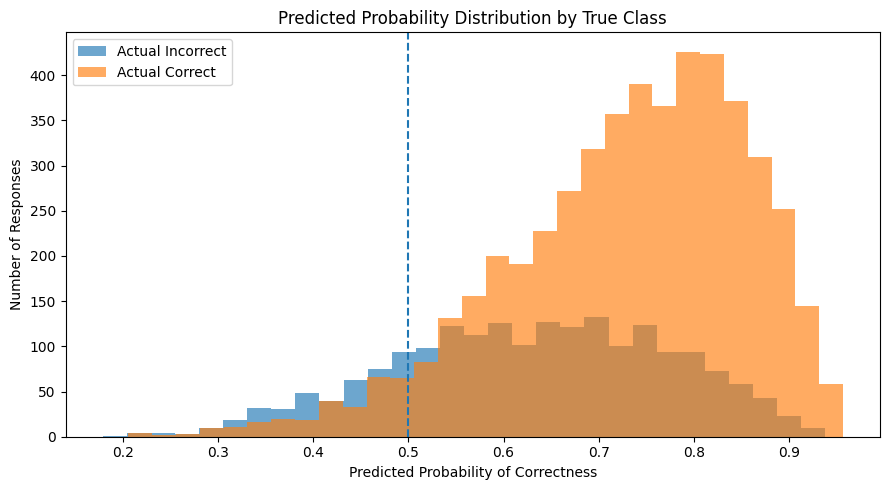

In [13]:
import matplotlib.pyplot as plt


figures_dir = reproduction_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)


positive_probability = validation_predictions.loc[
    validation_predictions["correct"].eq(1), "probability"
]

negative_probability = validation_predictions.loc[
    validation_predictions["correct"].eq(0), "probability"
]


plt.figure(figsize=(9, 5))

plt.hist(negative_probability, bins=30, alpha=0.65, label="Actual Incorrect")
plt.hist(positive_probability, bins=30, alpha=0.65, label="Actual Correct")

plt.axvline(0.5, linestyle="--", linewidth=1.5)

plt.title("Predicted Probability Distribution by True Class")
plt.xlabel("Predicted Probability of Correctness")
plt.ylabel("Number of Responses")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "probability_distribution_by_class.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 1.7 Saved and Reproduced Metric Comparison

This plot compares the originally saved baseline metrics with the newly reproduced metrics.

Nearly overlapping bars provide visual confirmation that the saved model, validation matrix, labels and row ordering belong to the same baseline experiment.

This visual check complements the exact numerical probability comparison performed earlier.

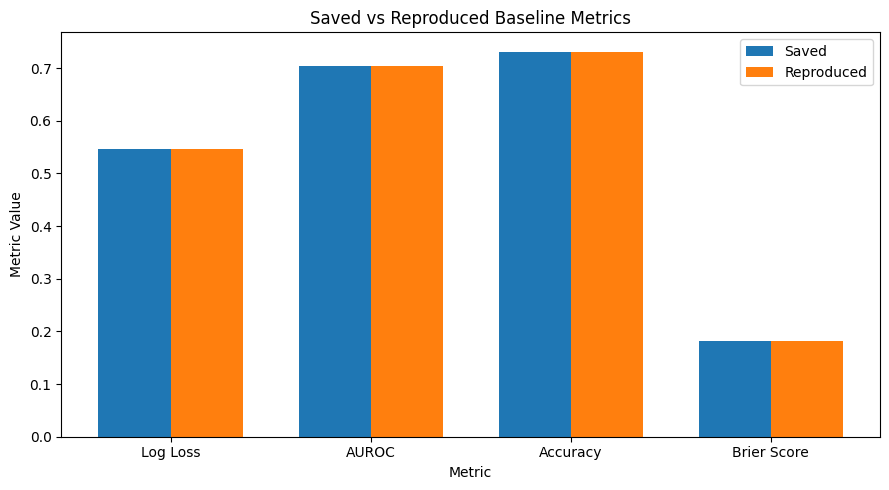

In [14]:
plot_metrics = metric_comparison.copy()

metric_positions = np.arange(len(plot_metrics))
bar_width = 0.36


plt.figure(figsize=(9, 5))

plt.bar(
    metric_positions - bar_width / 2,
    plot_metrics["Saved"],
    width=bar_width,
    label="Saved"
)

plt.bar(
    metric_positions + bar_width / 2,
    plot_metrics["Reproduced"],
    width=bar_width,
    label="Reproduced"
)

plt.xticks(metric_positions, plot_metrics["Metric"])
plt.title("Saved vs Reproduced Baseline Metrics")
plt.xlabel("Metric")
plt.ylabel("Metric Value")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "saved_vs_reproduced_metrics.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Step 1 — Baseline Reproduction Findings

The saved and reproduced results are visually identical across all reported metrics. The reproduced model achieves approximately **0.545 Log Loss**, **0.704 AUROC**, **0.73 Accuracy** and **0.18 Brier Score**, confirming that the correct `word_logistic` model, validation matrix, labels and row ordering were successfully recovered. This establishes a reliable historical reference for the next stages of analysis.

The probability-distribution plot shows that responses with target `1` generally receive higher predicted probabilities, with most correct responses concentrated between approximately **0.65 and 0.90**. Incorrect responses are positioned relatively further left, but their distribution remains broad and extends well above the `0.50` decision threshold.

A substantial overlap exists between the two classes, particularly between approximately **0.55 and 0.75**. This indicates that the baseline captures useful predictive signal but cannot cleanly separate correct and incorrect outcomes. Many incorrect responses receive moderately high correctness probabilities, suggesting a possible **false-positive and overconfidence problem**. These cases may contribute disproportionately to Log Loss.

The model also appears to produce relatively few very low probabilities. This may partly reflect the high positive-class prevalence in the dataset and suggests that the baseline is generally biased toward predicting correctness. However, calibration cannot be concluded from this histogram alone and must later be examined using reliability diagrams, calibration slope and confidence-bin analysis.

Overall, Step 1 confirms that the baseline artifact is fully reproducible. At the same time, the visible class overlap shows that the main research challenge is not artifact inconsistency but understanding why some incorrect responses receive high probabilities and why some correct responses remain underconfident.

> ### Key Research Insight
>
> - The saved baseline has been reproduced successfully.
> - Correct responses generally receive higher probabilities than incorrect responses.
> - Considerable overlap remains between the two target classes.
> - Many incorrect responses are predicted above the `0.50` threshold.
> - The baseline has useful ranking ability but still produces potentially costly false positives.
> - Detailed conclusions require complete grouped OOF, loss-tail and calibration analysis.

>Model artifact ঠিক আছে, কিন্তু probability separation perfect নয়। বিশেষ করে incorrect class-এর অনেক row-কে model high probability দিচ্ছে। Step 2-এর OOF analysis-এ প্রথমে এই confident false-positive behaviour যাচাই করা হবে।

# Step 2 — Leakage-Safe Five-Fold OOF Validation and Structural Relationship Analysis

## Objective

This step rebuilds the exact `word_logistic` baseline under a frozen five-fold session-grouped validation framework.

Unlike the original single 80/20 holdout, every labelled response will receive an out-of-fold prediction from a model that has never seen that response or its session during training.

## Main Research Goals

1. Measure the true generalisation performance of the baseline.
2. Compare the original holdout result with five-fold OOF performance.
3. measure fold-to-fold stability.
4. analyse relationships between transcript structure, target, prediction, residual and Log Loss.
5. determine whether the model distinguishes different learning objectives within the same session.
6. identify difficult objectives, long-context failures and high-risk structural slices.
7. establish the trusted OOF foundation for later loss analysis and SHAP research.

## Leakage-Control Rule

For every fold:

- the TF-IDF vectorizer is fitted only on the training folds;
- validation text does not influence vocabulary or IDF values;
- all rows belonging to one `session_id` remain in the same fold;
- the exact baseline text representation and Logistic Regression configuration are preserved.

In [15]:
import gc, hashlib, json, re, unicodedata

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold


pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

oof_root = analysis_root / "02_oof_analysis"

fold_design_dir = oof_root / "00_fold_design"
fold_models_dir = oof_root / "01_fold_models"
predictions_dir = oof_root / "02_oof_predictions"
stability_dir = oof_root / "03_fold_stability"
relationship_dir = oof_root / "04_relationship_analysis"
structure_dir = oof_root / "05_session_objective_structure"
figures_dir = oof_root / "06_figures"
report_dir = oof_root / "07_report"

step2_folders = [fold_design_dir, fold_models_dir, predictions_dir, stability_dir, relationship_dir, structure_dir, figures_dir, report_dir]

for folder in step2_folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Step 2 folders created successfully.")
print("Output root:", oof_root)

Step 2 folders created successfully.
Output root: C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis\02_oof_analysis


## 2.1 Build the Complete Analysis Dataset

The complete master dataset is used rather than the previous train-validation matrices.

The baseline text representation is reconstructed exactly as:

```text
[OBJECTIVE] learning objective
[TRANSCRIPT] complete transcript

In [16]:
master_file = dataset_root / "outputs" / "03_master_dataset" / "master_train.parquet"

df = pd.read_parquet(master_file)
df.columns = df.columns.astype(str).str.strip().str.lower()

required_columns = ["response_id", "session_id", "learning_objective", "transcript_text", "correct"]
missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

df["response_id"] = df["response_id"].astype("string").str.strip()
df["session_id"] = df["session_id"].astype("string").str.strip()
df["correct"] = pd.to_numeric(df["correct"], errors="coerce").astype(np.int8)

text_columns = ["learning_objective", "transcript_text", "student_text", "tutor_text"]

for column in text_columns:
    if column not in df.columns:
        df[column] = ""

    df[column] = df[column].fillna("").astype("string").str.replace(r"\s+", " ", regex=True).str.strip()


def normalise_objective(text):
    text = unicodedata.normalize("NFKC", str(text)).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return re.sub(r"[^\w\s%+\-./]", "", text)


def make_objective_key(text):
    normalised = normalise_objective(text)
    return hashlib.sha1(normalised.encode("utf-8")).hexdigest()[:16]


df["objective_key"] = df["learning_objective"].map(make_objective_key)
df["model_text"] = "[OBJECTIVE] " + df["learning_objective"] + "\n[TRANSCRIPT] " + df["transcript_text"]

if "total_words" not in df.columns:
    df["total_words"] = df["transcript_text"].str.split().str.len()

if "total_turns" not in df.columns:
    df["total_turns"] = df["transcript_text"].str.count(r"\n") + 1

df["objective_frequency"] = df.groupby("objective_key")["response_id"].transform("size")
df["responses_per_session"] = df.groupby("session_id")["response_id"].transform("size")
df["objectives_per_session"] = df.groupby("session_id")["objective_key"].transform("nunique")
df["mixed_label_session"] = df.groupby("session_id")["correct"].transform("nunique").gt(1)
df["objective_words"] = df["learning_objective"].str.split().str.len()

objective_support = df.groupby("objective_key").size()
rare_cutoff = max(10, int(objective_support.quantile(0.25)))
df["rare_objective"] = df["objective_frequency"].le(rare_cutoff)

numerical_features = [
    "total_turns", "total_words", "session_duration_minutes", "turns_per_minute",
    "student_turns", "tutor_turns", "student_turn_ratio", "student_word_ratio",
    "avg_student_words_per_turn", "avg_tutor_words_per_turn",
    "student_short_turn_ratio", "student_long_turn_ratio",
    "student_numeric_turn_ratio", "student_question_ratio",
    "tutor_question_ratio", "student_response_after_tutor_question_ratio",
    "speaker_switch_rate", "longest_tutor_streak_ratio",
    "longest_student_streak_ratio", "background_turn_ratio"
]

numerical_features = [column for column in numerical_features if column in df.columns]

analysis_overview = pd.DataFrame({
    "Item": ["Responses", "Sessions", "Learning objectives", "Positive rate", "Rare-objective cutoff", "Numerical features"],
    "Value": [len(df), df["session_id"].nunique(), df["objective_key"].nunique(), df["correct"].mean(), rare_cutoff, len(numerical_features)]
})

display(analysis_overview)

,Item,Value
0,Responses,"35,072.0000"
1,Sessions,"22,821.0000"
2,Learning objectives,396.0000
3,Positive rate,0.7025
4,Rare-objective cutoff,10.0000
5,Numerical features,20.0000


In [17]:
metadata_columns = [
    "response_id", "session_id", "objective_key", "learning_objective", "correct",
    "objective_frequency", "responses_per_session", "objectives_per_session",
    "mixed_label_session", "objective_words", "rare_objective"
] + numerical_features

metadata_columns = list(dict.fromkeys(metadata_columns))

df[metadata_columns].to_parquet(fold_design_dir / "analysis_metadata.parquet", index=False)

print("Analysis metadata saved.")
display(df[metadata_columns].head())

Analysis metadata saved.


,response_id,session_id,objective_key,learning_objective,correct,objective_frequency,responses_per_session,objectives_per_session,mixed_label_session,objective_words,rare_objective,total_turns,total_words,session_duration_minutes,turns_per_minute,student_turns,tutor_turns,student_turn_ratio,student_word_ratio,avg_student_words_per_turn,avg_tutor_words_per_turn,student_short_turn_ratio,student_long_turn_ratio,student_numeric_turn_ratio,student_question_ratio,tutor_question_ratio,student_response_after_tutor_question_ratio,speaker_switch_rate,longest_tutor_streak_ratio,longest_student_streak_ratio,background_turn_ratio
0,aaaavsh,bcaufvc,e0021f1db5edb8e4,Knowing the value of each digit in numbers with up to 2 decimal places.,1,1267,4,4,False,14,False,330,3405,44.7500,7.3743,150,169,0.4545,0.2822,6.4067,13.6391,0.4533,0.2133,0.3333,0.1333,0.5444,0.9022,0.8491,0.0414,0.0267,0.0333
1,aaabhzi,eyutanf,833b44236d32225d,Adding and subtracting tens to a 2-digit number.,1,44,3,3,False,8,False,280,5280,44.8500,6.2430,123,144,0.4393,0.3680,15.7967,22.1181,0.3740,0.4228,0.3252,0.1301,0.5556,0.7875,0.8421,0.0208,0.0244,0.0464
2,aaahpnz,juptkxd,f326742f5c5b9287,Comparing and ordering fractions by finding a common denominator.,0,211,1,1,False,9,False,291,4638,44.9500,6.4739,139,139,0.4777,0.3952,13.1871,18.3669,0.4245,0.3597,0.5108,0.1223,0.5612,0.8846,0.8520,0.0216,0.0360,0.0447
3,aaajpom,ntwkcfj,30964dfabcf6cc4b,Comparing fractions using reasoning.,0,510,4,4,True,4,False,265,4792,45.0667,5.8802,124,132,0.4679,0.2619,10.1210,25.9167,0.4194,0.2984,0.3790,0.1694,0.7273,0.8646,0.8196,0.0227,0.0323,0.0340
4,aaamwux,jqriibm,94849339246d7bf4,Counting in multiples.,0,525,1,1,False,3,False,270,2640,35.0333,7.7069,102,153,0.3778,0.2197,5.6863,13.0131,0.5196,0.1667,0.3725,0.1176,0.6797,0.7404,0.7480,0.0392,0.0196,0.0556


## 2.2 Select a Balanced Frozen Fold Map

Several candidate five-fold maps are generated using different random seeds.

The fold map is selected using metadata balance rather than model performance. This prevents the validation structure from being chosen because it produces a favourable score.

The balance score considers:

- response count;
- session count;
- positive-label rate;
- multi-objective session share;
- mixed-label session share;
- transcript length;
- turn count;
- rare-objective share.

The selected fold map will be frozen and reused in all future experiments.

In [18]:
session_profile = (
    df.groupby("session_id")
    .agg(
        n_responses=("response_id", "size"),
        n_objectives=("objective_key", "nunique"),
        positive_rate=("correct", "mean"),
        total_words=("total_words", "first"),
        total_turns=("total_turns", "first")
    )
    .reset_index()
)

session_profile["multi_objective"] = session_profile["n_objectives"].gt(1)
session_profile["mixed_label"] = session_profile["positive_rate"].between(0, 1, inclusive="neither")

global_positive_rate = df["correct"].mean()
global_rare_share = df["rare_objective"].mean()
global_multi_share = session_profile["multi_objective"].mean()
global_mixed_share = session_profile["mixed_label"].mean()
global_median_words = session_profile["total_words"].median()
global_median_turns = session_profile["total_turns"].median()


def create_fold_ids(seed):
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_ids = np.full(len(df), -1, dtype=np.int8)

    for fold_id, (_, valid_index) in enumerate(splitter.split(df, df["correct"], df["session_id"])):
        fold_ids[valid_index] = fold_id

    return fold_ids


def build_fold_summary(fold_ids):
    response_table = df[["response_id", "session_id", "objective_key", "correct", "rare_objective"]].copy()
    response_table["fold_id"] = fold_ids

    response_summary = (
        response_table.groupby("fold_id")
        .agg(
            n_rows=("response_id", "size"),
            positive_rate=("correct", "mean"),
            unique_objectives=("objective_key", "nunique"),
            rare_objective_share=("rare_objective", "mean")
        )
        .reset_index()
    )

    session_folds = response_table[["session_id", "fold_id"]].drop_duplicates()
    session_folds = session_folds.merge(session_profile, on="session_id", how="left")

    session_summary = (
        session_folds.groupby("fold_id")
        .agg(
            n_sessions=("session_id", "size"),
            multi_objective_share=("multi_objective", "mean"),
            mixed_label_share=("mixed_label", "mean"),
            median_total_words=("total_words", "median"),
            median_total_turns=("total_turns", "median")
        )
        .reset_index()
    )

    return response_summary.merge(session_summary, on="fold_id", how="left")


def calculate_balance_score(summary):
    target_rows = len(df) / 5
    target_sessions = len(session_profile) / 5

    score = summary["n_rows"].div(target_rows).sub(1).abs().mean()
    score += summary["n_sessions"].div(target_sessions).sub(1).abs().mean()
    score += 4 * summary["positive_rate"].sub(global_positive_rate).abs().mean()
    score += 2 * summary["multi_objective_share"].sub(global_multi_share).abs().mean()
    score += 2 * summary["mixed_label_share"].sub(global_mixed_share).abs().mean()
    score += summary["median_total_words"].div(global_median_words).sub(1).abs().mean()
    score += summary["median_total_turns"].div(global_median_turns).sub(1).abs().mean()
    score += 2 * summary["rare_objective_share"].sub(global_rare_share).abs().mean()

    return float(score)

In [19]:
candidate_rows = []

for seed in range(42, 57):
    candidate_fold_ids = create_fold_ids(seed)
    candidate_summary = build_fold_summary(candidate_fold_ids)

    candidate_rows.append({
        "seed": seed,
        "balance_score": calculate_balance_score(candidate_summary),
        "minimum_rows": candidate_summary["n_rows"].min(),
        "maximum_rows": candidate_summary["n_rows"].max(),
        "minimum_positive_rate": candidate_summary["positive_rate"].min(),
        "maximum_positive_rate": candidate_summary["positive_rate"].max()
    })

candidate_scores = pd.DataFrame(candidate_rows).sort_values("balance_score").reset_index(drop=True)

selected_seed = int(candidate_scores.iloc[0]["seed"])
selected_fold_ids = create_fold_ids(selected_seed)

df["fold_id"] = selected_fold_ids
selected_fold_summary = build_fold_summary(selected_fold_ids)

candidate_scores.to_csv(fold_design_dir / "candidate_fold_scores.csv", index=False)
selected_fold_summary.to_csv(fold_design_dir / "selected_fold_summary.csv", index=False)

fold_manifest = df[["response_id", "session_id", "fold_id"]].copy()
fold_manifest.to_parquet(fold_design_dir / "fold_manifest.parquet", index=False)

print("Selected fold seed:", selected_seed)
display(candidate_scores.head())
display(selected_fold_summary)

Selected fold seed: 43


,seed,balance_score,minimum_rows,maximum_rows,minimum_positive_rate,maximum_positive_rate
0,43,0.0416,6980,7044,0.6989,0.7108
1,53,0.0461,6989,7055,0.6928,0.7089
2,54,0.0465,6968,7049,0.6943,0.7121
3,46,0.0475,6926,7167,0.6942,0.7073
4,52,0.0483,6952,7068,0.6959,0.7112


,fold_id,n_rows,positive_rate,unique_objectives,rare_objective_share,n_sessions,multi_objective_share,mixed_label_share,median_total_words,median_total_turns
0,0,6980,0.7006,277,0.0172,4590,0.3586,0.1392,"3,674.0000",267.0000
1,1,7018,0.6989,279,0.0161,4569,0.3690,0.1418,"3,695.0000",269.0000
2,2,7019,0.7108,274,0.0191,4570,0.3630,0.1372,"3,675.5000",265.0000
3,3,7011,0.6996,285,0.0183,4541,0.3695,0.1394,"3,695.0000",268.0000
4,4,7044,0.7024,278,0.0176,4551,0.3724,0.1450,"3,665.0000",268.0000


In [20]:
session_fold_count = df.groupby("session_id")["fold_id"].nunique()
maximum_folds_per_session = int(session_fold_count.max())

fold_validation = pd.DataFrame({
    "Check": ["All rows assigned", "Maximum folds per session", "Total folds"],
    "Result": [df["fold_id"].ge(0).all(), maximum_folds_per_session, df["fold_id"].nunique()]
})

display(fold_validation)

,Check,Result
0,All rows assigned,True
1,Maximum folds per session,1
2,Total folds,5


## 2.3 Fold-Balance Visualisation

The heatmap shows the relative structural position of each fold.

Values near zero indicate that a fold is close to the five-fold average. Large positive or negative values indicate that the fold contains an unusually high or low concentration of a particular structural property.

This is a fold-design diagnostic, not a model-performance plot.

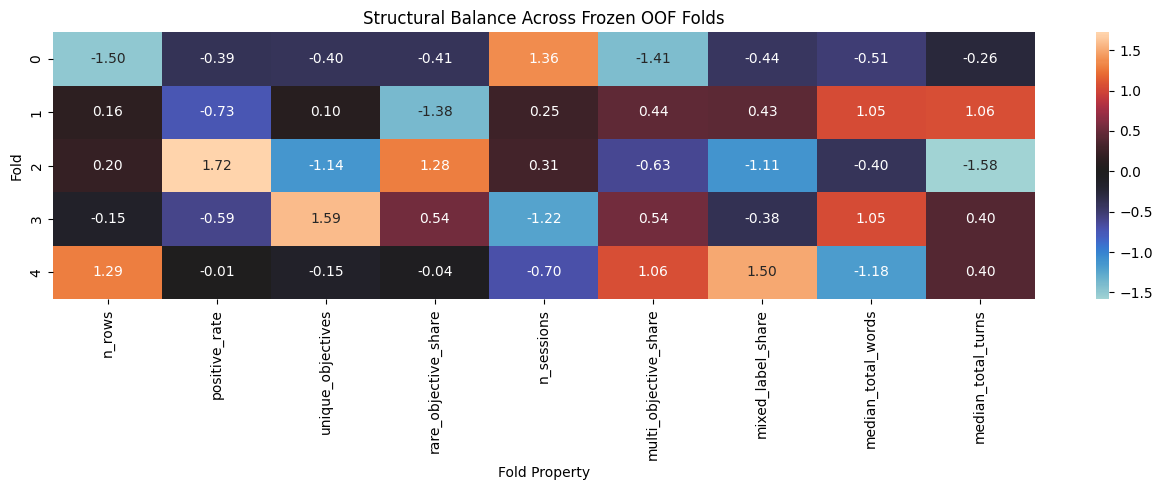

In [21]:
balance_columns = [
    "n_rows", "positive_rate", "unique_objectives", "rare_objective_share",
    "n_sessions", "multi_objective_share", "mixed_label_share",
    "median_total_words", "median_total_turns"
]

balance_view = selected_fold_summary.set_index("fold_id")[balance_columns].copy()
balance_std = balance_view.std().replace(0, 1)
balance_z = (balance_view - balance_view.mean()) / balance_std

plt.figure(figsize=(13, 5))
sns.heatmap(balance_z, annot=True, fmt=".2f", center=0)
plt.title("Structural Balance Across Frozen OOF Folds")
plt.xlabel("Fold Property")
plt.ylabel("Fold")
plt.tight_layout()
plt.savefig(figures_dir / "fold_balance_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 2.4 Train the Exact Baseline Across Five Folds

The baseline configuration is preserved exactly:

### TF-IDF

- lowercase text;
- Unicode accent stripping;
- unigrams and bigrams;
- minimum document frequency of 2;
- maximum document frequency of 0.995;
- maximum 60,000 features;
- sublinear term frequency;
- single-character mathematical tokens retained.

### Logistic Regression

- `saga` solver;
- L2 regularisation;
- default `C = 1.0`;
- maximum 500 iterations;
- fixed random state of 42.

Each fold receives its own vectorizer and model artifact.

In [22]:
def build_word_vectorizer():
    return TfidfVectorizer(
        lowercase=True, strip_accents="unicode", token_pattern=r"(?u)\b\w+\b",
        ngram_range=(1, 2), min_df=2, max_df=0.995,
        max_features=60000, sublinear_tf=True, dtype=np.float32
    )


def build_word_model():
    return LogisticRegression(solver="saga", max_iter=500, random_state=42, n_jobs=-1)


def calculate_metrics(y_true, probability):
    probability = np.clip(probability, 1e-6, 1 - 1e-6)
    hard_prediction = probability >= 0.5

    return {
        "log_loss": log_loss(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "accuracy": accuracy_score(y_true, hard_prediction),
        "brier_score": brier_score_loss(y_true, probability),
        "positive_rate": np.mean(y_true),
        "mean_probability": np.mean(probability)
    }

In [25]:
def make_json_safe(value):
    if isinstance(value, dict):
        return {key: make_json_safe(item) for key, item in value.items()}

    if isinstance(value, (list, tuple)):
        return [make_json_safe(item) for item in value]

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    return value


oof_probability = np.full(len(df), np.nan, dtype=np.float32)
fold_metric_rows = []

for fold_id in range(5):
    fold_dir = fold_models_dir / f"fold_{fold_id}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    train_index = df["fold_id"].ne(fold_id)
    valid_index = df["fold_id"].eq(fold_id)

    train_text = df.loc[train_index, "model_text"]
    valid_text = df.loc[valid_index, "model_text"]

    y_train_fold = df.loc[train_index, "correct"].to_numpy()
    y_valid_fold = df.loc[valid_index, "correct"].to_numpy()

    vectorizer = build_word_vectorizer()
    model = build_word_model()

    X_train_fold = vectorizer.fit_transform(train_text)
    X_valid_fold = vectorizer.transform(valid_text)

    model.fit(X_train_fold, y_train_fold)

    fold_probability = model.predict_proba(X_valid_fold)[:, 1]
    fold_probability = np.clip(fold_probability, 1e-6, 1 - 1e-6)

    oof_probability[valid_index] = fold_probability.astype(np.float32)

    fold_metrics = calculate_metrics(y_valid_fold, fold_probability)
    fold_metrics["fold_id"] = fold_id
    fold_metrics["train_rows"] = int(train_index.sum())
    fold_metrics["validation_rows"] = int(valid_index.sum())
    fold_metrics["feature_count"] = int(X_train_fold.shape[1])

    fold_metrics = make_json_safe(fold_metrics)
    fold_metric_rows.append(fold_metrics)

    joblib.dump(vectorizer, fold_dir / "word_tfidf_vectorizer.joblib")
    joblib.dump(model, fold_dir / "word_logistic.joblib")

    np.savez_compressed(
        fold_dir / "linear_coefficients.npz",
        coef=model.coef_.astype(np.float32),
        intercept=model.intercept_.astype(np.float32)
    )

    df.loc[
        valid_index,
        ["response_id", "session_id", "fold_id"]
    ].to_parquet(
        fold_dir / "validation_ids.parquet",
        index=False
    )

    with open(fold_dir / "fold_metrics.json", "w", encoding="utf-8") as file:
        json.dump(fold_metrics, file, indent=2)

    print(
        f"Fold {fold_id} | "
        f"Log Loss: {fold_metrics['log_loss']:.6f} | "
        f"AUROC: {fold_metrics['roc_auc']:.6f} | "
        f"Features: {fold_metrics['feature_count']:,}"
    )

    del vectorizer, model, X_train_fold, X_valid_fold
    gc.collect()


fold_metrics = pd.DataFrame(fold_metric_rows)
fold_metrics = fold_metrics.sort_values("fold_id").reset_index(drop=True)

fold_metrics.to_csv(
    stability_dir / "fold_metrics.csv",
    index=False
)

print("\nFive-fold training completed successfully.")
display(fold_metrics)

Fold 0 | Log Loss: 0.557688 | AUROC: 0.700257 | Features: 60,000
Fold 1 | Log Loss: 0.561402 | AUROC: 0.691693 | Features: 60,000
Fold 2 | Log Loss: 0.546944 | AUROC: 0.706460 | Features: 60,000
Fold 3 | Log Loss: 0.554737 | AUROC: 0.707325 | Features: 60,000
Fold 4 | Log Loss: 0.556537 | AUROC: 0.698027 | Features: 60,000

Five-fold training completed successfully.


,log_loss,roc_auc,accuracy,brier_score,positive_rate,mean_probability,fold_id,train_rows,validation_rows,feature_count
0,0.5577,0.7003,0.7183,0.1881,0.7006,0.6999,0,28092,6980,60000
1,0.5614,0.6917,0.7193,0.1893,0.6989,0.7075,1,28054,7018,60000
2,0.5469,0.7065,0.7259,0.1834,0.7108,0.7038,2,28053,7019,60000
3,0.5547,0.7073,0.7216,0.1867,0.6996,0.7045,3,28061,7011,60000
4,0.5565,0.6980,0.7239,0.1872,0.7024,0.7051,4,28028,7044,60000


## 2.5 Build the Complete OOF Prediction Table

Each row now receives a probability from a model that did not train on that row or its session.

Initial diagnostic variables are added:

- probability assigned to the true class;
- individual response Log Loss;
- residual;
- absolute probability error;
- confidence distance from the `0.50` boundary.

Detailed error bands and catastrophic-error analysis will be performed in Step 3.

In [26]:
if np.isnan(oof_probability).any():
    raise ValueError("Some rows did not receive an OOF prediction.")

oof_columns = [
    "response_id", "session_id", "objective_key", "learning_objective",
    "correct", "fold_id", "objective_frequency", "responses_per_session",
    "objectives_per_session", "mixed_label_session", "objective_words",
    "rare_objective"
] + numerical_features

oof_columns = list(dict.fromkeys(oof_columns))
oof = df[oof_columns].copy()

oof["probability"] = oof_probability
oof["hard_prediction"] = oof["probability"].ge(0.5).astype(np.int8)
oof["true_class_probability"] = np.where(oof["correct"].eq(1), oof["probability"], 1 - oof["probability"])
oof["sample_log_loss"] = -np.log(oof["true_class_probability"].clip(1e-6, 1 - 1e-6))
oof["residual"] = oof["correct"] - oof["probability"]
oof["absolute_error"] = oof["residual"].abs()
oof["confidence"] = (oof["probability"] - 0.5).abs()

oof.to_parquet(predictions_dir / "word_logistic_oof.parquet", index=False)

display(oof.head())

,response_id,session_id,objective_key,learning_objective,correct,fold_id,objective_frequency,responses_per_session,objectives_per_session,mixed_label_session,objective_words,rare_objective,total_turns,total_words,session_duration_minutes,turns_per_minute,student_turns,tutor_turns,student_turn_ratio,student_word_ratio,avg_student_words_per_turn,avg_tutor_words_per_turn,student_short_turn_ratio,student_long_turn_ratio,student_numeric_turn_ratio,student_question_ratio,tutor_question_ratio,student_response_after_tutor_question_ratio,speaker_switch_rate,longest_tutor_streak_ratio,longest_student_streak_ratio,background_turn_ratio,probability,hard_prediction,true_class_probability,sample_log_loss,residual,absolute_error,confidence
0,aaaavsh,bcaufvc,e0021f1db5edb8e4,Knowing the value of each digit in numbers with up to 2 decimal places.,1,0,1267,4,4,False,14,False,330,3405,44.7500,7.3743,150,169,0.4545,0.2822,6.4067,13.6391,0.4533,0.2133,0.3333,0.1333,0.5444,0.9022,0.8491,0.0414,0.0267,0.0333,0.9087,1,0.9087,0.0958,0.0913,0.0913,0.4087
1,aaabhzi,eyutanf,833b44236d32225d,Adding and subtracting tens to a 2-digit number.,1,4,44,3,3,False,8,False,280,5280,44.8500,6.2430,123,144,0.4393,0.3680,15.7967,22.1181,0.3740,0.4228,0.3252,0.1301,0.5556,0.7875,0.8421,0.0208,0.0244,0.0464,0.8606,1,0.8606,0.1501,0.1394,0.1394,0.3606
2,aaahpnz,juptkxd,f326742f5c5b9287,Comparing and ordering fractions by finding a common denominator.,0,2,211,1,1,False,9,False,291,4638,44.9500,6.4739,139,139,0.4777,0.3952,13.1871,18.3669,0.4245,0.3597,0.5108,0.1223,0.5612,0.8846,0.8520,0.0216,0.0360,0.0447,0.7420,1,0.2580,1.3547,-0.7420,0.7420,0.2420
3,aaajpom,ntwkcfj,30964dfabcf6cc4b,Comparing fractions using reasoning.,0,0,510,4,4,True,4,False,265,4792,45.0667,5.8802,124,132,0.4679,0.2619,10.1210,25.9167,0.4194,0.2984,0.3790,0.1694,0.7273,0.8646,0.8196,0.0227,0.0323,0.0340,0.7524,1,0.2476,1.3961,-0.7524,0.7524,0.2524
4,aaamwux,jqriibm,94849339246d7bf4,Counting in multiples.,0,0,525,1,1,False,3,False,270,2640,35.0333,7.7069,102,153,0.3778,0.2197,5.6863,13.0131,0.5196,0.1667,0.3725,0.1176,0.6797,0.7404,0.7480,0.0392,0.0196,0.0556,0.6341,1,0.3659,1.0054,-0.6341,0.6341,0.1341


In [27]:
pooled_metrics = calculate_metrics(oof["correct"].to_numpy(), oof["probability"].to_numpy())

pooled_summary = pd.DataFrame({
    "Metric": ["Log Loss", "AUROC", "Accuracy", "Brier Score", "Positive Rate", "Mean Probability"],
    "Value": [
        pooled_metrics["log_loss"], pooled_metrics["roc_auc"],
        pooled_metrics["accuracy"], pooled_metrics["brier_score"],
        pooled_metrics["positive_rate"], pooled_metrics["mean_probability"]
    ]
})

fold_stability = pd.DataFrame({
    "Statistic": ["Mean fold Log Loss", "Median fold Log Loss", "Worst fold Log Loss", "Fold Log Loss standard deviation", "Best-worst fold gap"],
    "Value": [
        fold_metrics["log_loss"].mean(),
        fold_metrics["log_loss"].median(),
        fold_metrics["log_loss"].max(),
        fold_metrics["log_loss"].std(),
        fold_metrics["log_loss"].max() - fold_metrics["log_loss"].min()
    ]
})

pooled_summary.to_csv(predictions_dir / "oof_summary.csv", index=False)
fold_stability.to_csv(stability_dir / "fold_stability_summary.csv", index=False)

display(pooled_summary)
display(fold_stability)

,Metric,Value
0,Log Loss,0.5555
1,AUROC,0.7007
2,Accuracy,0.7218
3,Brier Score,0.1870
4,Positive Rate,0.7025
5,Mean Probability,0.7042


,Statistic,Value
0,Mean fold Log Loss,0.5555
1,Median fold Log Loss,0.5565
2,Worst fold Log Loss,0.5614
3,Fold Log Loss standard deviation,0.0053
4,Best-worst fold gap,0.0145


## 2.6 Session-Clustered OOF Uncertainty and Holdout Comparison

Because responses from the same session are not independent, bootstrap uncertainty is calculated by resampling complete sessions rather than individual rows.

The original Step 1 holdout is compared with:

- each OOF fold;
- the mean fold result;
- the pooled OOF result;
- the worst fold.

A lower original holdout Log Loss than pooled OOF may indicate that the original split was relatively favourable.

In [28]:
session_loss = (
    oof.groupby("session_id")
    .agg(loss_sum=("sample_log_loss", "sum"), n_rows=("response_id", "size"))
    .reset_index()
)

loss_values = session_loss["loss_sum"].to_numpy()
row_values = session_loss["n_rows"].to_numpy()

rng = np.random.default_rng(20260804)
bootstrap_log_loss = np.empty(1000)

for iteration in range(1000):
    sampled_positions = rng.integers(0, len(session_loss), len(session_loss))
    bootstrap_log_loss[iteration] = loss_values[sampled_positions].sum() / row_values[sampled_positions].sum()

bootstrap_lower = float(np.quantile(bootstrap_log_loss, 0.025))
bootstrap_upper = float(np.quantile(bootstrap_log_loss, 0.975))

bootstrap_summary = pd.DataFrame({
    "Metric": ["Pooled OOF Log Loss", "Bootstrap lower 95%", "Bootstrap upper 95%"],
    "Value": [pooled_metrics["log_loss"], bootstrap_lower, bootstrap_upper]
})

bootstrap_summary.to_csv(stability_dir / "bootstrap_log_loss_interval.csv", index=False)

display(bootstrap_summary)

,Metric,Value
0,Pooled OOF Log Loss,0.5555
1,Bootstrap lower 95%,0.5504
2,Bootstrap upper 95%,0.5604


In [29]:
step1_metrics = pd.read_csv(analysis_root / "01_baseline_reproduction" / "reproduction_metrics.csv")
step1_metric_map = dict(zip(step1_metrics["Metric"], step1_metrics["Value"]))

holdout_log_loss = float(step1_metric_map["Log Loss"])

comparison_rows = [{
    "Evaluation": "Step 1 holdout",
    "Log Loss": holdout_log_loss,
    "CI Lower": holdout_log_loss,
    "CI Upper": holdout_log_loss
}]

for _, row in fold_metrics.iterrows():
    comparison_rows.append({
        "Evaluation": f"OOF Fold {int(row['fold_id'])}",
        "Log Loss": row["log_loss"],
        "CI Lower": row["log_loss"],
        "CI Upper": row["log_loss"]
    })

comparison_rows.append({
    "Evaluation": "Pooled OOF",
    "Log Loss": pooled_metrics["log_loss"],
    "CI Lower": bootstrap_lower,
    "CI Upper": bootstrap_upper
})

holdout_oof_comparison = pd.DataFrame(comparison_rows)
holdout_oof_comparison.to_csv(predictions_dir / "holdout_oof_comparison.csv", index=False)

holdout_gap = pooled_metrics["log_loss"] - holdout_log_loss

print("OOF minus holdout Log Loss:", f"{holdout_gap:.6f}")
display(holdout_oof_comparison)

OOF minus holdout Log Loss: 0.009985


,Evaluation,Log Loss,CI Lower,CI Upper
0,Step 1 holdout,0.5455,0.5455,0.5455
1,OOF Fold 0,0.5577,0.5577,0.5577
2,OOF Fold 1,0.5614,0.5614,0.5614
3,OOF Fold 2,0.5469,0.5469,0.5469
4,OOF Fold 3,0.5547,0.5547,0.5547
5,OOF Fold 4,0.5565,0.5565,0.5565
6,Pooled OOF,0.5555,0.5504,0.5604


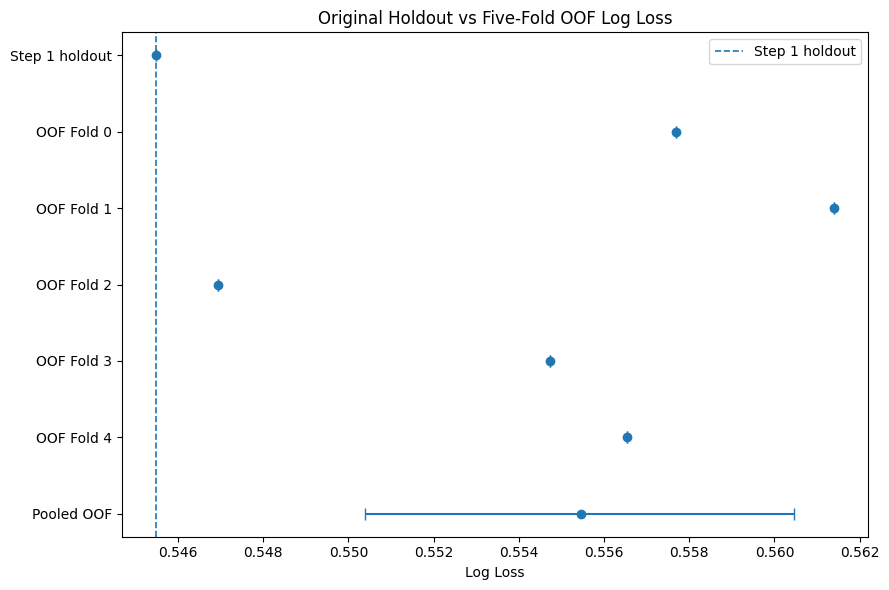

In [30]:
plot_data = holdout_oof_comparison.copy()
y_positions = np.arange(len(plot_data))

lower_error = plot_data["Log Loss"] - plot_data["CI Lower"]
upper_error = plot_data["CI Upper"] - plot_data["Log Loss"]

plt.figure(figsize=(9, 6))

plt.errorbar(
    plot_data["Log Loss"], y_positions,
    xerr=np.vstack([lower_error, upper_error]),
    fmt="o", capsize=4
)

plt.axvline(holdout_log_loss, linestyle="--", linewidth=1.2, label="Step 1 holdout")
plt.yticks(y_positions, plot_data["Evaluation"])
plt.gca().invert_yaxis()

plt.title("Original Holdout vs Five-Fold OOF Log Loss")
plt.xlabel("Log Loss")
plt.ylabel("")
plt.legend()
plt.tight_layout()

plt.savefig(figures_dir / "holdout_vs_oof_forest_plot.png", dpi=200, bbox_inches="tight")
plt.show()

## 2.7 OOF Probability Separation

The empirical cumulative distribution function shows the full probability distribution without depending on histogram-bin choices.

The plot helps answer:

- what proportion of incorrect responses receive probabilities above `0.50`;
- how many incorrect responses receive very high probabilities;
- how many correct responses remain underconfident;
- how much separation exists between the two classes.

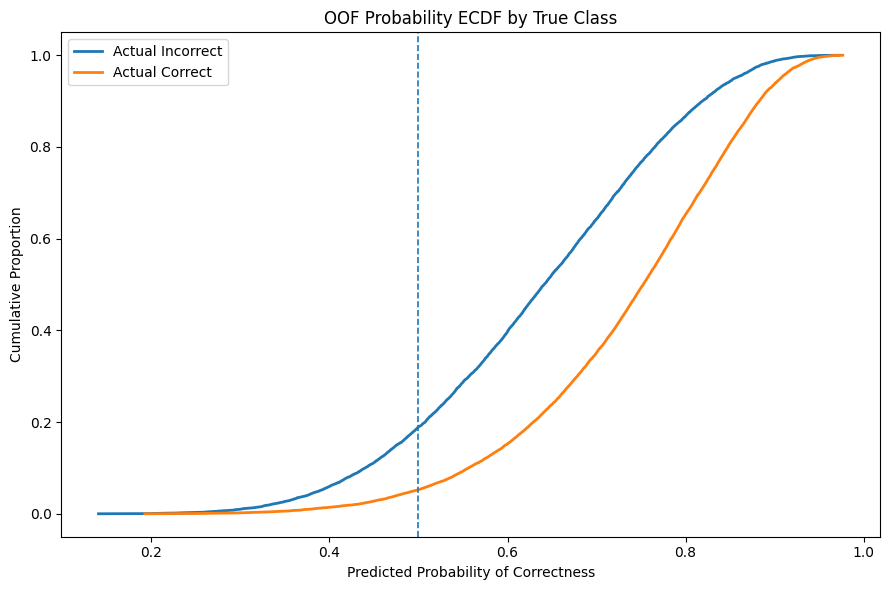

In [31]:
def calculate_ecdf(values):
    values = np.sort(np.asarray(values))
    cumulative = np.arange(1, len(values) + 1) / len(values)
    return values, cumulative


incorrect_values = oof.loc[oof["correct"].eq(0), "probability"]
correct_values = oof.loc[oof["correct"].eq(1), "probability"]

incorrect_x, incorrect_y = calculate_ecdf(incorrect_values)
correct_x, correct_y = calculate_ecdf(correct_values)

plt.figure(figsize=(9, 6))

plt.plot(incorrect_x, incorrect_y, linewidth=2, label="Actual Incorrect")
plt.plot(correct_x, correct_y, linewidth=2, label="Actual Correct")
plt.axvline(0.5, linestyle="--", linewidth=1.2)

plt.title("OOF Probability ECDF by True Class")
plt.xlabel("Predicted Probability of Correctness")
plt.ylabel("Cumulative Proportion")
plt.legend()
plt.tight_layout()

plt.savefig(figures_dir / "oof_probability_ecdf.png", dpi=200, bbox_inches="tight")
plt.show()

## 2.8 Response-Level Relationship Analysis

For every structural feature, four relationships are measured using Spearman correlation:

1. relationship with the actual target;
2. relationship with the model probability;
3. relationship with individual Log Loss;
4. relationship with residual error.

This separates genuine data signal from model behaviour.

### Diagnostic Interpretation

- **Aligned signal:** related to target and prediction in the same direction.
- **Missed signal:** related to target but weakly represented in predictions.
- **Shortcut risk:** related to model prediction but weakly related to the actual target.
- **Loss risk:** associated with higher individual Log Loss.

These labels are diagnostic rather than final causal conclusions.

In [32]:
structural_features = [
    "responses_per_session", "objectives_per_session",
    "objective_frequency", "objective_words", "rare_objective",
    "mixed_label_session"
]

relationship_features = numerical_features + structural_features
relationship_features = [column for column in dict.fromkeys(relationship_features) if column in oof.columns]

relationship_targets = ["correct", "probability", "sample_log_loss", "residual"]
relationship_rows = []

for feature in relationship_features:
    feature_values = pd.to_numeric(oof[feature], errors="coerce")

    for target in relationship_targets:
        relationship_rows.append({
            "feature": feature,
            "relationship": target,
            "spearman_correlation": feature_values.corr(oof[target], method="spearman")
        })

response_relationships = pd.DataFrame(relationship_rows)

signal_alignment = (
    response_relationships.pivot(index="feature", columns="relationship", values="spearman_correlation")
    .reset_index()
)

signal_alignment.columns.name = None


def identify_feature_family(feature):
    if feature.startswith("student"):
        return "Student behaviour"

    if feature.startswith("tutor"):
        return "Tutor behaviour"

    if feature.startswith("objective") or feature == "rare_objective":
        return "Objective structure"

    if "speaker" in feature or "streak" in feature:
        return "Dialogue structure"

    return "Session structure"


def identify_signal_type(row):
    target_value = row["correct"]
    prediction_value = row["probability"]

    if abs(target_value) >= 0.05 and abs(prediction_value) < 0.03:
        return "Missed signal"

    if abs(prediction_value) >= 0.05 and abs(target_value) < 0.03:
        return "Shortcut risk"

    if abs(target_value) >= 0.05 and abs(prediction_value) >= 0.05 and np.sign(target_value) == np.sign(prediction_value):
        return "Aligned signal"

    return "Weak or mixed"


signal_alignment["feature_family"] = signal_alignment["feature"].map(identify_feature_family)
signal_alignment["signal_type"] = signal_alignment.apply(identify_signal_type, axis=1)
signal_alignment["loss_risk"] = signal_alignment["sample_log_loss"].abs()
signal_alignment["ranking_score"] = signal_alignment[["correct", "probability", "sample_log_loss"]].abs().sum(axis=1)

response_relationships.to_csv(relationship_dir / "response_relationships.csv", index=False)
signal_alignment.to_csv(relationship_dir / "signal_alignment.csv", index=False)

display(signal_alignment.sort_values("ranking_score", ascending=False).head(15))

,feature,correct,probability,residual,sample_log_loss,feature_family,signal_type,loss_risk,ranking_score
8,objectives_per_session,0.1476,0.3661,-0.0766,-0.2410,Objective structure,Aligned signal,0.2410,0.7547
10,responses_per_session,0.1476,0.3661,-0.0766,-0.2410,Session structure,Aligned signal,0.2410,0.7547
13,student_long_turn_ratio,0.0834,0.2078,-0.0451,-0.1391,Student behaviour,Aligned signal,0.1391,0.4302
5,mixed_label_session,-0.1786,0.0328,-0.1603,0.1950,Session structure,Weak or mixed,0.1950,0.4063
0,avg_student_words_per_turn,0.0792,0.1957,-0.0410,-0.1297,Session structure,Aligned signal,0.1297,0.4046
17,student_short_turn_ratio,-0.0537,-0.1211,0.0200,0.0800,Student behaviour,Aligned signal,0.0800,0.2548
20,student_word_ratio,0.0481,0.1004,-0.0132,-0.0686,Student behaviour,Weak or mixed,0.0686,0.2171
7,objective_words,0.0364,0.0978,-0.0283,-0.0748,Objective structure,Weak or mixed,0.0748,0.2090
15,student_question_ratio,-0.0320,-0.0938,0.0281,0.0658,Student behaviour,Weak or mixed,0.0658,0.1915
22,total_words,0.0300,0.0921,-0.0300,-0.0678,Session structure,Shortcut risk,0.0678,0.1898


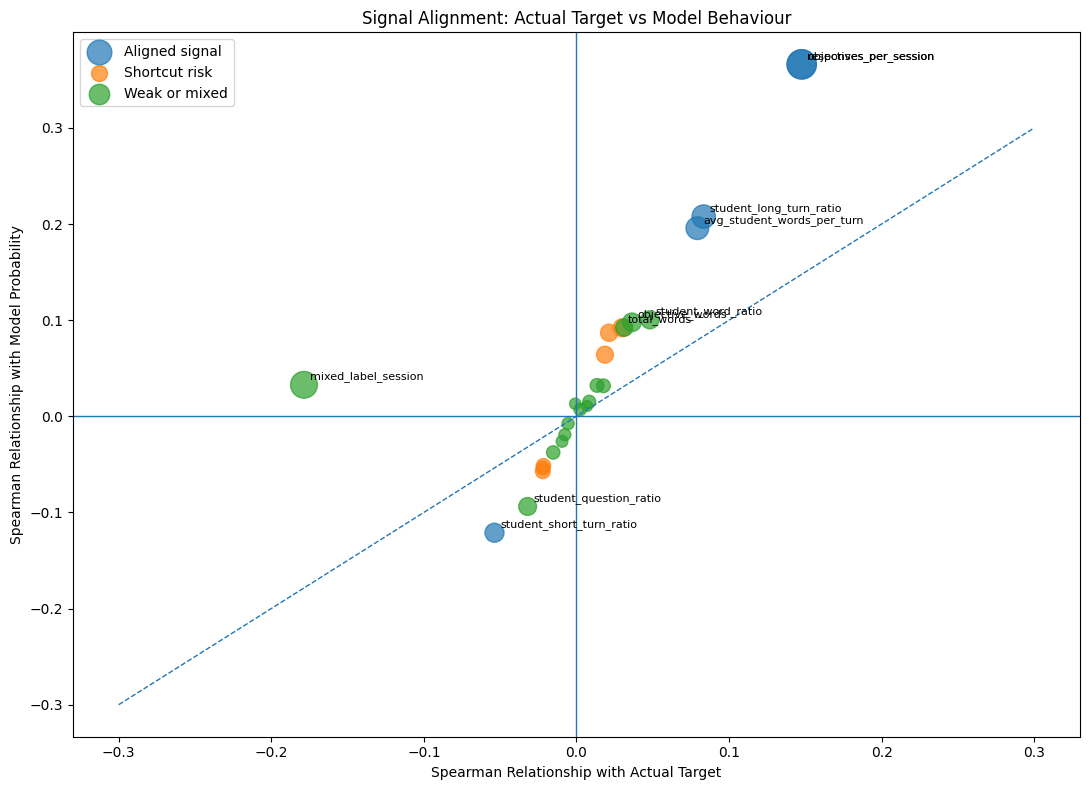

In [33]:
plt.figure(figsize=(11, 8))

for signal_type, group in signal_alignment.groupby("signal_type"):
    bubble_size = 60 + group["loss_risk"] * 1600

    plt.scatter(
        group["correct"], group["probability"],
        s=bubble_size, alpha=0.7, label=signal_type
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.plot([-0.3, 0.3], [-0.3, 0.3], linestyle="--", linewidth=1)

top_annotations = signal_alignment.nlargest(10, "ranking_score")

for _, row in top_annotations.iterrows():
    plt.annotate(
        row["feature"],
        (row["correct"], row["probability"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Signal Alignment: Actual Target vs Model Behaviour")
plt.xlabel("Spearman Relationship with Actual Target")
plt.ylabel("Spearman Relationship with Model Probability")
plt.legend()
plt.tight_layout()

plt.savefig(figures_dir / "signal_alignment_bubble_map.png", dpi=200, bbox_inches="tight")
plt.show()

## 2.9 Session-Level Relationship and Objective-Discrimination Analysis

Response rows sharing the same session also share the same transcript and many structural features.

A separate session-level table is therefore required to prevent repeated session features from being interpreted as independent observations.

For each session, the analysis calculates:

- number of responses;
- number of objectives;
- observed correctness rate;
- prediction mean and spread;
- label and prediction variation;
- total and mean Log Loss;
- average residual.

The central structural question is whether the model changes its prediction when different objectives from the same session have different outcomes.

In [34]:
session_group = oof.groupby("session_id")

session_summary = (
    session_group
    .agg(
        n_responses=("response_id", "size"),
        n_objectives=("objective_key", "nunique"),
        positive_rate=("correct", "mean"),
        prediction_mean=("probability", "mean"),
        prediction_min=("probability", "min"),
        prediction_max=("probability", "max"),
        mean_log_loss=("sample_log_loss", "mean"),
        total_log_loss=("sample_log_loss", "sum"),
        residual_mean=("residual", "mean")
    )
)

session_summary["label_variance"] = session_group["correct"].var(ddof=0)
session_summary["prediction_variance"] = session_group["probability"].var(ddof=0)
session_summary["label_std"] = np.sqrt(session_summary["label_variance"])
session_summary["prediction_std"] = np.sqrt(session_summary["prediction_variance"])
session_summary["prediction_range"] = session_summary["prediction_max"] - session_summary["prediction_min"]

session_summary = session_summary.reset_index()

session_feature_columns = ["session_id"] + numerical_features
session_features = df[session_feature_columns].drop_duplicates("session_id")

session_summary = session_summary.merge(session_features, on="session_id", how="left")
session_summary["multi_objective_session"] = session_summary["n_objectives"].gt(1)
session_summary["mixed_label_session"] = session_summary["positive_rate"].between(0, 1, inclusive="neither")
session_summary["collapse_candidate"] = session_summary["mixed_label_session"] & session_summary["prediction_std"].lt(0.02)

session_summary.to_csv(structure_dir / "session_oof_summary.csv", index=False)

collapse_candidates = session_summary.loc[session_summary["collapse_candidate"]].copy()
collapse_candidates.to_parquet(structure_dir / "collapse_candidates.parquet", index=False)

display(session_summary.head())

,session_id,n_responses,n_objectives,positive_rate,prediction_mean,prediction_min,prediction_max,mean_log_loss,total_log_loss,residual_mean,label_variance,prediction_variance,label_std,prediction_std,prediction_range,total_turns,total_words,session_duration_minutes,turns_per_minute,student_turns,tutor_turns,student_turn_ratio,student_word_ratio,avg_student_words_per_turn,avg_tutor_words_per_turn,student_short_turn_ratio,student_long_turn_ratio,student_numeric_turn_ratio,student_question_ratio,tutor_question_ratio,student_response_after_tutor_question_ratio,speaker_switch_rate,longest_tutor_streak_ratio,longest_student_streak_ratio,background_turn_ratio,multi_objective_session,mixed_label_session,collapse_candidate
0,aaaedit,2,2,0.5000,0.4832,0.4823,0.4840,0.6919,1.3839,0.0168,0.2500,0.0000,0.5000,0.0009,0.0018,254,3156,43.8167,5.7969,114,136,0.4488,0.3923,10.8596,14.0000,0.4298,0.3333,0.2368,0.3333,0.5074,0.7536,0.7791,0.0441,0.0351,0.0157,True,True,True
1,aaaptjd,1,1,0.0000,0.3778,0.3778,0.3778,0.4745,0.4745,-0.3778,0.0000,0.0000,0.0000,0.0000,0.0000,360,6376,45.5000,7.9121,178,165,0.4944,0.2691,9.6404,26.6424,0.4719,0.2528,0.5169,0.2022,0.7212,0.8655,0.8626,0.0242,0.0225,0.0472,False,False,False
2,aabkeov,1,1,1.0000,0.7323,0.7323,0.7323,0.3116,0.3116,0.2677,0.0000,0.0000,0.0000,0.0000,0.0000,281,3045,36.8000,7.6359,136,137,0.4840,0.3596,8.0515,13.6204,0.5294,0.2132,0.2059,0.2574,0.5839,0.8750,0.8493,0.0219,0.0294,0.0285,False,False,False
3,aacggvb,1,1,1.0000,0.4119,0.4119,0.4119,0.8869,0.8869,0.5881,0.0000,0.0000,0.0000,0.0000,0.0000,235,4180,46.2667,5.0793,112,118,0.4766,0.2828,10.5536,24.9831,0.5536,0.3214,0.2232,0.1607,0.6271,0.8514,0.8166,0.0254,0.0268,0.0213,False,False,False
4,aadexbc,2,2,0.5000,0.5091,0.4679,0.5503,0.6141,1.2282,-0.0091,0.2500,0.0017,0.5000,0.0412,0.0824,104,2676,44.0333,2.3618,20,81,0.1923,0.0572,7.6500,31.0370,0.6000,0.2000,0.1500,0.2500,0.7778,0.2540,0.3800,0.2963,0.1000,0.0288,True,True,False


In [35]:
multi_sessions = session_summary["multi_objective_session"].sum()
mixed_sessions = session_summary["mixed_label_session"].sum()
collapse_sessions = session_summary["collapse_candidate"].sum()

collapse_response_count = session_summary.loc[session_summary["collapse_candidate"], "n_responses"].sum()
collapse_total_loss = session_summary.loc[session_summary["collapse_candidate"], "total_log_loss"].sum()

collapse_rate = collapse_sessions / max(mixed_sessions, 1)
collapse_response_share = collapse_response_count / len(oof)
collapse_loss_share = collapse_total_loss / oof["sample_log_loss"].sum()

collapse_summary = pd.DataFrame({
    "Metric": [
        "Multi-objective sessions", "Mixed-label sessions",
        "Collapse candidates", "Collapse rate among mixed-label sessions",
        "Collapse response share", "Collapse total loss share"
    ],
    "Value": [
        multi_sessions, mixed_sessions, collapse_sessions,
        collapse_rate, collapse_response_share, collapse_loss_share
    ]
})

collapse_summary.to_csv(structure_dir / "collapse_summary.csv", index=False)

display(collapse_summary)

,Metric,Value
0,Multi-objective sessions,"8,364.0000"
1,Mixed-label sessions,"3,207.0000"
2,Collapse candidates,"2,914.0000"
3,Collapse rate among mixed-label sessions,0.9086
4,Collapse response share,0.2159
5,Collapse total loss share,0.3026


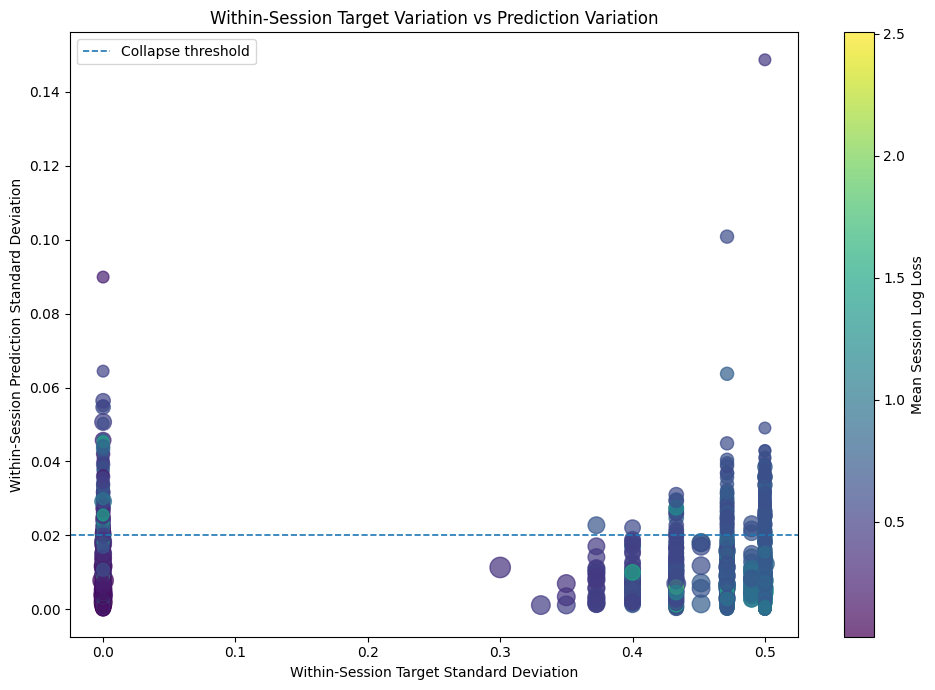

In [36]:
multi_session_plot = session_summary.loc[session_summary["multi_objective_session"]].copy()

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    multi_session_plot["label_std"],
    multi_session_plot["prediction_std"],
    s=35 + multi_session_plot["n_objectives"] * 18,
    c=multi_session_plot["mean_log_loss"],
    alpha=0.7
)

plt.axhline(0.02, linestyle="--", linewidth=1.2, label="Collapse threshold")
plt.colorbar(scatter, label="Mean Session Log Loss")

plt.title("Within-Session Target Variation vs Prediction Variation")
plt.xlabel("Within-Session Target Standard Deviation")
plt.ylabel("Within-Session Prediction Standard Deviation")
plt.legend()
plt.tight_layout()

plt.savefig(figures_dir / "session_objective_collapse_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

## 2.10 Objective-Level Performance

Each learning objective is analysed independently.

The objective table contains:

- number of responses and sessions;
- observed correctness rate;
- average model probability;
- calibration gap;
- mean Log Loss;
- AUROC where both labels are present;
- objective support group.

This determines whether rare objectives, difficult objectives or particular curriculum areas create systematic baseline failures.

In [37]:
objective_group = oof.groupby("objective_key")

objective_summary = (
    objective_group
    .agg(
        learning_objective=("learning_objective", "first"),
        support=("response_id", "size"),
        n_sessions=("session_id", "nunique"),
        positive_rate=("correct", "mean"),
        mean_probability=("probability", "mean"),
        mean_log_loss=("sample_log_loss", "mean"),
        mean_residual=("residual", "mean")
    )
)

objective_auc = objective_group.apply(
    lambda group: roc_auc_score(group["correct"], group["probability"])
    if group["correct"].nunique() == 2 else np.nan
)

objective_summary["roc_auc"] = objective_auc
objective_summary["calibration_gap"] = objective_summary["mean_probability"] - objective_summary["positive_rate"]

objective_summary = objective_summary.reset_index()

objective_summary["support_band"] = pd.qcut(
    objective_summary["support"].rank(method="first"),
    q=4,
    labels=["Rare", "Low", "Medium", "Frequent"]
)

objective_summary.to_csv(structure_dir / "objective_oof_summary.csv", index=False)

display(objective_summary.sort_values("mean_log_loss", ascending=False).head(15))

C:\Users\USER\AppData\Local\Temp\ipykernel_26388\4090286679.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  objective_auc = objective_group.apply(


,objective_key,learning_objective,support,n_sessions,positive_rate,mean_probability,mean_log_loss,mean_residual,roc_auc,calibration_gap,support_band
252,9ceb05603385212b,Finding prime factors,1,1,0.0000,0.8640,1.9950,-0.8640,NaN,0.8640,Rare
384,f974d6ffaeabf2c2,Working with Vector Geometry,2,2,0.0000,0.8522,1.9216,-0.8522,NaN,0.8522,Low
236,93d125cad0c95abc,Solving calculations in the correct order,1,1,0.0000,0.8505,1.9007,-0.8505,NaN,0.8505,Rare
358,e692716abc6ca2fa,Solving problems involving remainders,1,1,0.0000,0.8467,1.8754,-0.8467,NaN,0.8467,Rare
282,b58d34d6f6a4f028,Using BIDMAS to solve calculations,2,2,0.0000,0.8372,1.8278,-0.8372,NaN,0.8372,Rare
124,4d048f132d85c34a,Subtracting 4-digit numbers using the column method,1,1,0.0000,0.8289,1.7655,-0.8289,NaN,0.8289,Rare
240,94791ff7d8810d24,Reflecting shapes and patterns in a line of symmetry,1,1,0.0000,0.7749,1.4912,-0.7749,NaN,0.7749,Rare
363,e8f1c77609f72cd2,Making and describing linear sequences.,3,3,0.0000,0.7589,1.4318,-0.7589,NaN,0.7589,Low
7,02acd1d3d38545a2,Calculating with Fractions,1,1,0.0000,0.7384,1.3410,-0.7384,NaN,0.7384,Rare
140,560837cd21288822,Drawing and Interpreting Charts and Tables,1,1,0.0000,0.7266,1.2967,-0.7266,NaN,0.7266,Rare


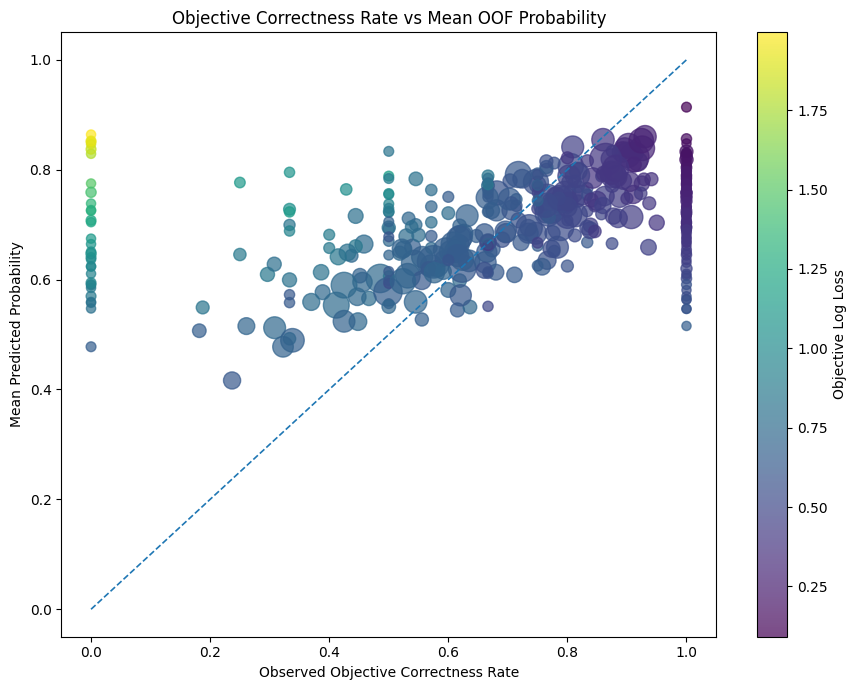

In [38]:
plt.figure(figsize=(9, 7))

bubble_size = 30 + np.sqrt(objective_summary["support"]) * 14

scatter = plt.scatter(
    objective_summary["positive_rate"],
    objective_summary["mean_probability"],
    s=bubble_size,
    c=objective_summary["mean_log_loss"],
    alpha=0.7
)

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2)
plt.colorbar(scatter, label="Objective Log Loss")

plt.title("Objective Correctness Rate vs Mean OOF Probability")
plt.xlabel("Observed Objective Correctness Rate")
plt.ylabel("Mean Predicted Probability")
plt.tight_layout()

plt.savefig(figures_dir / "objective_calibration_bubble_plot.png", dpi=200, bbox_inches="tight")
plt.show()

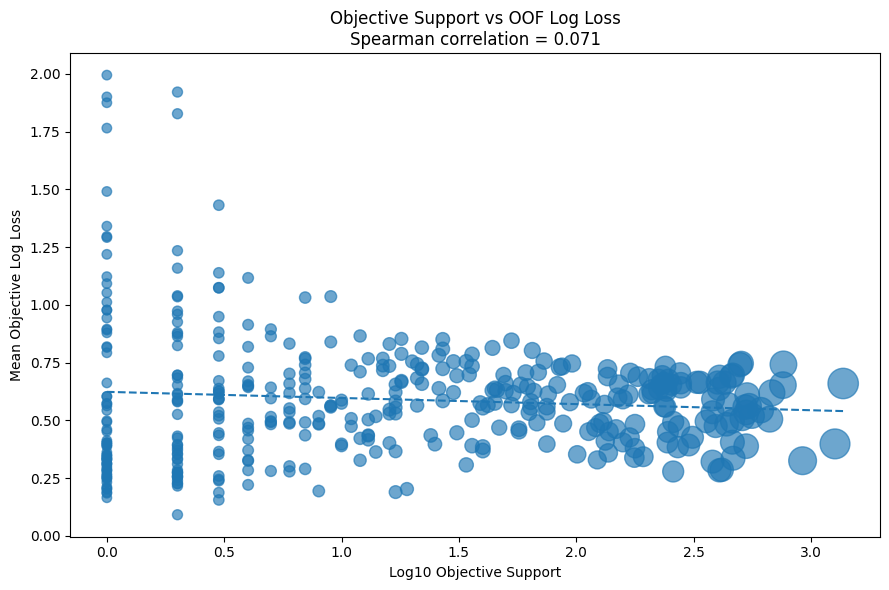

In [39]:
objective_summary["log_support"] = np.log10(objective_summary["support"].clip(lower=1))

support_loss_correlation = objective_summary["support"].corr(
    objective_summary["mean_log_loss"], method="spearman"
)

plt.figure(figsize=(9, 6))

plt.scatter(
    objective_summary["log_support"],
    objective_summary["mean_log_loss"],
    s=35 + np.sqrt(objective_summary["n_sessions"]) * 12,
    alpha=0.65
)

trend_coefficients = np.polyfit(
    objective_summary["log_support"],
    objective_summary["mean_log_loss"],
    deg=1
)

trend_x = np.linspace(objective_summary["log_support"].min(), objective_summary["log_support"].max(), 100)
trend_y = trend_coefficients[0] * trend_x + trend_coefficients[1]

plt.plot(trend_x, trend_y, linestyle="--", linewidth=1.5)

plt.title(f"Objective Support vs OOF Log Loss\nSpearman correlation = {support_loss_correlation:.3f}")
plt.xlabel("Log10 Objective Support")
plt.ylabel("Mean Objective Log Loss")
plt.tight_layout()

plt.savefig(figures_dir / "objective_support_vs_log_loss.png", dpi=200, bbox_inches="tight")
plt.show()

## 2.11 Binned Structural Trends and Fold × Slice Stability

Continuous structural features are converted into quantile bands for interpretable trend analysis.

The analysis checks whether model loss changes across:

- transcript length;
- turn count;
- objective support;
- student participation;
- number of objectives per session;
- mixed-label session status.

Fold × slice analysis determines whether a difficult data segment is consistently difficult or driven by only one fold.

In [40]:
def create_quantile_band(series, labels):
    ranked_values = pd.to_numeric(series, errors="coerce").rank(method="first")
    return pd.qcut(ranked_values, q=len(labels), labels=labels)


oof["transcript_length_band"] = create_quantile_band(
    oof["total_words"], ["Q1 Shortest", "Q2", "Q3", "Q4", "Q5 Longest"]
)

oof["turn_count_band"] = create_quantile_band(
    oof["total_turns"], ["Q1 Fewest", "Q2", "Q3", "Q4", "Q5 Most"]
)

oof["objective_frequency_band"] = create_quantile_band(
    oof["objective_frequency"], ["Rare", "Low", "Medium", "Frequent"]
)

if "student_word_ratio" in oof.columns:
    oof["student_word_ratio_band"] = create_quantile_band(
        oof["student_word_ratio"], ["Low", "Medium-low", "Medium-high", "High"]
    )

oof["objective_count_band"] = np.where(oof["objectives_per_session"].eq(1), "Single objective", "Multiple objectives")
oof["label_structure"] = np.where(oof["mixed_label_session"], "Mixed labels", "Single label")

oof.to_parquet(predictions_dir / "word_logistic_oof.parquet", index=False)

In [41]:
band_columns = [
    "transcript_length_band", "turn_count_band",
    "objective_frequency_band", "objective_count_band",
    "label_structure"
]

if "student_word_ratio_band" in oof.columns:
    band_columns.append("student_word_ratio_band")

trend_rows = []

for band_column in band_columns:
    grouped_trend = (
        oof.groupby([band_column, "correct"], observed=True)
        .agg(
            n_rows=("response_id", "size"),
            mean_probability=("probability", "mean"),
            mean_log_loss=("sample_log_loss", "mean"),
            mean_absolute_error=("absolute_error", "mean")
        )
        .reset_index()
    )

    grouped_trend["band_variable"] = band_column
    grouped_trend = grouped_trend.rename(columns={band_column: "band_value"})
    trend_rows.append(grouped_trend)

binned_relationships = pd.concat(trend_rows, ignore_index=True)
binned_relationships.to_csv(relationship_dir / "binned_relationships.csv", index=False)

display(binned_relationships.head(15))

,band_value,correct,n_rows,mean_probability,mean_log_loss,mean_absolute_error,band_variable
0,Q1 Shortest,0,2207,0.6256,1.0674,0.6256,transcript_length_band
1,Q1 Shortest,1,4808,0.7153,0.3535,0.2847,transcript_length_band
2,Q2,0,2184,0.6299,1.0766,0.6299,transcript_length_band
3,Q2,1,4830,0.7282,0.3353,0.2718,transcript_length_band
4,Q3,0,2086,0.6337,1.0949,0.6337,transcript_length_band
5,Q3,1,4928,0.7368,0.3230,0.2632,transcript_length_band
6,Q4,0,2011,0.6346,1.0984,0.6346,transcript_length_band
7,Q4,1,5003,0.7357,0.3243,0.2643,transcript_length_band
8,Q5 Longest,0,1947,0.6497,1.1433,0.6497,transcript_length_band
9,Q5 Longest,1,5068,0.7516,0.3004,0.2484,transcript_length_band


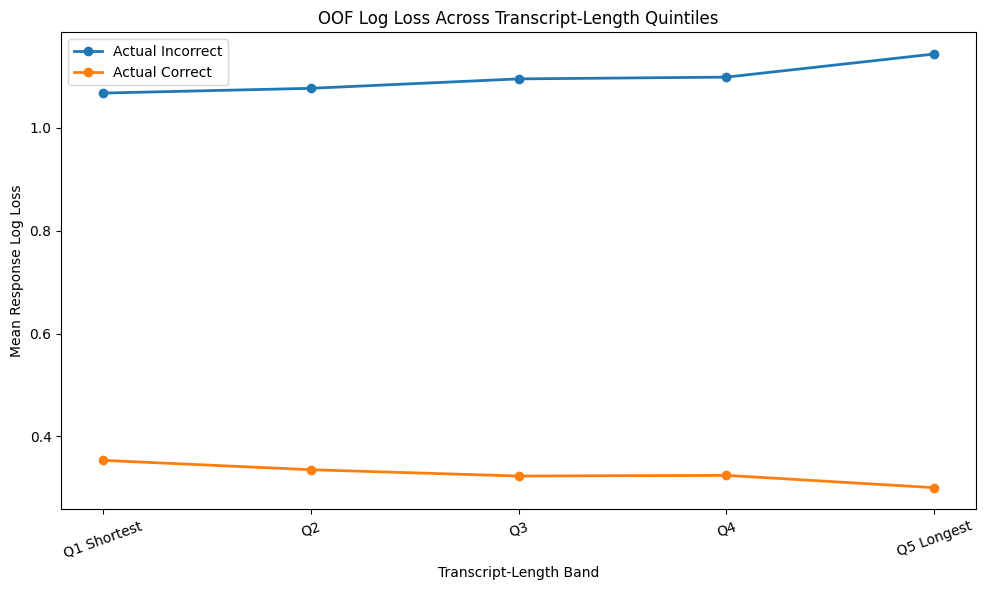

In [42]:
length_trend = binned_relationships.loc[
    binned_relationships["band_variable"].eq("transcript_length_band")
].copy()

plt.figure(figsize=(10, 6))

for target_value, group in length_trend.groupby("correct"):
    label = "Actual Correct" if target_value == 1 else "Actual Incorrect"

    plt.plot(
        group["band_value"].astype(str),
        group["mean_log_loss"],
        marker="o",
        linewidth=2,
        label=label
    )

plt.title("OOF Log Loss Across Transcript-Length Quintiles")
plt.xlabel("Transcript-Length Band")
plt.ylabel("Mean Response Log Loss")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

plt.savefig(figures_dir / "log_loss_by_transcript_length.png", dpi=200, bbox_inches="tight")
plt.show()

In [43]:
long_threshold = oof["total_words"].quantile(0.80)

slice_masks = {
    "All responses": pd.Series(True, index=oof.index),
    "Long transcript": oof["total_words"].ge(long_threshold),
    "Rare objective": oof["rare_objective"],
    "Multi-objective session": oof["objectives_per_session"].gt(1),
    "Mixed-label session": oof["mixed_label_session"]
}

if "student_word_ratio" in oof.columns:
    student_talk_threshold = oof["student_word_ratio"].quantile(0.80)
    slice_masks["High student talk"] = oof["student_word_ratio"].ge(student_talk_threshold)

if "tutor_question_ratio" in oof.columns:
    tutor_question_threshold = oof["tutor_question_ratio"].quantile(0.80)
    slice_masks["High tutor questioning"] = oof["tutor_question_ratio"].ge(tutor_question_threshold)

fold_slice_rows = []

for slice_name, slice_mask in slice_masks.items():
    for fold_id in range(5):
        subset = oof.loc[slice_mask & oof["fold_id"].eq(fold_id)]

        if len(subset) == 0:
            continue

        fold_slice_rows.append({
            "fold_id": fold_id,
            "slice": slice_name,
            "n_rows": len(subset),
            "positive_rate": subset["correct"].mean(),
            "mean_probability": subset["probability"].mean(),
            "log_loss": subset["sample_log_loss"].mean(),
            "brier_score": np.mean((subset["correct"] - subset["probability"]) ** 2)
        })

fold_slice_metrics = pd.DataFrame(fold_slice_rows)
fold_slice_metrics.to_csv(stability_dir / "fold_slice_metrics.csv", index=False)

display(fold_slice_metrics.head(15))

,fold_id,slice,n_rows,positive_rate,mean_probability,log_loss,brier_score
0,0,All responses,6980,0.7006,0.6999,0.5577,0.1881
1,1,All responses,7018,0.6989,0.7075,0.5614,0.1893
2,2,All responses,7019,0.7108,0.7038,0.5469,0.1834
3,3,All responses,7011,0.6996,0.7045,0.5547,0.1867
4,4,All responses,7044,0.7024,0.7051,0.5565,0.1872
5,0,Long transcript,1472,0.7072,0.7248,0.5447,0.1819
6,1,Long transcript,1388,0.7277,0.7212,0.5387,0.1793
7,2,Long transcript,1350,0.7496,0.7229,0.5180,0.1709
8,3,Long transcript,1437,0.7293,0.7269,0.5209,0.1726
9,4,Long transcript,1371,0.6988,0.7207,0.5502,0.1843


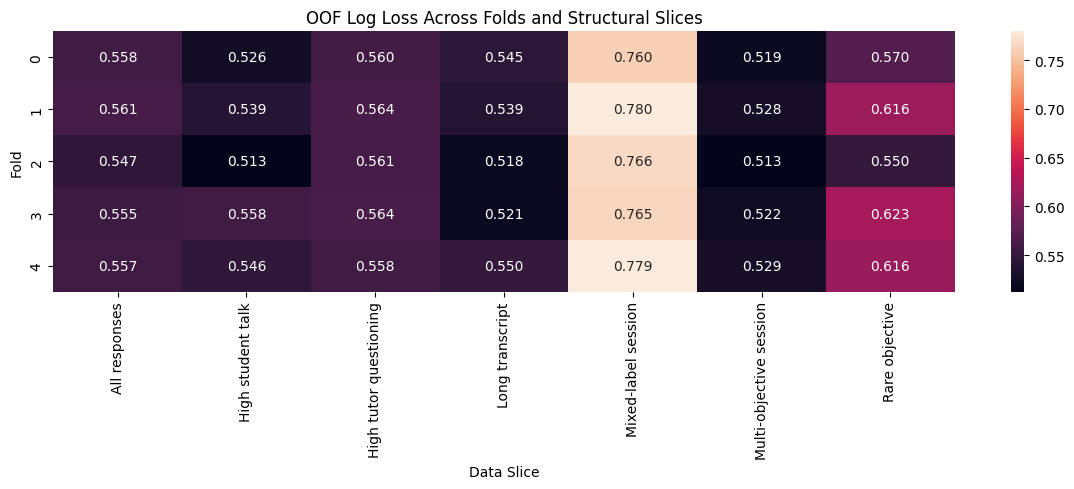

In [44]:
slice_heatmap = fold_slice_metrics.pivot(index="fold_id", columns="slice", values="log_loss")

plt.figure(figsize=(12, 5))
sns.heatmap(slice_heatmap, annot=True, fmt=".3f")

plt.title("OOF Log Loss Across Folds and Structural Slices")
plt.xlabel("Data Slice")
plt.ylabel("Fold")
plt.tight_layout()

plt.savefig(figures_dir / "fold_slice_log_loss_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 2.12 Evidence-Based Step 2 Summary

The final section converts the numerical results into a structured hypothesis register.

The status of each hypothesis is determined using project-level diagnostic thresholds. These thresholds support research prioritisation; they are not universal statistical laws.

The summary identifies:

- whether the original holdout was optimistic;
- whether same-session objective collapse is material;
- whether long transcripts are associated with higher loss;
- whether rare objectives are more difficult;
- which analyses should receive priority in Step 3 and Step 4.

In [45]:
length_loss_row = signal_alignment.loc[signal_alignment["feature"].eq("total_words"), "sample_log_loss"]
length_loss_correlation = float(length_loss_row.iloc[0]) if len(length_loss_row) else np.nan


def validation_gap_status(gap):
    if gap > 0.015:
        return "Supported"

    if gap > 0.005:
        return "Partially supported"

    return "Not supported"


def relationship_status(value, expected_direction="positive"):
    if pd.isna(value):
        return "Inconclusive"

    if expected_direction == "positive":
        if value >= 0.05:
            return "Supported"

        if value >= 0.02:
            return "Partially supported"

    if expected_direction == "negative":
        if value <= -0.05:
            return "Supported"

        if value <= -0.02:
            return "Partially supported"

    return "Not supported"


collapse_status = "Supported" if collapse_loss_share > collapse_response_share * 1.20 else "Partially supported"

hypothesis_results = pd.DataFrame([
    {
        "hypothesis_id": "H01",
        "hypothesis": "The original holdout is optimistic.",
        "evidence": f"OOF minus holdout Log Loss = {holdout_gap:.6f}",
        "status": validation_gap_status(holdout_gap)
    },
    {
        "hypothesis_id": "H02",
        "hypothesis": "Same-session objective prediction collapse is material.",
        "evidence": f"Collapse response share = {collapse_response_share:.4f}; loss share = {collapse_loss_share:.4f}",
        "status": collapse_status
    },
    {
        "hypothesis_id": "H05",
        "hypothesis": "Long transcripts are associated with higher model loss.",
        "evidence": f"Spearman total_words vs sample loss = {length_loss_correlation:.4f}",
        "status": relationship_status(length_loss_correlation, "positive")
    },
    {
        "hypothesis_id": "H07",
        "hypothesis": "Low-support objectives have higher model loss.",
        "evidence": f"Spearman objective support vs Log Loss = {support_loss_correlation:.4f}",
        "status": relationship_status(support_loss_correlation, "negative")
    }
])

hypothesis_results.to_csv(report_dir / "hypothesis_results.csv", index=False)

display(hypothesis_results)

,hypothesis_id,hypothesis,evidence,status
0,H01,The original holdout is optimistic.,OOF minus holdout Log Loss = 0.009985,Partially supported
1,H02,Same-session objective prediction collapse is material.,Collapse response share = 0.2159; loss share = 0.3026,Supported
2,H05,Long transcripts are associated with higher model loss.,Spearman total_words vs sample loss = -0.0678,Not supported
3,H07,Low-support objectives have higher model loss.,Spearman objective support vs Log Loss = 0.0706,Not supported


In [46]:
next_priorities = pd.DataFrame([
    {
        "priority": 1,
        "next_analysis": "Response-level loss-tail analysis",
        "reason": "Identify the rows and sessions contributing the largest share of OOF Log Loss."
    },
    {
        "priority": 2,
        "next_analysis": "SHAP analysis of confident errors",
        "reason": "Determine which lexical features drive high-confidence false predictions."
    },
    {
        "priority": 3,
        "next_analysis": "Mixed-label session paired analysis",
        "reason": "Test whether the model uses objective-specific evidence inside shared transcripts."
    },
    {
        "priority": 4,
        "next_analysis": "Long-transcript and rare-objective review",
        "reason": "Investigate structural slices associated with weak generalisation."
    },
    {
        "priority": 5,
        "next_analysis": "Calibration analysis",
        "reason": "Separate ranking limitations from probability overconfidence."
    }
])

next_priorities.to_csv(report_dir / "next_analysis_priorities.csv", index=False)

step2_report = f"""# Step 2 — Five-Fold OOF Research Report

## Validation Performance

- Original holdout Log Loss: {holdout_log_loss:.6f}
- Pooled OOF Log Loss: {pooled_metrics["log_loss"]:.6f}
- Mean fold Log Loss: {fold_metrics["log_loss"].mean():.6f}
- Worst fold Log Loss: {fold_metrics["log_loss"].max():.6f}
- Fold standard deviation: {fold_metrics["log_loss"].std():.6f}
- OOF minus holdout gap: {holdout_gap:.6f}
- Session-bootstrap 95% interval: [{bootstrap_lower:.6f}, {bootstrap_upper:.6f}]

## OOF Ranking and Probability Quality

- OOF AUROC: {pooled_metrics["roc_auc"]:.6f}
- OOF Accuracy: {pooled_metrics["accuracy"]:.6f}
- OOF Brier Score: {pooled_metrics["brier_score"]:.6f}
- Observed positive rate: {pooled_metrics["positive_rate"]:.6f}
- Mean model probability: {pooled_metrics["mean_probability"]:.6f}

## Session–Objective Structure

- Multi-objective sessions: {int(multi_sessions):,}
- Mixed-label sessions: {int(mixed_sessions):,}
- Collapse candidates: {int(collapse_sessions):,}
- Collapse rate among mixed-label sessions: {collapse_rate:.4f}
- Collapse response share: {collapse_response_share:.4f}
- Collapse total loss share: {collapse_loss_share:.4f}

## Structural Relationships

- Transcript length vs sample Log Loss: {length_loss_correlation:.4f}
- Objective support vs objective Log Loss: {support_loss_correlation:.4f}

## Research Decision

The five-fold OOF predictions are now the primary reference for all later baseline analysis.

Step 3 should decompose the OOF Log Loss and isolate catastrophic false-positive and false-negative cases.

Step 4 should use fold-specific SHAP explanations to determine which lexical signals drive those errors.
"""

with open(report_dir / "step2_findings.md", "w", encoding="utf-8") as file:
    file.write(step2_report)

step2_outputs = pd.DataFrame({
    "Output": [
        "Frozen fold manifest", "Fold metrics", "Complete OOF predictions",
        "Response relationships", "Signal alignment", "Session summary",
        "Collapse candidates", "Objective summary", "Fold-slice metrics",
        "Hypothesis register", "Step 2 report"
    ],
    "Location": [
        "00_fold_design/fold_manifest.parquet",
        "03_fold_stability/fold_metrics.csv",
        "02_oof_predictions/word_logistic_oof.parquet",
        "04_relationship_analysis/response_relationships.csv",
        "04_relationship_analysis/signal_alignment.csv",
        "05_session_objective_structure/session_oof_summary.csv",
        "05_session_objective_structure/collapse_candidates.parquet",
        "05_session_objective_structure/objective_oof_summary.csv",
        "03_fold_stability/fold_slice_metrics.csv",
        "07_report/hypothesis_results.csv",
        "07_report/step2_findings.md"
    ]
})

print("Step 2 completed successfully.")
display(next_priorities)
display(step2_outputs)

Step 2 completed successfully.


,priority,next_analysis,reason
0,1,Response-level loss-tail analysis,Identify the rows and sessions contributing the largest share of OOF Log Loss.
1,2,SHAP analysis of confident errors,Determine which lexical features drive high-confidence false predictions.
2,3,Mixed-label session paired analysis,Test whether the model uses objective-specific evidence inside shared transcripts.
3,4,Long-transcript and rare-objective review,Investigate structural slices associated with weak generalisation.
4,5,Calibration analysis,Separate ranking limitations from probability overconfidence.


,Output,Location
0,Frozen fold manifest,00_fold_design/fold_manifest.parquet
1,Fold metrics,03_fold_stability/fold_metrics.csv
2,Complete OOF predictions,02_oof_predictions/word_logistic_oof.parquet
3,Response relationships,04_relationship_analysis/response_relationships.csv
4,Signal alignment,04_relationship_analysis/signal_alignment.csv
5,Session summary,05_session_objective_structure/session_oof_summary.csv
6,Collapse candidates,05_session_objective_structure/collapse_candidates.parquet
7,Objective summary,05_session_objective_structure/objective_oof_summary.csv
8,Fold-slice metrics,03_fold_stability/fold_slice_metrics.csv
9,Hypothesis register,07_report/hypothesis_results.csv


# Step 2 — Five-Fold OOF Analysis Findings

## Executive Summary

The five-fold grouped OOF analysis confirms that the `word_logistic` baseline is reasonably stable and retains moderate ranking ability. However, it also reveals a major structural limitation: the model frequently fails to distinguish different learning objectives that share the same session transcript.

The strongest finding is the presence of severe same-session objective collapse. In most mixed-label sessions, the model assigns nearly identical probabilities to objectives with different true outcomes. This indicates that the full-transcript TF-IDF representation behaves more like a session-level correctness model than a genuinely objective-specific response model.

---

## 1. Validation Reliability

The original single-holdout result was:

- **Log Loss:** 0.545475

The leakage-safe five-fold OOF results were:

- **Pooled OOF Log Loss:** 0.555460
- **Mean fold Log Loss:** 0.555462
- **Worst fold Log Loss:** 0.561402
- **Fold Log Loss standard deviation:** 0.005350
- **Best–worst fold gap:** 0.014458
- **OOF minus holdout gap:** 0.009985
- **Session-bootstrap 95% interval:** [0.550385, 0.560448]

The original holdout score is lower than the OOF confidence interval, providing strong evidence that the original validation split was relatively favourable. Under the project hypothesis rules, this is classified as **partially supported** rather than treated as a formal paired significance result.

The five-fold OOF result should now be used as the primary reference for all later baseline analysis.

---

## 2. Ranking and Probability Quality

The pooled OOF metrics were:

- **AUROC:** 0.700693
- **Accuracy:** 0.721801
- **Brier Score:** 0.186968
- **Observed positive rate:** 0.702469
- **Mean predicted probability:** 0.704174

The OOF AUROC remains close to the original holdout AUROC, indicating that the model's ranking ability generalises reasonably well.

The larger deterioration in Log Loss than in AUROC suggests that probability quality is less robust than ranking quality. The model often preserves the broad ordering of responses while assigning probabilities that are too confident or insufficiently adapted to particular objectives and session structures.

Accuracy should be interpreted cautiously because approximately 70.25% of the responses are positive. The baseline's 72.18% accuracy is therefore only moderately better than an always-positive classifier.

---

## 3. Structural Balance Across Folds

The frozen folds are not identical, but no structural property is approximately two standard deviations or more from the fold average.

Notable fold differences include:

- Fold 1 contains relatively longer transcripts and more turns and produces the worst Log Loss and AUROC.
- Fold 2 has a higher positive rate, fewer unique objectives and shorter sessions and produces the best Log Loss.
- Fold 4 contains relatively more rows and a higher mixed-label share.
- Fold 3 contains relatively more unique objectives.

These differences indicate moderate composition sensitivity, but no single structural variable fully explains fold performance. Generalisation difficulty appears to depend on the interaction of label prevalence, session complexity, objective composition and transcript structure.

---

## 4. OOF Probability Separation

The OOF ECDF shows meaningful but incomplete separation between the two target classes.

Correct responses generally receive higher probabilities than incorrect responses. However, the distributions overlap substantially.

At the 0.50 threshold, approximately:

- 81% of incorrect responses remain above 0.50;
- 95% of correct responses remain above 0.50.

This reflects a strong positive-class tendency, which is partly expected from the 70% positive prevalence. The model performs well on many correct responses but also assigns high correctness probabilities to many incorrect responses.

These confident false positives are likely to be important contributors to Log Loss and should receive priority in the response-level loss audit.

---

## 5. Structural Slice Performance

The average Log Loss values across major structural slices were approximately:

| Structural Slice | Mean Log Loss |
|---|---:|
| Multi-objective session | 0.5223 |
| Long transcript | 0.5345 |
| High student talk | 0.5364 |
| All responses | 0.5555 |
| High tutor questioning | 0.5616 |
| Rare objective | 0.5949 |
| Mixed-label session | 0.7700 |

Multi-objective sessions are not inherently difficult. Their overall Log Loss is lower than the global average.

The major problem occurs when the objectives inside the same session have different labels. Mixed-label sessions produce extremely high and consistent loss across all five folds.

This distinction is critical:

> The presence of multiple objectives is not the primary problem. The primary problem is objective-specific discrimination when outcomes differ within the same transcript.

---

## 6. Same-Session Objective Collapse

The session-level analysis found:

- **Multi-objective sessions:** 8,364
- **Mixed-label sessions:** 3,207
- **Collapse candidates:** 2,914
- **Collapse rate among mixed-label sessions:** 90.86%
- **Collapse response share:** 21.59%
- **Collapse total Log Loss share:** 30.26%

A collapse candidate is a mixed-label session with within-session prediction standard deviation below 0.02.

Approximately 91% of mixed-label sessions satisfy this condition. This means that when one objective is correct and another is incorrect within the same session, the model usually assigns nearly identical probabilities to both.

Collapse cases represent only 21.59% of responses but contribute 30.26% of total OOF Log Loss. Their loss contribution is therefore approximately 1.4 times larger than their response share.

This is the strongest diagnosed baseline failure.

The result strongly suggests that full-transcript lexical features dominate the relatively small objective-specific component of the input. The model captures an overall session impression but fails to isolate evidence related to each learning objective.

---

## 7. Transcript-Length Relationship

The overall Spearman relationship between transcript length and sample Log Loss was:

- **Spearman correlation:** -0.0678

Therefore, the original hypothesis that longer transcripts universally increase loss is not supported.

However, the target-stratified plot reveals an important asymmetric effect.

For actual correct responses:

- Log Loss decreases as transcript length increases.

For actual incorrect responses:

- Log Loss increases as transcript length increases.

This suggests that longer transcripts increase the model's tendency to predict correctness with greater confidence.

That tendency is beneficial when the response is actually correct, but harmful when the response is incorrect.

A more accurate reformulation is:

> Longer transcripts do not uniformly reduce performance; they appear to amplify positive-class confidence and therefore increase false-positive risk for incorrect responses.

---

## 8. Rare Objectives and Objective Support

The rare-objective response slice has a mean Log Loss of approximately 0.5949, compared with 0.5555 overall.

However, the objective-level Spearman relationship between support and Log Loss is only:

- **Spearman correlation:** 0.0706

This does not support a simple monotonic claim that lower support always produces higher loss.

Support-band analysis still shows that rare objectives have higher variance, larger calibration gaps and more extreme failures than frequent objectives. The correct interpretation is therefore:

> Rare objectives are a high-uncertainty risk group, but support count alone does not explain objective difficulty.

Objective wording, curriculum difficulty, evidence quality and objective-specific calibration must also be considered.

---

## 9. Objective-Level Calibration

At the global level, calibration appears close:

- Observed positive rate: 0.702469
- Mean predicted probability: 0.704174

However, objective-level calibration is substantially weaker.

Objectives with observed correctness rates near zero often receive mean probabilities between approximately 0.55 and 0.85. Conversely, objectives with observed correctness rates near one are often predicted well below one.

This indicates regression toward the global positive rate. The model fails to represent the full range of objective difficulty and tends to produce compressed probabilities.

Therefore:

> Good global calibration does not imply good objective-level calibration.

Future calibration work should examine objective-support bands, objective priors and domain-specific probability adjustment.

---

## 10. Signal Alignment

The signal-alignment analysis compares each feature's relationship with the actual target against its relationship with model probability.

Several student-behaviour variables appear directionally aligned:

- longer student turns;
- more student words per turn;
- lower short-turn ratio.

However, their relationships with model probability are often stronger than their relationships with the actual target. This suggests that the model may over-rely on surface verbosity as a proxy for understanding.

The most important mismatch is `mixed_label_session`.

Mixed-label structure is strongly associated with poorer true outcomes, but the model probability does not decrease accordingly. This confirms that the model does not recognise the difficulty created by conflicting objectives within the same session.

The number of responses and objectives per session also has a much stronger relationship with model probability than with the actual target, suggesting that the model learns session-level prevalence patterns more strongly than objective-specific evidence.

---

## 11. Hypothesis Decisions

| Hypothesis | Decision | Evidence |
|---|---|---|
| H01: The original holdout is optimistic | Partially supported | OOF Log Loss is 0.009985 worse |
| H02: Same-session objective collapse is material | Supported | 90.86% collapse rate and disproportionate loss contribution |
| H05: Long transcripts generally increase loss | Not supported | Overall relationship is weakly negative |
| H07: Low-support objectives always have higher loss | Not supported | Support–loss relationship is weak and non-monotonic |

---

## 12. Baseline Strengths

The baseline demonstrates:

- exact reproducibility;
- reasonably stable five-fold performance;
- approximately 0.70 OOF AUROC;
- moderate class-ranking ability;
- close global mean calibration;
- useful student-response and dialogue-structure signals.

---

## 13. Baseline Weaknesses

The baseline exhibits:

- a strong positive-class probability tendency;
- many potentially costly false-positive predictions;
- weak objective-level calibration;
- severe prediction collapse inside mixed-label sessions;
- insufficient objective-specific evidence extraction;
- possible over-reliance on transcript length and student verbosity;
- unstable performance for rare objectives.

---

## Final Research Conclusion

The current `word_logistic` baseline is a reasonable session-level correctness model, but it is not yet a strong session–learning-objective model.

Its main limitation is not a complete absence of predictive signal. The main limitation is that the signal is insufficiently conditioned on the target learning objective.

The highest-value V2 direction is therefore objective-specific evidence modelling through:

- objective-conditioned dialogue retrieval;
- relevant student-turn extraction;
- pre-feedback and student-only text views;
- objective–transcript similarity;
- fold-safe objective difficulty priors;
- calibrated objective-aware probability estimation.

## Next Analysis Priorities

1. Decompose response-level OOF Log Loss and identify catastrophic errors.
2. Analyse confident false positives and false negatives.
3. Perform paired analysis within mixed-label sessions.
4. Use fold-specific SHAP explanations to identify lexical drivers.
5. Separate ranking quality from calibration and confidence errors.

# Step 2 — Key Baseline Insights

## Performance Snapshot

| Area | Key Finding | Meaning |
|---|---|---|
| OOF Performance | Log Loss: **0.5555**, AUROC: **0.7007** | The baseline is reasonably stable, but the original holdout was slightly optimistic. |
| Fold Stability | Fold SD: **0.0054** | Performance is consistent across the five grouped folds. |
| Mixed-Label Sessions | Log Loss: **~0.770** | This is the most difficult and consistent failure slice. |
| Objective Collapse | **90.86%** of mixed-label sessions | The model often gives nearly identical predictions to different objectives in the same session. |
| Rare Objectives | Log Loss: **~0.595** | Rare objectives are riskier, although support alone does not explain difficulty. |
| Global Calibration | Actual rate: **0.7025**, mean probability: **0.7042** | Overall calibration is close, but objective-level calibration remains weak. |

## Main Insights

- The baseline has useful predictive signal and maintains approximately **0.70 AUROC** under leakage-safe OOF validation.
- The main weakness is not general instability; it is **insufficient objective-specific understanding**.
- Multi-objective sessions are not inherently difficult, but sessions containing different labels across objectives create severe errors.
- Collapse cases represent **21.59% of responses** but contribute **30.26% of total Log Loss**.
- Longer transcripts appear to increase positive confidence: this helps correct cases but increases false-positive loss for incorrect cases.
- The next priority should be confident-error analysis, objective-conditioned evidence retrieval and fold-specific SHAP investigation.

> **Core conclusion:** The current model works as a reasonable session-level correctness model, but it is not yet a strong session–learning-objective model.

# Step 2 — Baseline-এর প্রধান Insights

## Performance Snapshot

| বিষয় | প্রধান ফলাফল | এর অর্থ |
|---|---|---|
| OOF Performance | Log Loss: **0.5555**, AUROC: **0.7007** | Baseline মোটামুটি stable, তবে original holdout কিছুটা optimistic ছিল। |
| Fold Stability | Fold SD: **0.0054** | পাঁচটি grouped fold-এ performance বেশ consistent। |
| Mixed-Label Sessions | Log Loss: **প্রায় 0.770** | এটি baseline-এর সবচেয়ে কঠিন ও ধারাবাহিক failure slice। |
| Objective Collapse | Mixed-label session-এর **90.86%** | একই session-এর ভিন্ন objective-এ model প্রায় একই prediction দিচ্ছে। |
| Rare Objectives | Log Loss: **প্রায় 0.595** | Rare objectives বেশি risky, তবে support count একা difficulty ব্যাখ্যা করে না। |
| Global Calibration | Actual rate: **0.7025**, mean probability: **0.7042** | Overall calibration কাছাকাছি, কিন্তু objective-level calibration দুর্বল। |

## প্রধান Insights

- Leakage-safe OOF validation-এও baseline প্রায় **0.70 AUROC** ধরে রেখেছে।
- Model-এর মূল সমস্যা overall instability নয়; সমস্যা হলো **objective-specific evidence ঠিকভাবে বুঝতে না পারা**।
- Multi-objective session নিজে কঠিন নয়, কিন্তু একই session-এর objectives-এর labels ভিন্ন হলে error অনেক বেড়ে যায়।
- Collapse cases মোট response-এর **21.59%**, কিন্তু total Log Loss-এর **30.26%** তৈরি করছে।
- Long transcript model-এর positive confidence বাড়ায়; correct case-এ এটি সাহায্য করে, কিন্তু incorrect case-এ false-positive loss বাড়ায়।
- পরবর্তী priority হবে confident errors, objective-conditioned evidence এবং fold-specific SHAP analysis।

> **মূল সিদ্ধান্ত:** বর্তমান model একটি reasonable session-level correctness model, কিন্তু এখনো শক্তিশালী session–learning-objective model নয়।

# Step 3 — Objective-Specificity Mechanism Audit and Recoverable Loss Analysis

## Master Research Question

> **Why does the baseline fail to distinguish learning objectives within the same session, how much OOF loss is caused by this failure, and can objective-conditioned evidence modelling realistically recover a meaningful part of that loss?**

## Research Framework

This stage combines five evidence layers:

1. **Loss anatomy:** where the OOF loss is concentrated.
2. **Session-levelness:** whether predictions are mainly controlled by the shared session transcript.
3. **Within-session ranking:** whether correct objectives receive higher probabilities than incorrect objectives from the same session.
4. **Evidence availability and utilisation:** whether objective-relevant student evidence exists and whether the model responds to it.
5. **Recoverable-loss simulation:** how much Log Loss may decrease if objective discrimination improves.

No new model is trained in this step. All analysis uses the frozen Step 2 OOF predictions and fold-specific baseline artifacts.

In [2]:
# Core response-level loss variables
ledger["true_class_probability"] = np.where(
    ledger["correct"].eq(1),
    ledger["probability"],
    1 - ledger["probability"]
)

ledger["sample_log_loss"] = -np.log(
    ledger["true_class_probability"].clip(1e-6, 1 - 1e-6)
)

ledger["residual"] = ledger["correct"] - ledger["probability"]
ledger["absolute_error"] = ledger["residual"].abs()
ledger["prediction_confidence"] = (ledger["probability"] - 0.5).abs()
ledger["is_misclassified"] = ledger["correct"].ne(ledger["probability"].ge(0.5))


# Error direction
conditions = [
    ledger["correct"].eq(1) & ledger["probability"].ge(0.5),
    ledger["correct"].eq(0) & ledger["probability"].lt(0.5),
    ledger["correct"].eq(0) & ledger["probability"].ge(0.5),
    ledger["correct"].eq(1) & ledger["probability"].lt(0.5)
]

labels = [
    "Correct positive", "Correct negative",
    "False positive", "False negative"
]

ledger["error_direction"] = np.select(
    conditions,
    labels,
    default="Unknown"
)


# Probability-confidence bands
ledger["confidence_band"] = pd.cut(
    ledger["probability"],
    bins=[0, 0.20, 0.40, 0.60, 0.80, 1.00],
    labels=["Very low", "Low", "Boundary", "High", "Very high"],
    include_lowest=True
)


# Individual-loss severity bands
ledger["loss_band"] = pd.cut(
    ledger["sample_log_loss"],
    bins=[0, 0.25, 0.75, 1.50, 3.00, np.inf],
    labels=["Low", "Moderate", "High", "Severe", "Catastrophic"],
    include_lowest=True
)

ledger["confident_false_positive"] = (
    ledger["correct"].eq(0) &
    ledger["probability"].ge(0.80)
)

ledger["confident_false_negative"] = (
    ledger["correct"].eq(1) &
    ledger["probability"].le(0.20)
)


# Leakage-safe fold prior
fold_prior = {}

for fold_id in sorted(ledger["fold_id"].unique()):
    training_prior = ledger.loc[
        ledger["fold_id"].ne(fold_id),
        "correct"
    ].mean()

    fold_prior[int(fold_id)] = float(training_prior)

ledger["fold_prior_probability"] = ledger["fold_id"].map(fold_prior)

ledger["prior_log_loss"] = -np.where(
    ledger["correct"].eq(1),
    np.log(ledger["fold_prior_probability"]),
    np.log(1 - ledger["fold_prior_probability"])
)

ledger["model_regret"] = (
    ledger["sample_log_loss"] -
    ledger["prior_log_loss"]
)


# Save master ledger
ledger.to_parquet(
    step3_dirs["00_loss_ledger"] / "response_loss_ledger.parquet",
    index=False
)

ledger_summary = pd.DataFrame({
    "Metric": [
        "OOF Log Loss", "Fold-prior Log Loss",
        "Model improvement over prior",
        "Confident false-positive rows",
        "Confident false-negative rows",
        "Catastrophic-loss rows"
    ],
    "Value": [
        ledger["sample_log_loss"].mean(),
        ledger["prior_log_loss"].mean(),
        ledger["prior_log_loss"].mean() - ledger["sample_log_loss"].mean(),
        ledger["confident_false_positive"].sum(),
        ledger["confident_false_negative"].sum(),
        ledger["loss_band"].eq("Catastrophic").sum()
    ]
})

display(ledger_summary)

,Metric,Value
0,OOF Log Loss,0.5555
1,Fold-prior Log Loss,0.6088
2,Model improvement over prior,0.0533
3,Confident false-positive rows,"1,384.0000"
4,Confident false-negative rows,2.0000
5,Catastrophic-loss rows,6.0000


## 3.1 Session-Levelness and Within-Session Objective Ranking

The central structural test compares variation at two levels:

- **between sessions:** predictions change because the transcript and session change;
- **within sessions:** predictions change because the learning objective changes while the transcript remains fixed.

A strong session–objective model should preserve meaningful within-session variation when the objectives have different labels.

Mixed-label sessions also provide a natural matched comparison because the student, tutor, transcript and session structure remain fixed while the target learning objective changes.

In [3]:
def variance_decomposition(values, groups):
    values = pd.Series(values).astype(float)
    group_means = values.groupby(groups).transform("mean")
    grand_mean = values.mean()

    total_variance = np.mean((values - grand_mean) ** 2)
    within_variance = np.mean((values - group_means) ** 2)
    between_variance = np.mean((group_means - grand_mean) ** 2)

    return {
        "total_variance": total_variance,
        "between_variance": between_variance,
        "within_variance": within_variance,
        "between_share": between_variance / total_variance,
        "within_share": within_variance / total_variance
    }


# Variance decomposition
target_variance = variance_decomposition(
    ledger["correct"],
    ledger["session_id"]
)

prediction_variance = variance_decomposition(
    ledger["probability"],
    ledger["session_id"]
)

variance_summary = pd.DataFrame([
    {"Variable": "Actual target", **target_variance},
    {"Variable": "Model probability", **prediction_variance}
])

objective_responsiveness_ratio = np.sqrt(
    prediction_variance["within_variance"] /
    target_variance["within_variance"]
)

variance_summary["objective_responsiveness_ratio"] = [
    np.nan,
    objective_responsiveness_ratio
]


# Session-level summary
session_group = ledger.groupby("session_id")

session_summary = (
    session_group
    .agg(
        n_responses=("response_id", "size"),
        n_objectives=("objective_key", "nunique"),
        positive_rate=("correct", "mean"),
        mean_probability=("probability", "mean"),
        prediction_min=("probability", "min"),
        prediction_max=("probability", "max"),
        mean_loss=("sample_log_loss", "mean"),
        total_loss=("sample_log_loss", "sum"),
        mean_regret=("model_regret", "mean")
    )
)

session_summary["prediction_std"] = session_group["probability"].std(ddof=0)
session_summary["target_std"] = session_group["correct"].std(ddof=0)
session_summary["prediction_range"] = (
    session_summary["prediction_max"] -
    session_summary["prediction_min"]
)

session_summary = session_summary.reset_index()
session_summary["mixed_label_session"] = session_summary["positive_rate"].between(
    0, 1, inclusive="neither"
)

session_summary["collapse_candidate"] = (
    session_summary["mixed_label_session"] &
    session_summary["prediction_std"].lt(0.02)
)


# Session-mean equivalence test
ledger["session_mean_probability"] = ledger.groupby(
    "session_id"
)["probability"].transform("mean")

original_log_loss = ledger["sample_log_loss"].mean()

session_mean_log_loss = log_loss(
    ledger["correct"],
    ledger["session_mean_probability"].clip(1e-6, 1 - 1e-6)
)

objective_added_value = session_mean_log_loss - original_log_loss


# Positive-negative objective pairs inside mixed-label sessions
pair_rows = []
mixed_sessions = ledger.loc[ledger["mixed_label_session"]]

for session_id, group in mixed_sessions.groupby("session_id"):
    positive_rows = group.loc[
        group["correct"].eq(1),
        ["response_id", "objective_key", "probability"]
    ]

    negative_rows = group.loc[
        group["correct"].eq(0),
        ["response_id", "objective_key", "probability"]
    ]

    for positive in positive_rows.itertuples():
        for negative in negative_rows.itertuples():
            pair_rows.append({
                "session_id": session_id,
                "positive_response_id": positive.response_id,
                "negative_response_id": negative.response_id,
                "positive_objective": positive.objective_key,
                "negative_objective": negative.objective_key,
                "positive_probability": positive.probability,
                "negative_probability": negative.probability,
                "pairwise_margin": positive.probability - negative.probability
            })

mixed_pairs = pd.DataFrame(pair_rows)

mixed_pairs["pairwise_correct"] = np.where(
    mixed_pairs["pairwise_margin"].gt(0), 1,
    np.where(mixed_pairs["pairwise_margin"].lt(0), 0, 0.5)
)

pairwise_accuracy = mixed_pairs["pairwise_correct"].mean()
reversed_pair_rate = mixed_pairs["pairwise_margin"].lt(0).mean()


# Margin threshold sensitivity
margin_rows = []

for threshold in [0.01, 0.02, 0.05]:
    margin_rows.append({
        "threshold": threshold,
        "collapse_pair_share": mixed_pairs["pairwise_margin"].abs().le(threshold).mean(),
        "useful_positive_margin_share": mixed_pairs["pairwise_margin"].gt(threshold).mean(),
        "reversed_margin_share": mixed_pairs["pairwise_margin"].lt(-threshold).mean()
    })

margin_sensitivity = pd.DataFrame(margin_rows)


# Save outputs
variance_summary.to_csv(
    step3_dirs["01_session_levelness"] / "variance_decomposition.csv",
    index=False
)

session_summary.to_csv(
    step3_dirs["01_session_levelness"] / "session_summary.csv",
    index=False
)

mixed_pairs.to_parquet(
    step3_dirs["02_within_session_ranking"] / "mixed_session_pairs.parquet",
    index=False
)

margin_sensitivity.to_csv(
    step3_dirs["02_within_session_ranking"] / "margin_sensitivity.csv",
    index=False
)

session_equivalence = pd.DataFrame({
    "Metric": [
        "Original OOF Log Loss",
        "Session-mean Log Loss",
        "Objective added value",
        "Within-session pairwise accuracy",
        "Reversed pair rate",
        "Objective responsiveness ratio"
    ],
    "Value": [
        original_log_loss,
        session_mean_log_loss,
        objective_added_value,
        pairwise_accuracy,
        reversed_pair_rate,
        objective_responsiveness_ratio
    ]
})

session_equivalence.to_csv(
    step3_dirs["01_session_levelness"] / "session_mean_comparison.csv",
    index=False
)

display(variance_summary)
display(session_equivalence)
display(margin_sensitivity)

,Variable,total_variance,between_variance,within_variance,between_share,within_share,objective_responsiveness_ratio
0,Actual target,0.2090,0.1547,0.0543,0.7400,0.2600,NaN
1,Model probability,0.0195,0.0194,0.0001,0.9967,0.0033,0.0343


,Metric,Value
0,Original OOF Log Loss,0.5555
1,Session-mean Log Loss,0.5576
2,Objective added value,0.0022
3,Within-session pairwise accuracy,0.6793
4,Reversed pair rate,0.3207
5,Objective responsiveness ratio,0.0343


,threshold,collapse_pair_share,useful_positive_margin_share,reversed_margin_share
0,0.0100,0.5138,0.3729,0.1133
1,0.0200,0.7323,0.2174,0.0503
2,0.0500,0.9607,0.0355,0.0038


## 3.2 Input-Contribution and Evidence-Availability Audit

The fold-specific saved models are used to test how predictions change when different input components are retained.

Five diagnostic views are evaluated:

- full objective and transcript;
- transcript only;
- objective only;
- objective and student text;
- objective and tutor text.

These are sensitivity tests rather than newly trained alternative models.

Objective-to-student, objective-to-tutor and objective-to-transcript similarities are also calculated using the vectorizer fitted inside each OOF fold.

Whole-text relevance is calculated for every response. Turn-level relevance is calculated for the highest-value audit population: all mixed-label responses and the top 10% highest-loss responses.

In [4]:
n_rows = len(ledger)

full_recomputed = np.full(n_rows, np.nan, dtype=np.float32)
transcript_only_probability = np.full(n_rows, np.nan, dtype=np.float32)
objective_only_probability = np.full(n_rows, np.nan, dtype=np.float32)
student_only_probability = np.full(n_rows, np.nan, dtype=np.float32)
tutor_only_probability = np.full(n_rows, np.nan, dtype=np.float32)

objective_transcript_relevance = np.full(n_rows, np.nan, dtype=np.float32)
objective_student_relevance = np.full(n_rows, np.nan, dtype=np.float32)
objective_tutor_relevance = np.full(n_rows, np.nan, dtype=np.float32)


def rowwise_cosine(vectorizer, left_text, right_text):
    left_matrix = vectorizer.transform(left_text)
    right_matrix = vectorizer.transform(right_text)

    similarity = left_matrix.multiply(right_matrix).sum(axis=1)
    return np.asarray(similarity).ravel()


def split_evidence_units(text):
    units = re.split(r"\n+|(?<=[.!?])\s+", str(text))
    units = [unit.strip() for unit in units if len(unit.strip().split()) >= 2]
    return units[:60]


def turn_relevance(vectorizer, objective, evidence_text):
    turns = split_evidence_units(evidence_text)

    if not turns:
        return 0.0, 0.0, 0

    objective_vector = vectorizer.transform([objective])
    turn_matrix = vectorizer.transform(turns)

    scores = np.asarray(
        turn_matrix.multiply(objective_vector).sum(axis=1)
    ).ravel()

    top_scores = np.sort(scores)[-3:]

    return float(scores.max()), float(top_scores.mean()), len(turns)


high_loss_cutoff = ledger["sample_log_loss"].quantile(0.90)

priority_turn_mask = (
    ledger["mixed_label_session"] |
    ledger["sample_log_loss"].ge(high_loss_cutoff)
)

turn_relevance_rows = []


for fold_id in sorted(ledger["fold_id"].unique()):
    fold_mask = ledger["fold_id"].eq(fold_id)
    fold_index = ledger.index[fold_mask]

    fold_dir = fold_models_dir / f"fold_{fold_id}"

    vectorizer = joblib.load(
        fold_dir / "word_tfidf_vectorizer.joblib"
    )

    model = joblib.load(
        fold_dir / "word_logistic.joblib"
    )

    fold_data = ledger.loc[fold_index]

    objective = fold_data["learning_objective"]
    transcript = fold_data["transcript_text"]
    student = fold_data["student_text"]
    tutor = fold_data["tutor_text"]

    full_text = (
        "[OBJECTIVE] " + objective +
        "\n[TRANSCRIPT] " + transcript
    )

    transcript_text = "[TRANSCRIPT] " + transcript
    objective_text = "[OBJECTIVE] " + objective

    student_text = (
        "[OBJECTIVE] " + objective +
        "\n[STUDENT] " + student
    )

    tutor_text = (
        "[OBJECTIVE] " + objective +
        "\n[TUTOR] " + tutor
    )

    full_recomputed[fold_index] = model.predict_proba(
        vectorizer.transform(full_text)
    )[:, 1]

    transcript_only_probability[fold_index] = model.predict_proba(
        vectorizer.transform(transcript_text)
    )[:, 1]

    objective_only_probability[fold_index] = model.predict_proba(
        vectorizer.transform(objective_text)
    )[:, 1]

    student_only_probability[fold_index] = model.predict_proba(
        vectorizer.transform(student_text)
    )[:, 1]

    tutor_only_probability[fold_index] = model.predict_proba(
        vectorizer.transform(tutor_text)
    )[:, 1]

    objective_transcript_relevance[fold_index] = rowwise_cosine(
        vectorizer, objective, transcript
    )

    objective_student_relevance[fold_index] = rowwise_cosine(
        vectorizer, objective, student
    )

    objective_tutor_relevance[fold_index] = rowwise_cosine(
        vectorizer, objective, tutor
    )

    priority_indices = ledger.index[
        fold_mask & priority_turn_mask
    ]

    for row_index in priority_indices:
        row = ledger.loc[row_index]

        student_max, student_top3, student_turn_count = turn_relevance(
            vectorizer,
            row["learning_objective"],
            row["student_text"]
        )

        tutor_max, tutor_top3, tutor_turn_count = turn_relevance(
            vectorizer,
            row["learning_objective"],
            row["tutor_text"]
        )

        turn_relevance_rows.append({
            "response_id": row["response_id"],
            "fold_id": fold_id,
            "student_max_turn_relevance": student_max,
            "student_top3_turn_relevance": student_top3,
            "student_evidence_units": student_turn_count,
            "tutor_max_turn_relevance": tutor_max,
            "tutor_top3_turn_relevance": tutor_top3,
            "tutor_evidence_units": tutor_turn_count
        })

    print(f"Fold {fold_id} input audit completed.")

    del vectorizer, model
    gc.collect()


counterfactual = ledger[[
    "response_id", "session_id", "fold_id", "correct",
    "probability", "sample_log_loss"
]].copy()

counterfactual["full_recomputed"] = full_recomputed
counterfactual["transcript_only_probability"] = transcript_only_probability
counterfactual["objective_only_probability"] = objective_only_probability
counterfactual["student_only_probability"] = student_only_probability
counterfactual["tutor_only_probability"] = tutor_only_probability

counterfactual["objective_transcript_relevance"] = objective_transcript_relevance
counterfactual["objective_student_relevance"] = objective_student_relevance
counterfactual["objective_tutor_relevance"] = objective_tutor_relevance

counterfactual["full_transcript_delta"] = (
    counterfactual["full_recomputed"] -
    counterfactual["transcript_only_probability"]
).abs()

counterfactual["full_objective_delta"] = (
    counterfactual["full_recomputed"] -
    counterfactual["objective_only_probability"]
).abs()

counterfactual["full_student_delta"] = (
    counterfactual["full_recomputed"] -
    counterfactual["student_only_probability"]
).abs()

counterfactual["full_tutor_delta"] = (
    counterfactual["full_recomputed"] -
    counterfactual["tutor_only_probability"]
).abs()

turn_relevance_table = pd.DataFrame(turn_relevance_rows)

counterfactual = counterfactual.merge(
    turn_relevance_table,
    on=["response_id", "fold_id"],
    how="left"
)

counterfactual.to_parquet(
    step3_dirs["03_input_ablation"] / "counterfactual_predictions.parquet",
    index=False
)

turn_relevance_table.to_parquet(
    step3_dirs["04_evidence_relevance"] / "turn_relevance.parquet",
    index=False
)

maximum_reproduction_difference = np.max(
    np.abs(counterfactual["full_recomputed"] - ledger["probability"])
)

print(
    "Maximum full-input reproduction difference:",
    f"{maximum_reproduction_difference:.10f}"
)

display(counterfactual.head())

Fold 0 input audit completed.
Fold 1 input audit completed.
Fold 2 input audit completed.
Fold 3 input audit completed.
Fold 4 input audit completed.
Maximum full-input reproduction difference: 0.0000000000


,response_id,session_id,fold_id,correct,probability,sample_log_loss,full_recomputed,transcript_only_probability,objective_only_probability,student_only_probability,tutor_only_probability,objective_transcript_relevance,objective_student_relevance,objective_tutor_relevance,full_transcript_delta,full_objective_delta,full_student_delta,full_tutor_delta,student_max_turn_relevance,student_top3_turn_relevance,student_evidence_units,tutor_max_turn_relevance,tutor_top3_turn_relevance,tutor_evidence_units
0,aaaavsh,bcaufvc,0,1,0.9087,0.0958,0.9087,0.8969,0.9843,0.9036,0.8915,0.0706,0.1225,0.0223,0.0117,0.0756,0.0050,0.0172,NaN,NaN,NaN,NaN,NaN,NaN
1,aaabhzi,eyutanf,4,1,0.8606,0.1501,0.8606,0.8580,0.6605,0.7422,0.8822,0.0637,0.0377,0.0728,0.0026,0.2001,0.1184,0.0216,NaN,NaN,NaN,NaN,NaN,NaN
2,aaahpnz,juptkxd,2,0,0.7420,1.3547,0.7420,0.7431,0.5891,0.6727,0.7809,0.1055,0.0524,0.1239,0.0011,0.1529,0.0692,0.0389,0.4696,0.3019,60.0000,0.8290,0.5106,60.0000
3,aaajpom,ntwkcfj,0,0,0.7524,1.3961,0.7524,0.7448,0.8913,0.7459,0.7785,0.0451,0.0086,0.0510,0.0077,0.1388,0.0065,0.0261,0.0000,0.0000,60.0000,0.0000,0.0000,60.0000
4,aaamwux,jqriibm,0,0,0.6341,1.0054,0.6341,0.6200,0.8509,0.7510,0.6558,0.0791,0.1178,0.0564,0.0141,0.2168,0.1169,0.0217,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
counterfactual

,response_id,session_id,fold_id,correct,probability,sample_log_loss,full_recomputed,transcript_only_probability,objective_only_probability,student_only_probability,tutor_only_probability,objective_transcript_relevance,objective_student_relevance,objective_tutor_relevance,full_transcript_delta,full_objective_delta,full_student_delta,full_tutor_delta,student_max_turn_relevance,student_top3_turn_relevance,student_evidence_units,tutor_max_turn_relevance,tutor_top3_turn_relevance,tutor_evidence_units
0,aaaavsh,bcaufvc,0,1,0.9087,0.0958,0.9087,0.8969,0.9843,0.9036,0.8915,0.0706,0.1225,0.0223,0.0117,0.0756,0.0050,0.0172,NaN,NaN,NaN,NaN,NaN,NaN
1,aaabhzi,eyutanf,4,1,0.8606,0.1501,0.8606,0.8580,0.6605,0.7422,0.8822,0.0637,0.0377,0.0728,0.0026,0.2001,0.1184,0.0216,NaN,NaN,NaN,NaN,NaN,NaN
2,aaahpnz,juptkxd,2,0,0.7420,1.3547,0.7420,0.7431,0.5891,0.6727,0.7809,0.1055,0.0524,0.1239,0.0011,0.1529,0.0692,0.0389,0.4696,0.3019,60.0000,0.8290,0.5106,60.0000
3,aaajpom,ntwkcfj,0,0,0.7524,1.3961,0.7524,0.7448,0.8913,0.7459,0.7785,0.0451,0.0086,0.0510,0.0077,0.1388,0.0065,0.0261,0.0000,0.0000,60.0000,0.0000,0.0000,60.0000
4,aaamwux,jqriibm,0,0,0.6341,1.0054,0.6341,0.6200,0.8509,0.7510,0.6558,0.0791,0.1178,0.0564,0.0141,0.2168,0.1169,0.0217,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35067,nxlnibv,kxnefbp,0,0,0.5091,0.7114,0.5091,0.5342,0.1444,0.5368,0.5415,0.1130,0.1077,0.1288,0.0251,0.3646,0.0278,0.0325,NaN,NaN,NaN,NaN,NaN,NaN
35068,nxlqziq,hrahrpn,0,0,0.3490,0.4293,0.3490,0.3540,0.5535,0.3917,0.3738,0.0809,0.0721,0.0839,0.0050,0.2044,0.0427,0.0248,NaN,NaN,NaN,NaN,NaN,NaN
35069,nxlxsgq,bjyntxo,3,1,0.8065,0.2150,0.8065,0.8060,0.7708,0.7405,0.8183,0.0554,0.0362,0.0520,0.0005,0.0357,0.0660,0.0117,NaN,NaN,NaN,NaN,NaN,NaN
35070,nxmcvvp,dwtuvdc,2,0,0.7475,1.3764,0.7475,0.7431,0.7522,0.7582,0.7931,0.0162,0.0083,0.0160,0.0044,0.0047,0.0107,0.0456,0.0119,0.0040,60.0000,0.0000,0.0000,60.0000


## 3.3 Evidence Utilisation and Recoverable-Loss Analysis

Evidence availability and evidence utilisation are treated as separate questions.

Evidence may be:

- present and correctly used;
- present but ignored;
- absent or ambiguous;
- dominated by misleading tutor language.

The diagnostic recoverable-loss simulation preserves each mixed-label session's overall probability level while increasing separation between its positive and negative objectives.

The simulation is not a deployable model result. It estimates the potential value of better objective discrimination.

In [5]:
# Input-component sensitivity summary
view_columns = {
    "Full input": "full_recomputed",
    "Transcript only": "transcript_only_probability",
    "Objective only": "objective_only_probability",
    "Objective + student": "student_only_probability",
    "Objective + tutor": "tutor_only_probability"
}

input_rows = []

for view_name, probability_column in view_columns.items():
    view_probability = counterfactual[probability_column].clip(1e-6, 1 - 1e-6)

    input_rows.append({
        "input_view": view_name,
        "diagnostic_log_loss": log_loss(
            counterfactual["correct"],
            view_probability
        ),
        "mean_probability": view_probability.mean(),
        "mean_absolute_delta_from_full": np.mean(
            np.abs(
                counterfactual["full_recomputed"] -
                view_probability
            )
        )
    })

input_component_summary = pd.DataFrame(input_rows)

transcript_delta = input_component_summary.loc[
    input_component_summary["input_view"].eq("Transcript only"),
    "mean_absolute_delta_from_full"
].iloc[0]

objective_delta = input_component_summary.loc[
    input_component_summary["input_view"].eq("Objective only"),
    "mean_absolute_delta_from_full"
].iloc[0]

transcript_dominance_score = (
    objective_delta /
    max(transcript_delta + objective_delta, 1e-9)
)


# Evidence utilisation table
evidence_features = [
    "objective_transcript_relevance",
    "objective_student_relevance",
    "objective_tutor_relevance",
    "student_max_turn_relevance",
    "student_top3_turn_relevance",
    "tutor_max_turn_relevance",
    "tutor_top3_turn_relevance"
]

evidence_rows = []

for feature in evidence_features:
    available_data = counterfactual[
        ["correct", "probability", "sample_log_loss", feature]
    ].dropna()

    if len(available_data) == 0:
        continue

    target_correlation = available_data[feature].corr(
        available_data["correct"],
        method="spearman"
    )

    prediction_correlation = available_data[feature].corr(
        available_data["probability"],
        method="spearman"
    )

    loss_correlation = available_data[feature].corr(
        available_data["sample_log_loss"],
        method="spearman"
    )

    evidence_rows.append({
        "evidence_feature": feature,
        "available_rows": len(available_data),
        "target_relationship": target_correlation,
        "prediction_relationship": prediction_correlation,
        "loss_relationship": loss_correlation,
        "utilisation_gap": target_correlation - prediction_correlation
    })

evidence_utilisation = pd.DataFrame(evidence_rows)


# Add evidence margins to positive-negative pairs
evidence_lookup = counterfactual.set_index("response_id")[[
    "objective_student_relevance",
    "objective_tutor_relevance",
    "objective_transcript_relevance"
]]

pair_evidence = mixed_pairs.merge(
    evidence_lookup.add_prefix("positive_"),
    left_on="positive_response_id",
    right_index=True,
    how="left"
)

pair_evidence = pair_evidence.merge(
    evidence_lookup.add_prefix("negative_"),
    left_on="negative_response_id",
    right_index=True,
    how="left"
)

for source in ["student", "tutor", "transcript"]:
    pair_evidence[f"{source}_relevance_margin"] = (
        pair_evidence[f"positive_objective_{source}_relevance"] -
        pair_evidence[f"negative_objective_{source}_relevance"]
    )

pair_evidence.to_parquet(
    step3_dirs["04_evidence_relevance"] / "pairwise_evidence_margins.parquet",
    index=False
)


# Recoverable-loss simulation
mixed_session_groups = []

for session_id, group in ledger.loc[
    ledger["mixed_label_session"]
].groupby("session_id"):

    positive_index = group.index[group["correct"].eq(1)].to_numpy()
    negative_index = group.index[group["correct"].eq(0)].to_numpy()

    current_gap = (
        ledger.loc[positive_index, "probability"].mean() -
        ledger.loc[negative_index, "probability"].mean()
    )

    mixed_session_groups.append({
        "session_id": session_id,
        "positive_index": positive_index,
        "negative_index": negative_index,
        "current_gap": current_gap
    })


def simulate_objective_separation(target_gap):
    adjusted_probability = ledger["probability"].to_numpy().copy()

    for session in mixed_session_groups:
        positive_index = session["positive_index"]
        negative_index = session["negative_index"]
        current_gap = session["current_gap"]

        if current_gap >= target_gap:
            continue

        required_gap = target_gap - current_gap

        n_positive = len(positive_index)
        n_negative = len(negative_index)
        n_total = n_positive + n_negative

        positive_shift = required_gap * n_negative / n_total
        negative_shift = required_gap * n_positive / n_total

        adjusted_probability[positive_index] += positive_shift
        adjusted_probability[negative_index] -= negative_shift

    return np.clip(adjusted_probability, 1e-6, 1 - 1e-6)


recoverable_rows = []

for target_gap in [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]:
    adjusted_probability = simulate_objective_separation(target_gap)

    adjusted_loss = log_loss(
        ledger["correct"],
        adjusted_probability
    )

    mixed_adjusted_loss = log_loss(
        ledger.loc[ledger["mixed_label_session"], "correct"],
        adjusted_probability[ledger["mixed_label_session"]]
    )

    recoverable_rows.append({
        "target_objective_gap": target_gap,
        "diagnostic_oof_log_loss": adjusted_loss,
        "mixed_session_log_loss": mixed_adjusted_loss,
        "oof_log_loss_gain": original_log_loss - adjusted_loss
    })


# Diagnostic oracle upper bound
oracle_probability = ledger["probability"].to_numpy().copy()
mixed_mask = ledger["mixed_label_session"].to_numpy()

oracle_probability[
    mixed_mask & ledger["correct"].eq(1).to_numpy()
] = 0.90

oracle_probability[
    mixed_mask & ledger["correct"].eq(0).to_numpy()
] = 0.10

oracle_log_loss = log_loss(
    ledger["correct"],
    oracle_probability
)

recoverable_loss_curve = pd.DataFrame(recoverable_rows)

recoverable_summary = pd.DataFrame({
    "Estimate": [
        "Current OOF",
        "Conservative separation",
        "Moderate separation",
        "Strong separation",
        "Diagnostic oracle upper bound"
    ],
    "Target gap": [
        0.00, 0.05, 0.10, 0.20, np.nan
    ],
    "Log Loss": [
        original_log_loss,
        recoverable_loss_curve.loc[
            recoverable_loss_curve["target_objective_gap"].eq(0.05),
            "diagnostic_oof_log_loss"
        ].iloc[0],
        recoverable_loss_curve.loc[
            recoverable_loss_curve["target_objective_gap"].eq(0.10),
            "diagnostic_oof_log_loss"
        ].iloc[0],
        recoverable_loss_curve.loc[
            recoverable_loss_curve["target_objective_gap"].eq(0.20),
            "diagnostic_oof_log_loss"
        ].iloc[0],
        oracle_log_loss
    ]
})

recoverable_summary["Gain vs current"] = (
    original_log_loss -
    recoverable_summary["Log Loss"]
)


# Save
input_component_summary.to_csv(
    step3_dirs["03_input_ablation"] / "input_component_summary.csv",
    index=False
)

evidence_utilisation.to_csv(
    step3_dirs["04_evidence_relevance"] / "evidence_utilisation_gap.csv",
    index=False
)

recoverable_loss_curve.to_csv(
    step3_dirs["05_recoverable_loss"] / "separation_margin_curve.csv",
    index=False
)

recoverable_summary.to_csv(
    step3_dirs["05_recoverable_loss"] / "recoverable_loss_summary.csv",
    index=False
)

display(input_component_summary)
print("Transcript dominance score:", f"{transcript_dominance_score:.4f}")
display(evidence_utilisation)
display(recoverable_summary)

,input_view,diagnostic_log_loss,mean_probability,mean_absolute_delta_from_full
0,Full input,0.5555,0.7042,0.0000
1,Transcript only,0.5595,0.7034,0.0095
2,Objective only,0.6298,0.7068,0.1627
3,Objective + student,0.5645,0.7173,0.0587
4,Objective + tutor,0.5623,0.7205,0.0356


Transcript dominance score: 0.9450


,evidence_feature,available_rows,target_relationship,prediction_relationship,loss_relationship,utilisation_gap
0,objective_transcript_relevance,35072,0.0206,0.0519,-0.0464,-0.0312
1,objective_student_relevance,35072,0.0483,0.1114,-0.0879,-0.0632
2,objective_tutor_relevance,35072,0.0166,0.0404,-0.0341,-0.0238
3,student_max_turn_relevance,9881,-0.0480,0.0756,0.0527,-0.1235
4,student_top3_turn_relevance,9881,-0.0524,0.0950,0.0588,-0.1474
5,tutor_max_turn_relevance,9881,-0.1286,-0.0001,0.1215,-0.1285
6,tutor_top3_turn_relevance,9881,-0.1294,0.0113,0.1254,-0.1407


,Estimate,Target gap,Log Loss,Gain vs current
0,Current OOF,0.0000,0.5555,0.0000
1,Conservative separation,0.0500,0.5427,0.0128
2,Moderate separation,0.1000,0.5293,0.0261
3,Strong separation,0.2000,0.5057,0.0498
4,Diagnostic oracle upper bound,NaN,0.3982,0.1572


## 3.4 Loss Concentration, Mechanism Budgets and Fold Stability

A failure mechanism is important only when it is:

- frequent enough to affect the overall score;
- severe at the individual-response level;
- responsible for a meaningful share of total loss;
- stable across folds;
- connected to an actionable modelling solution.

The analysis therefore constructs response-, session- and objective-level loss budgets and assigns a mutually exclusive primary mechanism to each response.

The mechanism hierarchy prevents the same loss from being counted multiple times.

In [6]:
# Add session-collapse status to the response ledger
collapse_session_ids = set(
    session_summary.loc[
        session_summary["collapse_candidate"],
        "session_id"
    ]
)

ledger["collapse_candidate"] = ledger["session_id"].isin(
    collapse_session_ids
)

long_transcript_cutoff = ledger["total_words"].quantile(0.80)


# Mutually exclusive primary mechanism
mechanism_conditions = [
    ledger["collapse_candidate"],
    ledger["confident_false_positive"],
    ledger["confident_false_negative"],
    (
        ledger["correct"].eq(0) &
        ledger["total_words"].ge(long_transcript_cutoff) &
        ledger["probability"].ge(0.50)
    ),
    ledger["rare_objective"]
]

mechanism_labels = [
    "Mixed-label objective collapse",
    "Confident false positive",
    "Confident false negative",
    "Long-context false positive",
    "Rare-objective residual"
]

ledger["primary_mechanism"] = np.select(
    mechanism_conditions,
    mechanism_labels,
    default="Other residual"
)


# Error and confidence summaries
error_type_summary = (
    ledger.groupby("error_direction")
    .agg(
        n_rows=("response_id", "size"),
        mean_loss=("sample_log_loss", "mean"),
        total_loss=("sample_log_loss", "sum"),
        mean_regret=("model_regret", "mean")
    )
    .reset_index()
)

error_type_summary["row_share"] = (
    error_type_summary["n_rows"] /
    len(ledger)
)

error_type_summary["loss_share"] = (
    error_type_summary["total_loss"] /
    ledger["sample_log_loss"].sum()
)


confidence_summary = (
    ledger.groupby(
        ["correct", "confidence_band"],
        observed=True
    )
    .agg(
        n_rows=("response_id", "size"),
        mean_probability=("probability", "mean"),
        mean_loss=("sample_log_loss", "mean"),
        total_loss=("sample_log_loss", "sum")
    )
    .reset_index()
)


# Mutually exclusive mechanism summary
mechanism_summary = (
    ledger.groupby("primary_mechanism")
    .agg(
        n_rows=("response_id", "size"),
        mean_loss=("sample_log_loss", "mean"),
        total_loss=("sample_log_loss", "sum"),
        mean_regret=("model_regret", "mean"),
        fold_coverage=("fold_id", "nunique")
    )
    .reset_index()
)

mechanism_summary["row_share"] = (
    mechanism_summary["n_rows"] /
    len(ledger)
)

mechanism_summary["loss_share"] = (
    mechanism_summary["total_loss"] /
    ledger["sample_log_loss"].sum()
)

mechanism_summary["loss_concentration_ratio"] = (
    mechanism_summary["loss_share"] /
    mechanism_summary["row_share"]
)


# Session loss budget
session_loss_budget = (
    ledger.groupby("session_id")
    .agg(
        n_responses=("response_id", "size"),
        n_objectives=("objective_key", "nunique"),
        positive_rate=("correct", "mean"),
        mean_probability=("probability", "mean"),
        mean_loss=("sample_log_loss", "mean"),
        total_loss=("sample_log_loss", "sum"),
        mean_regret=("model_regret", "mean"),
        mixed_label_session=("mixed_label_session", "max"),
        collapse_candidate=("collapse_candidate", "max")
    )
    .reset_index()
)


# Objective loss budget
objective_loss_budget = (
    ledger.groupby(["objective_key", "learning_objective"])
    .agg(
        support=("response_id", "size"),
        n_sessions=("session_id", "nunique"),
        positive_rate=("correct", "mean"),
        mean_probability=("probability", "mean"),
        mean_loss=("sample_log_loss", "mean"),
        total_loss=("sample_log_loss", "sum"),
        mean_regret=("model_regret", "mean"),
        confident_false_positives=("confident_false_positive", "sum"),
        confident_false_negatives=("confident_false_negative", "sum"),
        collapse_response_share=("collapse_candidate", "mean")
    )
    .reset_index()
)


# Concentration tables
def build_concentration_table(data, loss_column, unit_name):
    ordered = data.sort_values(
        loss_column,
        ascending=False
    ).reset_index(drop=True)

    ordered["cumulative_unit_share"] = (
        np.arange(1, len(ordered) + 1) /
        len(ordered)
    )

    ordered["cumulative_loss_share"] = (
        ordered[loss_column].cumsum() /
        ordered[loss_column].sum()
    )

    ordered["unit_type"] = unit_name
    return ordered


response_concentration = build_concentration_table(
    ledger[["response_id", "sample_log_loss"]].rename(
        columns={"sample_log_loss": "total_loss"}
    ),
    "total_loss",
    "Response"
)

session_concentration = build_concentration_table(
    session_loss_budget,
    "total_loss",
    "Session"
)

objective_concentration = build_concentration_table(
    objective_loss_budget,
    "total_loss",
    "Objective"
)


concentration_rows = []

for unit_name, table in [
    ("Response", response_concentration),
    ("Session", session_concentration),
    ("Objective", objective_concentration)
]:
    for top_share in [0.01, 0.05, 0.10, 0.20]:
        position = max(
            int(np.ceil(len(table) * top_share)) - 1,
            0
        )

        concentration_rows.append({
            "unit": unit_name,
            "top_unit_share": top_share,
            "total_loss_share": table.loc[
                position,
                "cumulative_loss_share"
            ]
        })

concentration_summary = pd.DataFrame(concentration_rows)


# Fold-wise replication
fold_mechanism_summary = (
    ledger.groupby(["fold_id", "primary_mechanism"])
    .agg(
        n_rows=("response_id", "size"),
        mean_loss=("sample_log_loss", "mean"),
        total_loss=("sample_log_loss", "sum"),
        mean_regret=("model_regret", "mean")
    )
    .reset_index()
)

fold_total_loss = ledger.groupby(
    "fold_id"
)["sample_log_loss"].sum()

fold_mechanism_summary["fold_loss_share"] = (
    fold_mechanism_summary["total_loss"] /
    fold_mechanism_summary["fold_id"].map(fold_total_loss)
)


# Balanced review sample for later manual analysis
review_groups = []

for mechanism, group in ledger.groupby("primary_mechanism"):
    selected = group.nlargest(
        25,
        "sample_log_loss"
    ).copy()

    selected["review_group"] = mechanism
    review_groups.append(selected)

review_sample = pd.concat(
    review_groups,
    ignore_index=True
)


# Save outputs
error_type_summary.to_csv(
    step3_dirs["07_loss_budgets"] / "error_type_summary.csv",
    index=False
)

confidence_summary.to_csv(
    step3_dirs["07_loss_budgets"] / "confidence_band_summary.csv",
    index=False
)

mechanism_summary.to_csv(
    step3_dirs["07_loss_budgets"] / "mechanism_summary.csv",
    index=False
)

session_loss_budget.to_csv(
    step3_dirs["07_loss_budgets"] / "session_loss_budget.csv",
    index=False
)

objective_loss_budget.to_csv(
    step3_dirs["07_loss_budgets"] / "objective_loss_budget.csv",
    index=False
)

concentration_summary.to_csv(
    step3_dirs["07_loss_budgets"] / "concentration_summary.csv",
    index=False
)

fold_mechanism_summary.to_csv(
    step3_dirs["08_robustness"] / "fold_mechanism_summary.csv",
    index=False
)

review_sample.to_parquet(
    step3_dirs["09_review_sampling"] / "review_sample.parquet",
    index=False
)

ledger.to_parquet(
    step3_dirs["00_loss_ledger"] / "response_loss_ledger.parquet",
    index=False
)

display(error_type_summary)
display(mechanism_summary.sort_values("loss_share", ascending=False))
display(concentration_summary)

,error_direction,n_rows,mean_loss,total_loss,mean_regret,row_share,loss_share
0,Correct negative,1978,0.5521,"1,092.0358",-0.6602,0.0564,0.0561
1,Correct positive,23337,0.2974,"6,941.5674",-0.0557,0.6654,0.3563
2,False negative,1300,0.8567,"1,113.6989",0.5035,0.0371,0.0572
3,False positive,8457,1.2219,"10,333.7891",0.0096,0.2411,0.5305


,primary_mechanism,n_rows,mean_loss,total_loss,mean_regret,fold_coverage,row_share,loss_share,loss_concentration_ratio
4,Other residual,25719,0.4506,"11,588.9414",-0.0916,5,0.7333,0.5949,0.8112
3,Mixed-label objective collapse,7572,0.7784,"5,894.1060",0.0457,5,0.2159,0.3026,1.4014
2,Long-context false positive,882,1.0502,926.2708,-0.1622,5,0.0251,0.0475,1.8907
1,Confident false positive,473,1.8379,869.3060,0.6253,5,0.0135,0.0446,3.3087
5,Rare-objective residual,424,0.4698,199.2056,-0.0395,5,0.0121,0.0102,0.8458
0,Confident false negative,2,1.6310,3.2620,1.2787,2,0.0001,0.0002,2.9363


,unit,top_unit_share,total_loss_share
0,Response,0.0100,0.0414
1,Response,0.0500,0.1660
2,Response,0.1000,0.2888
3,Response,0.2000,0.4772
4,Session,0.0100,0.0531
5,Session,0.0500,0.1743
6,Session,0.1000,0.2896
7,Session,0.2000,0.4698
8,Objective,0.0100,0.1270
9,Objective,0.0500,0.3895


## 3.5 Advanced Visual Diagnostics and Robustness Tests

The visual analysis focuses on architecture-defining questions:

1. Is model variation dominated by sessions rather than objectives?
2. Is within-session ranking close to random?
3. Are full predictions almost identical to transcript-only predictions?
4. Does available objective evidence influence the model?
5. How much diagnostic gain is possible from stronger objective separation?
6. Are the identified mechanisms stable across folds and thresholds?

Threshold sensitivity is evaluated for:

- objective-collapse thresholds of 0.01, 0.02 and 0.05;
- confident-error thresholds of 0.70, 0.80 and 0.90.

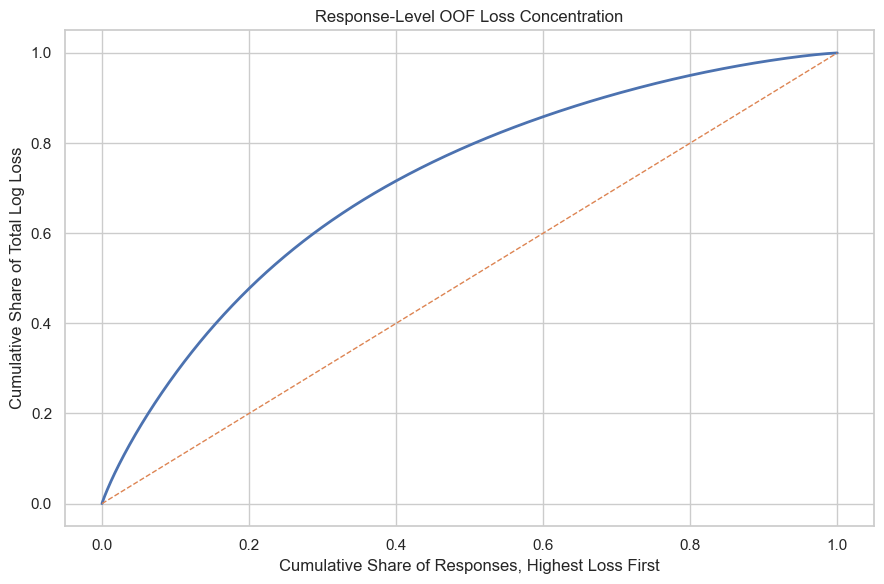

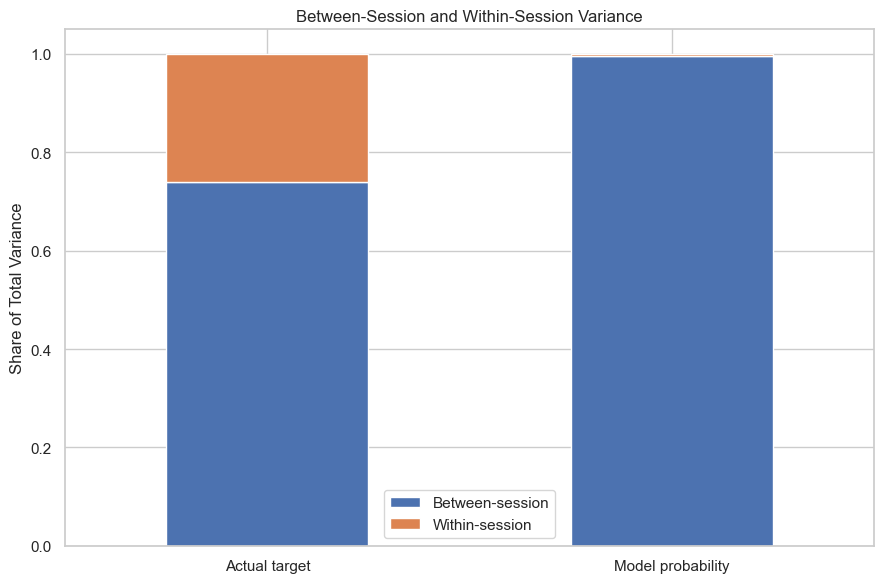

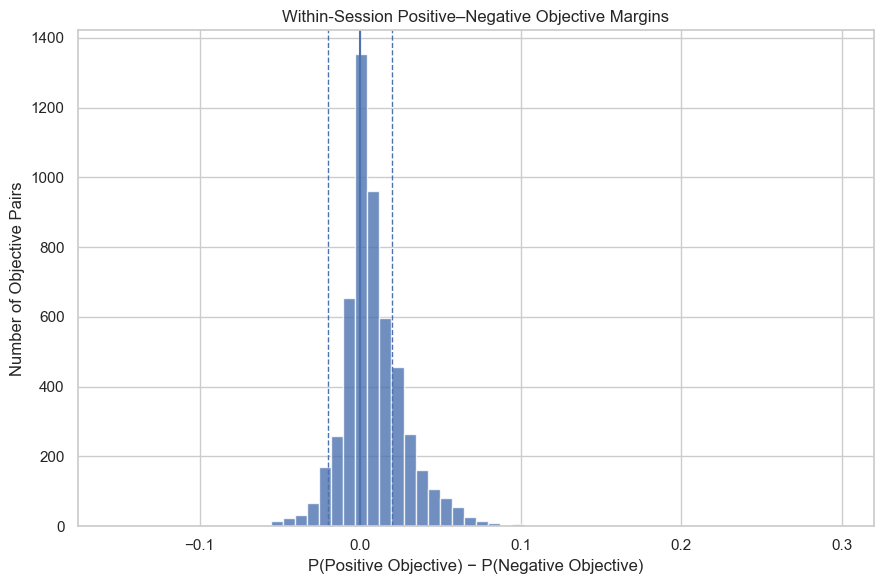

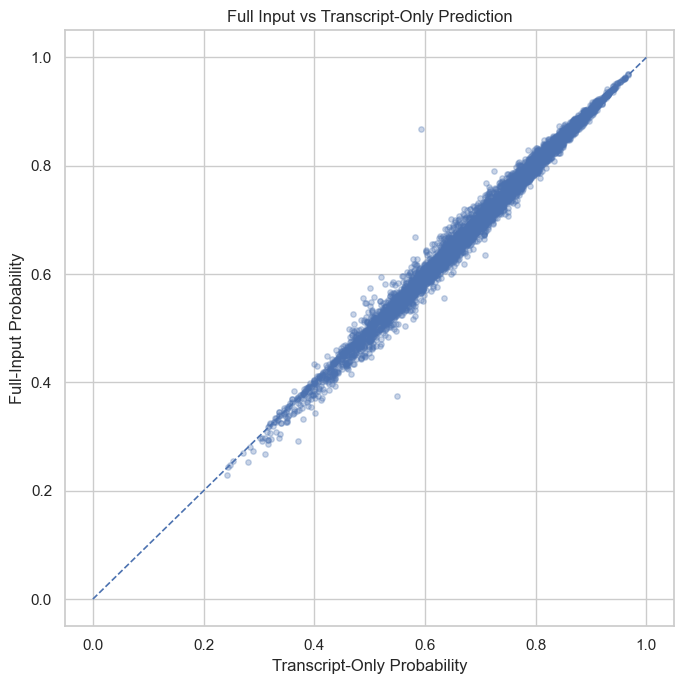

In [7]:
figures_dir = step3_dirs["10_figures"]


# Plot 1: Loss concentration
plt.figure(figsize=(9, 6))

plt.plot(
    response_concentration["cumulative_unit_share"],
    response_concentration["cumulative_loss_share"],
    linewidth=2
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=1
)

plt.title("Response-Level OOF Loss Concentration")
plt.xlabel("Cumulative Share of Responses, Highest Loss First")
plt.ylabel("Cumulative Share of Total Log Loss")
plt.tight_layout()

plt.savefig(
    figures_dir / "response_loss_concentration.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Plot 2: Variance decomposition
variance_plot = variance_summary.set_index("Variable")[
    ["between_share", "within_share"]
]

variance_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.title("Between-Session and Within-Session Variance")
plt.xlabel("")
plt.ylabel("Share of Total Variance")
plt.xticks(rotation=0)
plt.legend(["Between-session", "Within-session"])
plt.tight_layout()

plt.savefig(
    figures_dir / "variance_decomposition.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Plot 3: Within-session pair margins
plt.figure(figsize=(9, 6))

plt.hist(
    mixed_pairs["pairwise_margin"],
    bins=60,
    alpha=0.80
)

plt.axvline(0, linewidth=1.5)
plt.axvline(-0.02, linestyle="--", linewidth=1)
plt.axvline(0.02, linestyle="--", linewidth=1)

plt.title("Within-Session Positive–Negative Objective Margins")
plt.xlabel("P(Positive Objective) − P(Negative Objective)")
plt.ylabel("Number of Objective Pairs")
plt.tight_layout()

plt.savefig(
    figures_dir / "within_session_pairwise_margins.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Plot 4: Full vs transcript-only probability
scatter_sample = counterfactual.sample(
    min(6000, len(counterfactual)),
    random_state=42
)

plt.figure(figsize=(7, 7))

plt.scatter(
    scatter_sample["transcript_only_probability"],
    scatter_sample["full_recomputed"],
    alpha=0.30,
    s=15
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=1.2
)

plt.title("Full Input vs Transcript-Only Prediction")
plt.xlabel("Transcript-Only Probability")
plt.ylabel("Full-Input Probability")
plt.tight_layout()

plt.savefig(
    figures_dir / "full_vs_transcript_only.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

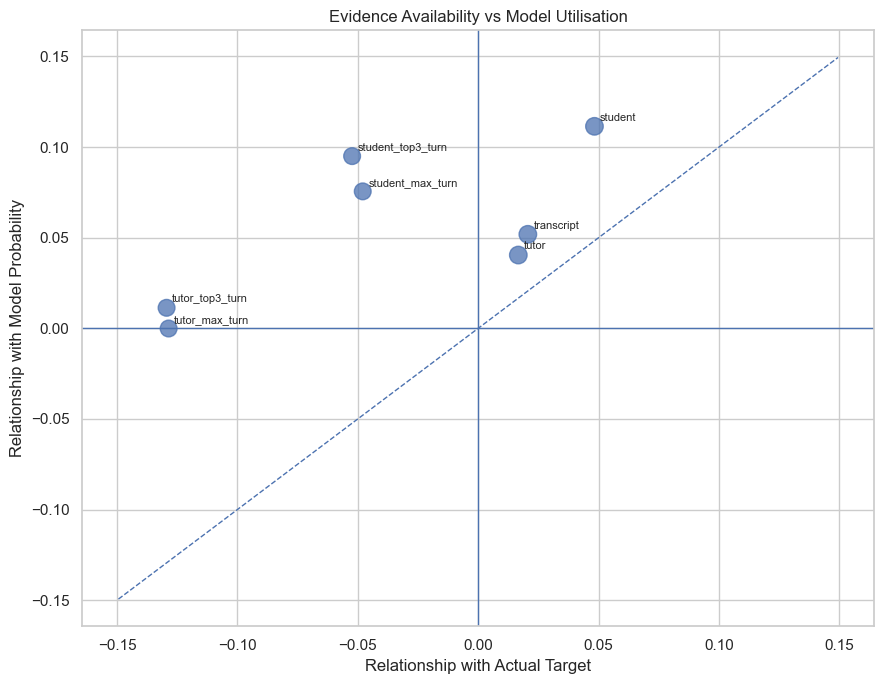

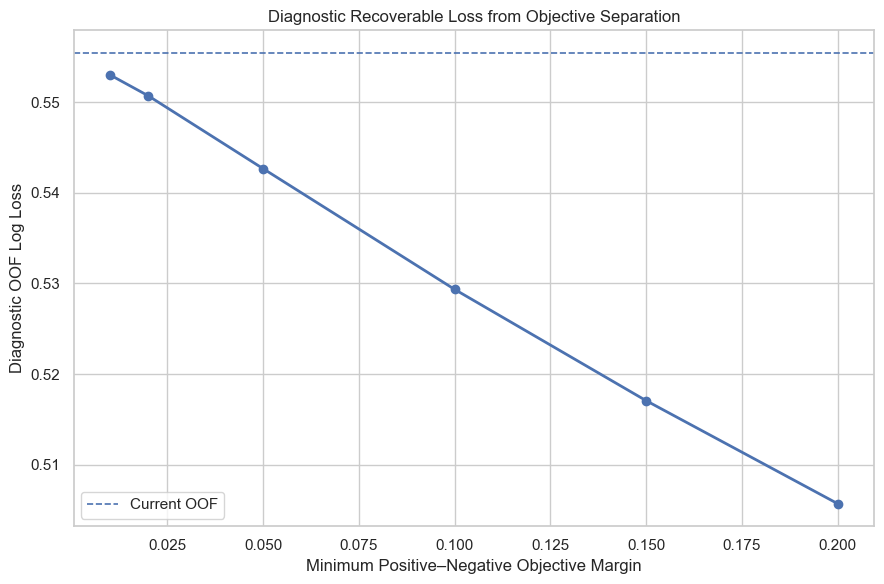

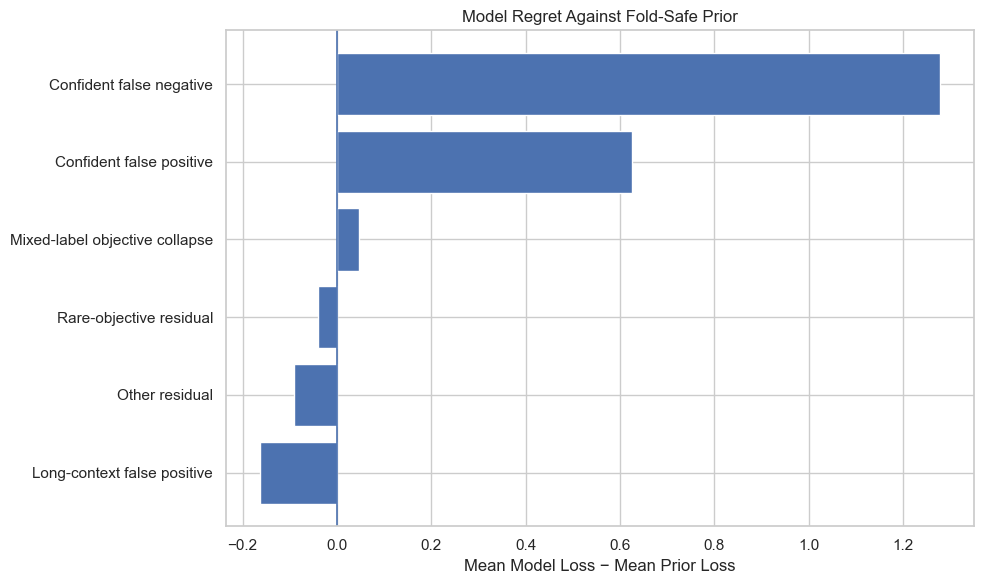

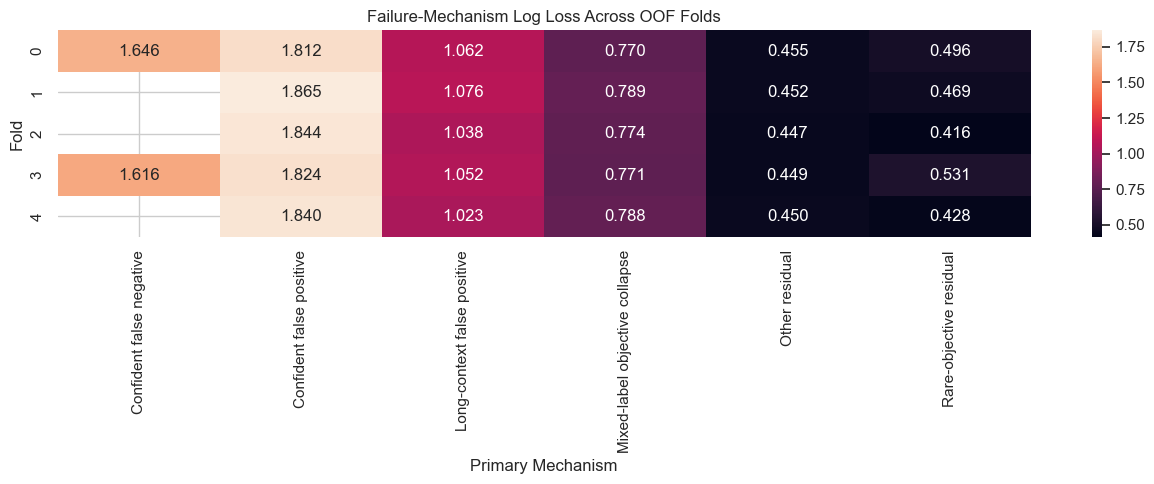

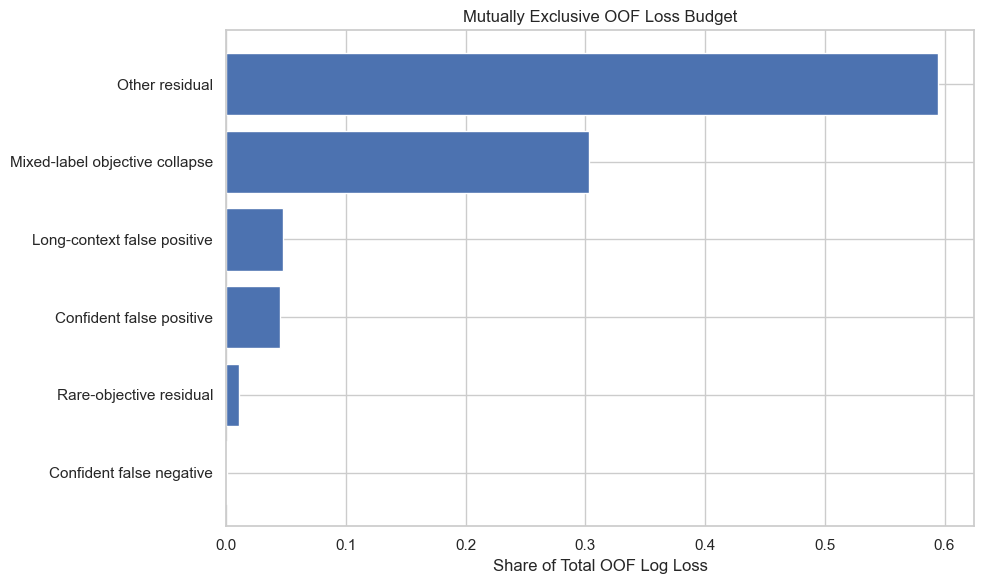

,threshold,error_type,n_rows,row_share,loss_share
0,0.7000,False positive,3722,0.1061,0.3019
1,0.7000,False negative,53,0.0015,0.0036
2,0.8000,False positive,1384,0.0395,0.1363
3,0.8000,False negative,2,0.0001,0.0002
4,0.9000,False positive,126,0.0036,0.0165
5,0.9000,False negative,0,0.0000,0.0000


,prediction_std_threshold,collapse_sessions,response_share,loss_share
0,0.0100,2197,0.1591,0.2284
1,0.0200,2914,0.2159,0.3026
2,0.0500,3204,0.2363,0.3277


In [8]:
# Confidence-threshold sensitivity
confidence_rows = []

for threshold in [0.70, 0.80, 0.90]:
    false_positive_mask = (
        ledger["correct"].eq(0) &
        ledger["probability"].ge(threshold)
    )

    false_negative_mask = (
        ledger["correct"].eq(1) &
        ledger["probability"].le(1 - threshold)
    )

    for error_name, mask in [
        ("False positive", false_positive_mask),
        ("False negative", false_negative_mask)
    ]:
        confidence_rows.append({
            "threshold": threshold,
            "error_type": error_name,
            "n_rows": mask.sum(),
            "row_share": mask.mean(),
            "loss_share": (
                ledger.loc[mask, "sample_log_loss"].sum() /
                ledger["sample_log_loss"].sum()
            )
        })

confidence_sensitivity = pd.DataFrame(confidence_rows)


# Collapse-threshold sensitivity
collapse_rows = []

for threshold in [0.01, 0.02, 0.05]:
    selected_sessions = set(
        session_summary.loc[
            session_summary["mixed_label_session"] &
            session_summary["prediction_std"].lt(threshold),
            "session_id"
        ]
    )

    response_mask = ledger["session_id"].isin(selected_sessions)

    collapse_rows.append({
        "prediction_std_threshold": threshold,
        "collapse_sessions": len(selected_sessions),
        "response_share": response_mask.mean(),
        "loss_share": (
            ledger.loc[response_mask, "sample_log_loss"].sum() /
            ledger["sample_log_loss"].sum()
        )
    })

collapse_sensitivity = pd.DataFrame(collapse_rows)

confidence_sensitivity.to_csv(
    step3_dirs["08_robustness"] / "confidence_threshold_sensitivity.csv",
    index=False
)

collapse_sensitivity.to_csv(
    step3_dirs["08_robustness"] / "collapse_threshold_sensitivity.csv",
    index=False
)


# Plot 5: Evidence availability vs utilisation
plt.figure(figsize=(9, 7))

plt.scatter(
    evidence_utilisation["target_relationship"],
    evidence_utilisation["prediction_relationship"],
    s=120 + evidence_utilisation["available_rows"] ** 0.35,
    alpha=0.75
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plot_limit = max(
    evidence_utilisation[
        ["target_relationship", "prediction_relationship"]
    ].abs().max()
) + 0.02

plt.plot(
    [-plot_limit, plot_limit],
    [-plot_limit, plot_limit],
    linestyle="--",
    linewidth=1
)

for row in evidence_utilisation.itertuples():
    plt.annotate(
        row.evidence_feature.replace("objective_", "").replace("_relevance", ""),
        (row.target_relationship, row.prediction_relationship),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Evidence Availability vs Model Utilisation")
plt.xlabel("Relationship with Actual Target")
plt.ylabel("Relationship with Model Probability")
plt.tight_layout()

plt.savefig(
    figures_dir / "evidence_utilisation_map.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Plot 6: Recoverable loss curve
plt.figure(figsize=(9, 6))

plt.plot(
    recoverable_loss_curve["target_objective_gap"],
    recoverable_loss_curve["diagnostic_oof_log_loss"],
    marker="o",
    linewidth=2
)

plt.axhline(
    original_log_loss,
    linestyle="--",
    linewidth=1.2,
    label="Current OOF"
)

plt.title("Diagnostic Recoverable Loss from Objective Separation")
plt.xlabel("Minimum Positive–Negative Objective Margin")
plt.ylabel("Diagnostic OOF Log Loss")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_dir / "recoverable_loss_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Plot 7: Model regret by mechanism
regret_plot = mechanism_summary.sort_values(
    "mean_regret"
)

plt.figure(figsize=(10, 6))

plt.barh(
    regret_plot["primary_mechanism"],
    regret_plot["mean_regret"]
)

plt.axvline(0, linewidth=1.2)

plt.title("Model Regret Against Fold-Safe Prior")
plt.xlabel("Mean Model Loss − Mean Prior Loss")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    figures_dir / "model_regret_by_mechanism.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Plot 8: Fold × mechanism stability
mechanism_heatmap = fold_mechanism_summary.pivot(
    index="fold_id",
    columns="primary_mechanism",
    values="mean_loss"
)

plt.figure(figsize=(13, 5))

sns.heatmap(
    mechanism_heatmap,
    annot=True,
    fmt=".3f"
)

plt.title("Failure-Mechanism Log Loss Across OOF Folds")
plt.xlabel("Primary Mechanism")
plt.ylabel("Fold")
plt.tight_layout()

plt.savefig(
    figures_dir / "fold_mechanism_stability.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Plot 9: Mechanism loss budget
mechanism_plot = mechanism_summary.sort_values(
    "loss_share",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    mechanism_plot["primary_mechanism"],
    mechanism_plot["loss_share"]
)

plt.title("Mutually Exclusive OOF Loss Budget")
plt.xlabel("Share of Total OOF Log Loss")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    figures_dir / "mechanism_loss_budget.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

display(confidence_sensitivity)
display(collapse_sensitivity)

## Step 3 Final Decision Framework

Step 3 is complete only when the following statement can be filled using measured evidence:

> **The baseline behaves primarily as a ______ model. Objective-specific evidence is ______ in the transcript but is ______ by the model. This failure contributes approximately ______ of total OOF loss. A realistic improvement in objective separation could reduce Log Loss by approximately ______. Therefore, the scratch model must include ______.**

Each finding is evaluated through:

| Dimension | Decision Question |
|---|---|
| Generalisation impact | How much OOF Log Loss is affected? |
| Session specificity | Does the model react when only the objective changes? |
| Evidence availability | Does relevant student or tutor evidence exist? |
| Evidence utilisation | Does probability reflect that evidence? |
| Robustness | Does the result remain stable across folds and thresholds? |
| Actionability | Does the finding imply a clear architecture change? |

In [9]:
# Key measured values
collapse_row = mechanism_summary.loc[
    mechanism_summary["primary_mechanism"].eq(
        "Mixed-label objective collapse"
    )
]

collapse_loss_share = (
    collapse_row["loss_share"].iloc[0]
    if len(collapse_row) else np.nan
)

collapse_row_share = (
    collapse_row["row_share"].iloc[0]
    if len(collapse_row) else np.nan
)

moderate_gain = recoverable_summary.loc[
    recoverable_summary["Estimate"].eq(
        "Moderate separation"
    ),
    "Gain vs current"
].iloc[0]

student_evidence_row = evidence_utilisation.loc[
    evidence_utilisation["evidence_feature"].eq(
        "objective_student_relevance"
    )
]

student_target_relationship = (
    student_evidence_row["target_relationship"].iloc[0]
    if len(student_evidence_row) else np.nan
)

student_prediction_relationship = (
    student_evidence_row["prediction_relationship"].iloc[0]
    if len(student_evidence_row) else np.nan
)

student_utilisation_gap = (
    student_evidence_row["utilisation_gap"].iloc[0]
    if len(student_evidence_row) else np.nan
)


# Objective-specificity scorecard
scorecard = pd.DataFrame([
    {
        "Dimension": "Session dominance",
        "Metric": "Between-session prediction variance share",
        "Value": prediction_variance["between_share"],
        "Interpretation": (
            "High session dependence"
            if prediction_variance["between_share"] >= 0.80
            else "Moderate session dependence"
        )
    },
    {
        "Dimension": "Objective responsiveness",
        "Metric": "Prediction-to-target within-session variation ratio",
        "Value": objective_responsiveness_ratio,
        "Interpretation": (
            "Weak objective responsiveness"
            if objective_responsiveness_ratio < 0.30
            else "Meaningful objective responsiveness"
        )
    },
    {
        "Dimension": "Within-session ranking",
        "Metric": "Positive-negative pairwise accuracy",
        "Value": pairwise_accuracy,
        "Interpretation": (
            "Near-random objective ranking"
            if pairwise_accuracy < 0.57
            else "Useful objective ranking"
        )
    },
    {
        "Dimension": "Objective added value",
        "Metric": "Session-mean LL minus original LL",
        "Value": objective_added_value,
        "Interpretation": (
            "Very limited objective contribution"
            if objective_added_value < 0.005
            else "Measurable objective contribution"
        )
    },
    {
        "Dimension": "Transcript dominance",
        "Metric": "Full-input closeness to transcript-only view",
        "Value": transcript_dominance_score,
        "Interpretation": (
            "Transcript-dominated prediction"
            if transcript_dominance_score >= 0.75
            else "Balanced input contribution"
        )
    },
    {
        "Dimension": "Recoverable loss",
        "Metric": "Moderate objective-separation LL gain",
        "Value": moderate_gain,
        "Interpretation": (
            "High-value objective-specific opportunity"
            if moderate_gain >= 0.005
            else "Limited direct recovery"
        )
    }
])


# Architecture decision matrix
architecture_rows = [
    {
        "Requirement": "Objective-conditioned relevant-turn retrieval",
        "Evidence": (
            f"Pairwise accuracy={pairwise_accuracy:.4f}; "
            f"responsiveness ratio={objective_responsiveness_ratio:.4f}"
        ),
        "Priority": "Critical"
    },
    {
        "Requirement": "Separate student and tutor evidence channels",
        "Evidence": (
            f"Student evidence target relationship="
            f"{student_target_relationship:.4f}; "
            f"utilisation gap={student_utilisation_gap:.4f}"
        ),
        "Priority": "High"
    },
    {
        "Requirement": "Within-session contrastive objective modelling",
        "Evidence": (
            f"Reversed pair rate={reversed_pair_rate:.4f}; "
            f"collapse loss share={collapse_loss_share:.4f}"
        ),
        "Priority": "Critical"
    },
    {
        "Requirement": "Fold-safe objective difficulty prior",
        "Evidence": (
            f"Mean OOF model regret="
            f"{ledger['model_regret'].mean():.4f}"
        ),
        "Priority": "Medium"
    },
    {
        "Requirement": "Probability calibration after ranking improvement",
        "Evidence": (
            f"Current OOF Log Loss={original_log_loss:.6f}; "
            f"moderate separation gain={moderate_gain:.6f}"
        ),
        "Priority": "High"
    },
    {
        "Requirement": "Uncertainty handling for weak-evidence objectives",
        "Evidence": (
            "Rare objectives and low-relevance responses remain "
            "high-variance residual groups."
        ),
        "Priority": "High"
    }
]

architecture_requirements = pd.DataFrame(architecture_rows)


# Final mechanism report
report_text = f"""# Step 3 — Objective-Specificity Mechanism Report

## Master Finding

The baseline's prediction variance is dominated by between-session differences. 
The between-session prediction variance share is {prediction_variance["between_share"]:.4f}, 
while the objective-responsiveness ratio is {objective_responsiveness_ratio:.4f}.

## Within-Session Objective Ranking

- Positive-negative pairwise accuracy: {pairwise_accuracy:.4f}
- Reversed pair rate: {reversed_pair_rate:.4f}
- Original OOF Log Loss: {original_log_loss:.6f}
- Session-mean Log Loss: {session_mean_log_loss:.6f}
- Objective added value: {objective_added_value:.6f}

## Input Dominance

- Transcript dominance score: {transcript_dominance_score:.4f}
- Maximum full-input reproduction difference: {maximum_reproduction_difference:.10f}

## Objective Evidence

- Student relevance vs target: {student_target_relationship:.4f}
- Student relevance vs prediction: {student_prediction_relationship:.4f}
- Student evidence utilisation gap: {student_utilisation_gap:.4f}

## Collapse Burden

- Collapse response share: {collapse_row_share:.4f}
- Collapse total loss share: {collapse_loss_share:.4f}

## Recoverable-Loss Estimate

- Moderate objective-separation gain: {moderate_gain:.6f}
- Diagnostic oracle Log Loss: {oracle_log_loss:.6f}
- Diagnostic oracle gain: {original_log_loss - oracle_log_loss:.6f}

## Architecture Decision

The scratch model should prioritise objective-conditioned dialogue retrieval, 
student-tutor evidence separation, within-session contrastive objective modelling, 
semantic objective interaction and probability calibration.

The oracle and margin simulations are diagnostic upper bounds and must not be 
interpreted as deployable validation performance.
"""

with open(
    step3_dirs["11_final_decision"] / "step3_mechanism_report.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(report_text)


# Save final tables
scorecard.to_csv(
    step3_dirs["11_final_decision"] / "objective_specificity_scorecard.csv",
    index=False
)

architecture_requirements.to_csv(
    step3_dirs["11_final_decision"] / "architecture_requirements.csv",
    index=False
)

mechanism_summary.to_csv(
    step3_dirs["11_final_decision"] / "actionable_loss_map.csv",
    index=False
)

recoverable_summary.to_csv(
    step3_dirs["11_final_decision"] / "recoverable_loss_summary.csv",
    index=False
)


final_outputs = pd.DataFrame({
    "Output": [
        "Response loss ledger",
        "Variance decomposition",
        "Mixed-session pairs",
        "Input ablation predictions",
        "Evidence utilisation analysis",
        "Recoverable-loss curve",
        "Loss mechanism budget",
        "Robustness tables",
        "Review sample",
        "Objective-specificity scorecard",
        "Architecture requirements",
        "Final mechanism report"
    ],
    "Folder": [
        "00_loss_ledger",
        "01_session_levelness",
        "02_within_session_ranking",
        "03_input_ablation",
        "04_evidence_relevance",
        "05_recoverable_loss",
        "07_loss_budgets",
        "08_robustness",
        "09_review_sampling",
        "11_final_decision",
        "11_final_decision",
        "11_final_decision"
    ]
})

print("Step 3 completed successfully.")
display(scorecard)
display(architecture_requirements)
display(final_outputs)

Step 3 completed successfully.


,Dimension,Metric,Value,Interpretation
0,Session dominance,Between-session prediction variance share,0.9967,High session dependence
1,Objective responsiveness,Prediction-to-target within-session variation ratio,0.0343,Weak objective responsiveness
2,Within-session ranking,Positive-negative pairwise accuracy,0.6793,Useful objective ranking
3,Objective added value,Session-mean LL minus original LL,0.0022,Very limited objective contribution
4,Transcript dominance,Full-input closeness to transcript-only view,0.9450,Transcript-dominated prediction
5,Recoverable loss,Moderate objective-separation LL gain,0.0261,High-value objective-specific opportunity


,Requirement,Evidence,Priority
0,Objective-conditioned relevant-turn retrieval,Pairwise accuracy=0.6793; responsiveness ratio=0.0343,Critical
1,Separate student and tutor evidence channels,Student evidence target relationship=0.0483; utilisation gap=-0.0632,High
2,Within-session contrastive objective modelling,Reversed pair rate=0.3207; collapse loss share=0.3026,Critical
3,Fold-safe objective difficulty prior,Mean OOF model regret=-0.0533,Medium
4,Probability calibration after ranking improvement,Current OOF Log Loss=0.555460; moderate separation gain=0.026113,High
5,Uncertainty handling for weak-evidence objectives,Rare objectives and low-relevance responses remain high-variance residual groups.,High


,Output,Folder
0,Response loss ledger,00_loss_ledger
1,Variance decomposition,01_session_levelness
2,Mixed-session pairs,02_within_session_ranking
3,Input ablation predictions,03_input_ablation
4,Evidence utilisation analysis,04_evidence_relevance
5,Recoverable-loss curve,05_recoverable_loss
6,Loss mechanism budget,07_loss_budgets
7,Robustness tables,08_robustness
8,Review sample,09_review_sampling
9,Objective-specificity scorecard,11_final_decision


# Step 3 — Objective-Specificity Analysis Summary

## 1. Baseline Performance

| Metric | Result |
|---|---:|
| Trusted OOF Log Loss | **0.555460** |
| OOF AUROC | **0.700693** |
| Fold stability | Consistent across all five folds |
| Main error direction | False positive |

---

## 2. Session vs Objective Behaviour

| Diagnostic | Result | Meaning |
|---|---:|---|
| Between-session prediction variance | **99.67%** | Prediction is almost fully controlled by the session |
| Objective responsiveness ratio | **3.43%** | The model reacts very little when only the objective changes |
| Transcript dominance score | **94.50%** | Full-input predictions are almost identical to transcript-only predictions |
| Objective added value | **0.002174 LL** | Current objective-specific contribution is very limited |

> The baseline behaves mainly as a **session-level transcript model**, not a true session–objective model.

---

## 3. Within-Session Objective Discrimination

| Metric | Result |
|---|---:|
| Positive–negative objective pairwise accuracy | **67.93%** |
| Reversed objective ranking rate | **32.07%** |
| Collapse response share | **21.59%** |
| Collapse total loss share | **30.26%** |

- The model captures some objective direction, but the probability margins are usually very small.
- In many mixed-label sessions, correct and incorrect objectives receive almost identical probabilities.
- Collapse cases produce approximately **1.4 times more loss** than expected from their response share.

---

## 4. Evidence and Error Findings

| Finding | Interpretation |
|---|---|
| Student relevance relates more strongly to prediction than to target | The model may overuse lexical overlap and student verbosity |
| Highly relevant tutor turns relate negatively to correctness | High tutor intervention may indicate student struggle |
| False positives produce more than half of total loss | Incorrect responses are often predicted with excessive positive confidence |
| Objective-level loss is highly concentrated | A small group of objectives creates a large share of total loss |

### Important Insight

- Objective relevance alone is not enough.
- A relevant turn may represent mastery, confusion, repetition or tutor intervention.
- The next model must understand **speaker, intent, timing and evidence polarity**.

---

## 5. Recoverable-Loss Opportunity

| Objective Separation Scenario | Diagnostic Log Loss | Gain |
|---|---:|---:|
| Current model | **0.555460** | — |
| Small separation, margin 0.05 | **0.542678** | **0.012782** |
| Moderate separation, margin 0.10 | **0.529347** | **0.026113** |
| Strong separation, margin 0.20 | **0.505685** | **0.049775** |
| Label-informed oracle | **0.398219** | **0.157241** |

> These are diagnostic simulations, not deployable validation scores. They show that objective discrimination contains a large improvement opportunity.

---

## Required Direction for the Next Model

- Objective-conditioned relevant-turn retrieval
- Separate student, tutor and feedback evidence channels
- Mastery-versus-struggle detection
- Within-session contrastive objective modelling
- Semantic objective–dialogue interaction
- Fold-safe objective difficulty priors
- False-positive control and final probability calibration

## Final Conclusion

> The current baseline has useful predictive signal, but it is dominated by the shared transcript and does not create enough separation between learning objectives.

> The next model must not only retrieve objective-related text; it must understand **who said it, why it was said, when it occurred and whether it represents mastery or struggle**.

In [1]:
from pathlib import Path
import gc
import json
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import sparse
from scipy.special import expit
from sklearn.metrics import log_loss


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

sns.set_theme(style="whitegrid")


# --------------------------------------------------
# Restore project paths
# --------------------------------------------------
current_dir = Path.cwd().resolve()
search_locations = [current_dir, *current_dir.parents]

project_root = next(
    path for path in search_locations
    if (path / "Trace-The-Race-Dataset").is_dir()
)

dataset_root = project_root / "Trace-The-Race-Dataset"

analysis_root = (
    project_root
    / "notebook"
    / "model_analysis"
    / "baselineanalysis"
)

step2_root = analysis_root / "02_oof_analysis"
step3_root = analysis_root / "03_loss_analysis"
step4_root = analysis_root / "04_shap_analysis"

fold_models_dir = step2_root / "01_fold_models"


# --------------------------------------------------
# Step 4 output folders
# --------------------------------------------------
folder_names = [
    "00_setup",
    "01_fold_backgrounds",
    "02_global_coefficients",
    "03_oof_contributions",
    "04_intercept_lexical_decomposition",
    "05_source_provenance",
    "06_objective_identity",
    "07_error_fingerprints",
    "08_same_session_pairs",
    "09_collapse_mechanism",
    "10_lexical_families",
    "11_loss_weighted_responsibility",
    "12_counterfactual_masking",
    "13_robustness",
    "14_casebook",
    "15_figures",
    "16_final_decision"
]

step4_dirs = {}

for folder_name in folder_names:
    folder_path = step4_root / folder_name
    folder_path.mkdir(parents=True, exist_ok=True)
    step4_dirs[folder_name] = folder_path


# --------------------------------------------------
# Restore Step 3 outputs
# --------------------------------------------------
ledger_path = (
    step3_root
    / "00_loss_ledger"
    / "response_loss_ledger.parquet"
)

mixed_pairs_path = (
    step3_root
    / "02_within_session_ranking"
    / "mixed_session_pairs.parquet"
)

session_summary_path = (
    step3_root
    / "01_session_levelness"
    / "session_summary.csv"
)

ledger = pd.read_parquet(ledger_path).reset_index(drop=True)
mixed_pairs = pd.read_parquet(mixed_pairs_path)
session_summary = pd.read_csv(session_summary_path)


# --------------------------------------------------
# Standardise key columns
# --------------------------------------------------
ledger["response_id"] = ledger["response_id"].astype("string")
ledger["session_id"] = ledger["session_id"].astype("string")
ledger["objective_key"] = ledger["objective_key"].astype("string")
ledger["fold_id"] = ledger["fold_id"].astype(int)

mixed_pairs["positive_response_id"] = (
    mixed_pairs["positive_response_id"].astype("string")
)

mixed_pairs["negative_response_id"] = (
    mixed_pairs["negative_response_id"].astype("string")
)

for column in [
    "learning_objective",
    "transcript_text",
    "student_text",
    "tutor_text"
]:
    if column not in ledger.columns:
        ledger[column] = ""

    ledger[column] = (
        ledger[column]
        .fillna("")
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )


# Reconstruct the exact Step 2 model input
ledger["model_text"] = (
    "[OBJECTIVE] "
    + ledger["learning_objective"]
    + "\n[TRANSCRIPT] "
    + ledger["transcript_text"]
)

ledger["correct"] = ledger["correct"].astype(np.int8)
ledger["probability"] = ledger["probability"].clip(1e-6, 1 - 1e-6)

fold_ids = sorted(ledger["fold_id"].unique())

TOP_K = 10
EPSILON = 1e-9


# Create missing diagnostic columns only when required
if "error_direction" not in ledger.columns:
    conditions = [
        ledger["correct"].eq(1) & ledger["probability"].ge(0.5),
        ledger["correct"].eq(0) & ledger["probability"].lt(0.5),
        ledger["correct"].eq(0) & ledger["probability"].ge(0.5),
        ledger["correct"].eq(1) & ledger["probability"].lt(0.5)
    ]

    labels = [
        "True positive",
        "True negative",
        "False positive",
        "False negative"
    ]

    ledger["error_direction"] = np.select(
        conditions,
        labels,
        default="Unknown"
    )


if "collapse_candidate" not in ledger.columns:
    collapse_sessions = set(
        session_summary.loc[
            session_summary["collapse_candidate"].eq(True),
            "session_id"
        ].astype("string")
    )

    ledger["collapse_candidate"] = (
        ledger["session_id"].isin(collapse_sessions)
    )


restore_summary = pd.DataFrame({
    "Item": [
        "OOF responses",
        "Unique sessions",
        "Learning objectives",
        "OOF folds",
        "Mixed-label objective pairs",
        "Top local features per direction",
        "Step 4 output root"
    ],
    "Value": [
        len(ledger),
        ledger["session_id"].nunique(),
        ledger["objective_key"].nunique(),
        len(fold_ids),
        len(mixed_pairs),
        TOP_K,
        str(step4_root)
    ]
})

print("Step 4 state restored successfully.")
display(restore_summary)

Step 4 state restored successfully.


,Item,Value
0,OOF responses,35072
1,Unique sessions,22821
2,Learning objectives,396
3,OOF folds,5
4,Mixed-label objective pairs,5323
5,Top local features per direction,10
6,Step 4 output root,C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\notebook\model_analysis\baselineanalysis\04_...


# Step 4 — Fold-Specific SHAP and Lexical Decision-Mechanism Audit

## Master Research Question

> **Which parts of the fold-safe OOF prediction—global intercept, objective identity, shared transcript language, student evidence, tutor intervention and feedback language—cause the baseline to become correctly or incorrectly confident, and which stable lexical mechanisms explain objective collapse and costly false positives?**

## Research Objectives

This stage investigates:

1. Which lexical features raise or lower correctness probability.
2. Whether predictions are driven by the fold intercept, objective text or transcript language.
3. Whether student and tutor language create different contribution patterns.
4. Why high-confidence false positives occur.
5. Whether positive and negative objectives from the same session receive similar explanations.
6. Which lexical signals should be preserved, strengthened, separated, suppressed or semantically reinterpreted.

## Important Rules

- Every OOF response is explained using its own saved fold model.
- No new predictive model is trained.
- SHAP describes model behaviour, not causal truth.
- Raw logit contribution and fold-centred SHAP are reported separately.
- Feature stability is evaluated across folds and response support.
- Source provenance is diagnostic because the original model uses concatenated text.

In [ ]:
# --------------------------------------------------
# Numerical fidelity tolerances
# --------------------------------------------------
# Saved OOF probabilities may contain float32-level rounding,
# while reconstructed probabilities are calculated in float64.
PROBABILITY_TOLERANCE = 2e-6
LOGIT_TOLERANCE = 1e-12


def extract_top_contributions(
    contribution_matrix,
    feature_names,
    response_ids,
    fold_id,
    top_k=10
):
    contribution_rows = []

    for row_position in range(
        contribution_matrix.shape[0]
    ):
        row = contribution_matrix.getrow(row_position)

        feature_indices = row.indices
        contribution_values = row.data

        positive_positions = np.where(
            contribution_values > 0
        )[0]

        negative_positions = np.where(
            contribution_values < 0
        )[0]

        # Top positive contributions
        if len(positive_positions):
            positive_order = positive_positions[
                np.argsort(
                    contribution_values[
                        positive_positions
                    ]
                )[::-1][:top_k]
            ]

            for rank, position in enumerate(
                positive_order,
                start=1
            ):
                contribution_rows.append({
                    "response_id": response_ids[
                        row_position
                    ],
                    "fold_id": fold_id,
                    "direction": "Positive",
                    "rank": rank,
                    "feature": str(
                        feature_names[
                            feature_indices[position]
                        ]
                    ),
                    "contribution": float(
                        contribution_values[position]
                    ),
                    "absolute_contribution": float(
                        abs(
                            contribution_values[position]
                        )
                    )
                })

        # Top negative contributions
        if len(negative_positions):
            negative_order = negative_positions[
                np.argsort(
                    contribution_values[
                        negative_positions
                    ]
                )[:top_k]
            ]

            for rank, position in enumerate(
                negative_order,
                start=1
            ):
                contribution_rows.append({
                    "response_id": response_ids[
                        row_position
                    ],
                    "fold_id": fold_id,
                    "direction": "Negative",
                    "rank": rank,
                    "feature": str(
                        feature_names[
                            feature_indices[position]
                        ]
                    ),
                    "contribution": float(
                        contribution_values[position]
                    ),
                    "absolute_contribution": float(
                        abs(
                            contribution_values[position]
                        )
                    )
                })

    return contribution_rows


# --------------------------------------------------
# Containers
# --------------------------------------------------
contribution_summary_tables = []
top_contribution_rows = []
fidelity_records = []


# --------------------------------------------------
# Explain every OOF fold using its own saved model
# --------------------------------------------------
for fold_id in fold_ids:
    fold_dir = fold_models_dir / f"fold_{fold_id}"

    vectorizer = joblib.load(
        fold_dir / "word_tfidf_vectorizer.joblib"
    )

    model = joblib.load(
        fold_dir / "word_logistic.joblib"
    )

    fold_mask = ledger["fold_id"].eq(fold_id)

    fold_data = (
        ledger.loc[fold_mask]
        .copy()
        .reset_index(drop=True)
    )

    X_fold = vectorizer.transform(
        fold_data["model_text"]
    ).tocsr()

    coefficients = (
        model.coef_
        .ravel()
        .astype(np.float64)
    )

    intercept = float(
        model.intercept_[0]
    )

    feature_names = (
        vectorizer.get_feature_names_out()
    )


    # --------------------------------------------------
    # Exact active-feature logit contributions
    # contribution = TF-IDF value × model coefficient
    # --------------------------------------------------
    contribution_matrix = X_fold.multiply(
        coefficients
    ).tocsr()

    positive_matrix = (
        contribution_matrix.maximum(0)
    )

    negative_matrix = (
        contribution_matrix.minimum(0)
    )


    raw_contribution_sum = np.asarray(
        contribution_matrix.sum(axis=1)
    ).ravel()

    positive_contribution_sum = np.asarray(
        positive_matrix.sum(axis=1)
    ).ravel()

    negative_contribution_sum = np.asarray(
        negative_matrix.sum(axis=1)
    ).ravel()


    # --------------------------------------------------
    # Exact raw-logit reconstruction
    # --------------------------------------------------
    final_logit = (
        intercept
        +
        raw_contribution_sum
    )

    reconstructed_probability = expit(
        final_logit
    )


    # --------------------------------------------------
    # Restore fold-centred SHAP background
    # --------------------------------------------------
    training_mean = np.load(
        step4_dirs["01_fold_backgrounds"]
        / (
            f"fold_{fold_id}_"
            "training_feature_mean.npy"
        )
    )

    background_contribution = np.load(
        step4_dirs["01_fold_backgrounds"]
        / (
            f"fold_{fold_id}_"
            "background_contribution.npy"
        )
    )

    background_sum = float(
        background_contribution.sum()
    )

    centred_base_value = (
        intercept
        +
        background_sum
    )

    centred_shap_sum = (
        raw_contribution_sum
        -
        background_sum
    )

    centred_reconstructed_logit = (
        centred_base_value
        +
        centred_shap_sum
    )


    # --------------------------------------------------
    # Contribution vector norms
    # Used later for same-session cosine similarity
    # --------------------------------------------------
    raw_norm_squared = np.asarray(
        contribution_matrix.multiply(
            contribution_matrix
        ).sum(axis=1)
    ).ravel()

    raw_l2_norm = np.sqrt(
        np.maximum(
            raw_norm_squared,
            0
        )
    )

    raw_absolute_mass = np.asarray(
        abs(contribution_matrix).sum(axis=1)
    ).ravel()

    raw_dot_background = np.asarray(
        contribution_matrix.dot(
            background_contribution
        )
    ).ravel()

    background_norm_squared = float(
        np.dot(
            background_contribution,
            background_contribution
        )
    )

    centred_norm_squared = (
        raw_norm_squared
        -
        2 * raw_dot_background
        +
        background_norm_squared
    )

    centred_l2_norm = np.sqrt(
        np.maximum(
            centred_norm_squared,
            0
        )
    )


    # --------------------------------------------------
    # Response-level contribution summary
    # --------------------------------------------------
    fold_summary = pd.DataFrame({
        "response_id": (
            fold_data["response_id"].to_numpy()
        ),
        "fold_id": fold_id,
        "fold_row_index": np.arange(
            len(fold_data)
        ),
        "intercept_logit": intercept,
        "intercept_probability": expit(
            intercept
        ),
        "raw_positive_contribution": (
            positive_contribution_sum
        ),
        "raw_negative_contribution": (
            negative_contribution_sum
        ),
        "raw_contribution_sum": (
            raw_contribution_sum
        ),
        "final_logit": final_logit,
        "reconstructed_probability": (
            reconstructed_probability
        ),
        "centred_shap_base_value": (
            centred_base_value
        ),
        "centred_shap_sum": (
            centred_shap_sum
        ),
        "raw_l2_norm": raw_l2_norm,
        "raw_absolute_mass": (
            raw_absolute_mass
        ),
        "raw_dot_background": (
            raw_dot_background
        ),
        "centred_l2_norm": (
            centred_l2_norm
        )
    })

    contribution_summary_tables.append(
        fold_summary
    )


    # --------------------------------------------------
    # Store top local positive and negative features
    # --------------------------------------------------
    top_contribution_rows.extend(
        extract_top_contributions(
            contribution_matrix=(
                contribution_matrix
            ),
            feature_names=feature_names,
            response_ids=(
                fold_data[
                    "response_id"
                ].to_numpy()
            ),
            fold_id=fold_id,
            top_k=TOP_K
        )
    )


    # --------------------------------------------------
    # Fidelity checks
    # --------------------------------------------------
    saved_probability = (
        fold_data["probability"]
        .to_numpy(dtype=np.float64)
    )

    probability_difference = np.abs(
        reconstructed_probability
        -
        saved_probability
    )

    logit_difference = np.abs(
        final_logit
        -
        centred_reconstructed_logit
    )

    maximum_probability_difference = float(
        probability_difference.max()
    )

    mean_probability_difference = float(
        probability_difference.mean()
    )

    maximum_logit_difference = float(
        logit_difference.max()
    )

    fidelity_pass = bool(
        maximum_probability_difference
        <= PROBABILITY_TOLERANCE
        and
        maximum_logit_difference
        <= LOGIT_TOLERANCE
    )

    fidelity_records.append({
        "fold_id": fold_id,
        "maximum_probability_difference": (
            maximum_probability_difference
        ),
        "mean_probability_difference": (
            mean_probability_difference
        ),
        "maximum_logit_difference": (
            maximum_logit_difference
        ),
        "probability_tolerance": (
            PROBABILITY_TOLERANCE
        ),
        "logit_tolerance": (
            LOGIT_TOLERANCE
        ),
        "fidelity_pass": fidelity_pass
    })


    # --------------------------------------------------
    # Save fold-level sparse artifacts
    # --------------------------------------------------
    sparse.save_npz(
        step4_dirs["03_oof_contributions"]
        / (
            f"fold_{fold_id}_"
            "raw_contributions.npz"
        ),
        contribution_matrix
    )

    np.save(
        step4_dirs["03_oof_contributions"]
        / (
            f"fold_{fold_id}_"
            "response_ids.npy"
        ),
        fold_data[
            "response_id"
        ].astype(str).to_numpy()
    )


    print(
        f"Fold {fold_id} completed | "
        f"Max probability difference: "
        f"{maximum_probability_difference:.12f} | "
        f"Fidelity pass: {fidelity_pass}"
    )


    # --------------------------------------------------
    # Release temporary fold objects
    # --------------------------------------------------
    del (
        vectorizer,
        model,
        X_fold,
        contribution_matrix,
        positive_matrix,
        negative_matrix,
        training_mean,
        background_contribution
    )

    gc.collect()


# --------------------------------------------------
# Combine all folds
# --------------------------------------------------
response_contribution_summary = pd.concat(
    contribution_summary_tables,
    ignore_index=True
)

top_contributions = pd.DataFrame(
    top_contribution_rows
)

fidelity_summary = pd.DataFrame(
    fidelity_records
)


# --------------------------------------------------
# Save combined Step 4 contribution artifacts
# --------------------------------------------------
response_contribution_summary.to_parquet(
    step4_dirs["03_oof_contributions"]
    / "response_contribution_summary.parquet",
    index=False
)

top_contributions.to_parquet(
    step4_dirs["03_oof_contributions"]
    / "top_local_contributions.parquet",
    index=False
)

fidelity_summary.to_csv(
    step4_dirs["03_oof_contributions"]
    / "explanation_fidelity.csv",
    index=False
)


# --------------------------------------------------
# Final fidelity report
# --------------------------------------------------
global_max_probability_difference = (
    fidelity_summary[
        "maximum_probability_difference"
    ].max()
)

global_max_logit_difference = (
    fidelity_summary[
        "maximum_logit_difference"
    ].max()
)

all_folds_passed = bool(
    fidelity_summary[
        "fidelity_pass"
    ].all()
)

print()
print(
    "Global maximum probability difference:",
    f"{global_max_probability_difference:.12f}"
)

print(
    "Global maximum logit difference:",
    f"{global_max_logit_difference:.16e}"
)

print(
    "All folds passed fidelity gate:",
    all_folds_passed
)

display(fidelity_summary)
display(
    response_contribution_summary.head()
)
display(
    top_contributions.head(20)
)

Fold 0: 28,092 training rows, 60,000 features
Fold 1: 28,054 training rows, 60,000 features
Fold 2: 28,053 training rows, 60,000 features
Fold 3: 28,061 training rows, 60,000 features
Fold 4: 28,028 training rows, 60,000 features


,fold_id,training_rows,vocabulary_size,intercept_logit,intercept_probability,centred_shap_base_value,centred_shap_base_probability
0,0,28092,60000,0.729166,0.674622,0.978421,0.726795
1,1,28054,60000,0.836134,0.697650,0.980000,0.727108
2,2,28053,60000,0.744521,0.677984,0.964486,0.724019
3,3,28061,60000,0.743685,0.677801,0.977930,0.726697
4,4,28028,60000,0.626350,0.651661,0.974492,0.726014


,feature,fold_count,mean_coefficient,coefficient_std,mean_absolute_coefficient,mean_document_frequency,mean_response_support_rate,mean_background_contribution,mean_absolute_background_contribution,positive_fold_share,negative_fold_share,sign_consistency,dominant_direction,coefficient_cv
37018,objective using,5,1.574024,0.156716,1.574024,"3,221.600000",0.114821,0.002745,0.002745,1.000000,0.000000,1.000000,Positive,0.099564
16661,comparing numbers,5,1.539933,0.122827,1.539933,"3,496.800000",0.124629,0.004375,0.004375,1.000000,0.000000,1.000000,Positive,0.079761
34484,money transcript,5,1.407314,0.048169,1.407314,737.600000,0.026289,0.000809,0.000809,1.000000,0.000000,1.000000,Positive,0.034228
37005,objective knowing,5,1.380171,0.032390,1.380171,"1,754.400000",0.062528,0.001533,0.001533,1.000000,0.000000,1.000000,Positive,0.023468
2213,2 decimal,5,1.363989,0.104596,1.363989,"4,457.600000",0.158872,0.004958,0.004958,1.000000,0.000000,1.000000,Positive,0.076684
36918,numbers with,5,1.336879,0.096252,1.336879,"4,544.000000",0.161952,0.004293,0.004293,1.000000,0.000000,1.000000,Positive,0.071998
60611,with up,5,1.226666,0.097616,1.226666,"3,648.800000",0.130046,0.003455,0.003455,1.000000,0.000000,1.000000,Positive,0.079578
31209,lessons,5,1.220410,0.071489,1.220410,"9,427.200000",0.335995,0.005988,0.005988,1.000000,0.000000,1.000000,Positive,0.058578
27679,in numbers,5,1.215700,0.097083,1.215700,"3,576.800000",0.127481,0.003096,0.003096,1.000000,0.000000,1.000000,Positive,0.079858
30475,knowing the,5,1.212410,0.082066,1.212410,"3,431.200000",0.122291,0.002981,0.002981,1.000000,0.000000,1.000000,Positive,0.067688


,feature,fold_count,mean_coefficient,coefficient_std,mean_absolute_coefficient,mean_document_frequency,mean_response_support_rate,mean_background_contribution,mean_absolute_background_contribution,positive_fold_share,negative_fold_share,sign_consistency,dominant_direction,coefficient_cv
37014,objective solving,5,-3.048635,0.090811,3.048635,"1,524.800000",0.054345,-0.002989,0.002989,0.000000,1.000000,1.000000,Negative,0.029787
37007,objective multiplying,5,-2.123758,0.105759,2.123758,"3,008.800000",0.107237,-0.003575,0.003575,0.000000,1.000000,1.000000,Negative,0.049798
1053,100 transcript,5,-1.825345,0.108789,1.825345,"1,785.600000",0.063640,-0.002086,0.002086,0.000000,1.000000,1.000000,Negative,0.059599
37008,objective ordering,5,-1.708158,0.107530,1.708158,872.800000,0.031107,-0.001121,0.001121,0.000000,1.000000,1.000000,Negative,0.062951
39168,ordering numbers,5,-1.528717,0.100236,1.528717,"1,449.600000",0.051665,-0.002486,0.002486,0.000000,1.000000,1.000000,Negative,0.065569
39163,ordering,5,-1.421481,0.096400,1.421481,"3,238.400000",0.115420,-0.004402,0.004402,0.000000,1.000000,1.000000,Negative,0.067817
43025,remainders transcript,5,-1.351467,0.085195,1.351467,404.800000,0.014427,-0.000475,0.000475,0.000000,1.000000,1.000000,Negative,0.063039
35043,multiplication transcript,5,-1.269978,0.084688,1.269978,989.600000,0.035271,-0.000962,0.000962,0.000000,1.000000,1.000000,Negative,0.066684
7098,a 0,5,-1.234379,0.165831,1.234379,"7,619.200000",0.271555,-0.005119,0.005119,0.000000,1.000000,1.000000,Negative,0.134344
47251,solving,5,-1.225148,0.172250,1.225148,"6,148.800000",0.219148,-0.004627,0.004627,0.000000,1.000000,1.000000,Negative,0.140595


## 4.1 Raw Logit Contribution and Fold-Centred SHAP

For a logistic regression model, the raw contribution of feature (j) for response (i) is:

$$
c_{ij} = x_{ij}\beta_j
$$

where:

* (x_{ij}) is the value of feature (j) for response (i);
* (\beta_j) is the learned coefficient of feature (j);
* (c_{ij}) is the raw logit contribution of that feature.

The exact prediction logit is:

$$
z_i = b + \sum_j c_{ij}
$$

Equivalently:

$$
z_i = b + \sum_j x_{ij}\beta_j
$$

The predicted probability is obtained by applying the sigmoid function:

$$
p_i = \sigma(z_i)
$$

where:

$$
\sigma(z_i) = \frac{1}{1 + e^{-z_i}}
$$

Therefore:

$$
p_i =
\frac{1}
{1 + e^{-\left(b + \sum_j x_{ij}\beta_j\right)}}
$$

### Uses of Raw Contributions

Raw feature contributions are used for:

* exact probability reconstruction;
* positive and negative lexical-mass decomposition;
* local feature waterfall plots;
* diagnostic feature subtraction.

---

### Fold-Centred Linear SHAP

For fold-centred linear SHAP, the contribution of feature (j) for response (i) is:

$$
\phi_{ij} = (x_{ij} - \mu_j)\beta_j
$$

where (\mu_j) is the mean value of feature (j) in the corresponding training folds.

The SHAP baseline value is:

$$
\phi_0 = b + \sum_j \mu_j\beta_j
$$

The exact prediction logit can therefore be reconstructed as:

$$
z_i = \phi_0 + \sum_j \phi_{ij}
$$

Substituting the SHAP definitions:

$$
z_i
===

\left(
b + \sum_j \mu_j\beta_j
\right)
+
\sum_j (x_{ij} - \mu_j)\beta_j
$$

After simplification:

$$
z_i = b + \sum_j x_{ij}\beta_j
$$

This confirms that fold-centred SHAP provides an exact reconstruction of the original logistic-regression logit.

---

### Fold-Specific Mean Calculation

The training-feature mean for feature (j) is calculated only from the corresponding training folds:

$$
\mu_j
=====

\frac{1}{N_{\text{train}}}
\sum_{i \in \mathcal{D}*{\text{train}}}
x*{ij}
$$

The validation fold is not used when calculating (\mu_j). This prevents validation-data leakage and preserves the integrity of the out-of-fold explanation process.

---

### Interpretation Choice

Centred text SHAP may assign non-zero contributions to features that are absent from a particular transcript because:

$$
x_{ij} = 0
$$

does not necessarily imply:

$$
\phi_{ij} = 0
$$

Instead:

$$
\phi_{ij}
=========

# (0 - \mu_j)\beta_j

-\mu_j\beta_j
$$

Therefore, an absent feature may receive a SHAP contribution relative to the training-fold baseline.

For this reason:

* **active raw contributions** are used for local word-level explanations;
* **fold-centred SHAP values** are used for exact baseline-relative reconstruction;
* **fold-centred SHAP representations** are also used for same-session similarity analysis.

This distinction ensures that local lexical explanations contain only words that are actually present in the transcript, while SHAP-based analyses retain an exact and fold-consistent baseline-relative representation.


In [3]:
def extract_top_contributions(
    contribution_matrix,
    feature_names,
    response_ids,
    fold_id,
    top_k=10
):
    contribution_rows = []

    for row_position in range(
        contribution_matrix.shape[0]
    ):
        row = contribution_matrix.getrow(row_position)

        feature_indices = row.indices
        contribution_values = row.data

        positive_positions = np.where(
            contribution_values > 0
        )[0]

        negative_positions = np.where(
            contribution_values < 0
        )[0]

        if len(positive_positions):
            positive_order = positive_positions[
                np.argsort(
                    contribution_values[positive_positions]
                )[::-1][:top_k]
            ]

            for rank, position in enumerate(
                positive_order,
                start=1
            ):
                contribution_rows.append({
                    "response_id": response_ids[row_position],
                    "fold_id": fold_id,
                    "direction": "Positive",
                    "rank": rank,
                    "feature": str(
                        feature_names[
                            feature_indices[position]
                        ]
                    ),
                    "contribution": float(
                        contribution_values[position]
                    ),
                    "absolute_contribution": float(
                        abs(contribution_values[position])
                    )
                })

        if len(negative_positions):
            negative_order = negative_positions[
                np.argsort(
                    contribution_values[negative_positions]
                )[:top_k]
            ]

            for rank, position in enumerate(
                negative_order,
                start=1
            ):
                contribution_rows.append({
                    "response_id": response_ids[row_position],
                    "fold_id": fold_id,
                    "direction": "Negative",
                    "rank": rank,
                    "feature": str(
                        feature_names[
                            feature_indices[position]
                        ]
                    ),
                    "contribution": float(
                        contribution_values[position]
                    ),
                    "absolute_contribution": float(
                        abs(contribution_values[position])
                    )
                })

    return contribution_rows


contribution_summary_tables = []
top_contribution_rows = []
fidelity_records = []


for fold_id in fold_ids:
    fold_dir = fold_models_dir / f"fold_{fold_id}"

    vectorizer = joblib.load(
        fold_dir / "word_tfidf_vectorizer.joblib"
    )

    model = joblib.load(
        fold_dir / "word_logistic.joblib"
    )

    fold_mask = ledger["fold_id"].eq(fold_id)
    fold_data = ledger.loc[fold_mask].copy()

    X_fold = vectorizer.transform(
        fold_data["model_text"]
    ).tocsr()

    coefficients = model.coef_.ravel().astype(np.float64)
    intercept = float(model.intercept_[0])

    feature_names = vectorizer.get_feature_names_out()

    contribution_matrix = X_fold.multiply(
        coefficients
    ).tocsr()

    positive_matrix = contribution_matrix.maximum(0)
    negative_matrix = contribution_matrix.minimum(0)

    raw_contribution_sum = np.asarray(
        contribution_matrix.sum(axis=1)
    ).ravel()

    positive_contribution_sum = np.asarray(
        positive_matrix.sum(axis=1)
    ).ravel()

    negative_contribution_sum = np.asarray(
        negative_matrix.sum(axis=1)
    ).ravel()

    final_logit = intercept + raw_contribution_sum
    reconstructed_probability = expit(final_logit)

    training_mean = np.load(
        step4_dirs["01_fold_backgrounds"]
        / f"fold_{fold_id}_training_feature_mean.npy"
    )

    background_contribution = np.load(
        step4_dirs["01_fold_backgrounds"]
        / f"fold_{fold_id}_background_contribution.npy"
    )

    background_sum = background_contribution.sum()

    centred_base_value = intercept + background_sum
    centred_shap_sum = (
        raw_contribution_sum -
        background_sum
    )

    centred_reconstructed_logit = (
        centred_base_value +
        centred_shap_sum
    )

    raw_norm_squared = np.asarray(
        contribution_matrix.multiply(
            contribution_matrix
        ).sum(axis=1)
    ).ravel()

    raw_l2_norm = np.sqrt(
        np.maximum(raw_norm_squared, 0)
    )

    raw_absolute_mass = np.asarray(
        abs(contribution_matrix).sum(axis=1)
    ).ravel()

    raw_dot_background = np.asarray(
        contribution_matrix.dot(
            background_contribution
        )
    ).ravel()

    background_norm_squared = float(
        np.dot(
            background_contribution,
            background_contribution
        )
    )

    centred_norm_squared = (
        raw_norm_squared
        - 2 * raw_dot_background
        + background_norm_squared
    )

    centred_l2_norm = np.sqrt(
        np.maximum(centred_norm_squared, 0)
    )

    fold_summary = pd.DataFrame({
        "response_id": fold_data["response_id"].to_numpy(),
        "fold_id": fold_id,
        "fold_row_index": np.arange(len(fold_data)),
        "intercept_logit": intercept,
        "intercept_probability": expit(intercept),
        "raw_positive_contribution": positive_contribution_sum,
        "raw_negative_contribution": negative_contribution_sum,
        "raw_contribution_sum": raw_contribution_sum,
        "final_logit": final_logit,
        "reconstructed_probability": reconstructed_probability,
        "centred_shap_base_value": centred_base_value,
        "centred_shap_sum": centred_shap_sum,
        "raw_l2_norm": raw_l2_norm,
        "raw_absolute_mass": raw_absolute_mass,
        "raw_dot_background": raw_dot_background,
        "centred_l2_norm": centred_l2_norm
    })

    contribution_summary_tables.append(fold_summary)

    top_contribution_rows.extend(
        extract_top_contributions(
            contribution_matrix,
            feature_names,
            fold_data["response_id"].to_numpy(),
            fold_id,
            TOP_K
        )
    )

    probability_difference = np.abs(
        reconstructed_probability -
        fold_data["probability"].to_numpy()
    )

    logit_difference = np.abs(
        final_logit -
        centred_reconstructed_logit
    )

    fidelity_records.append({
        "fold_id": fold_id,
        "maximum_probability_difference": float(
            probability_difference.max()
        ),
        "mean_probability_difference": float(
            probability_difference.mean()
        ),
        "maximum_logit_difference": float(
            logit_difference.max()
        ),
        "fidelity_pass": bool(
            probability_difference.max() < 1e-6
            and logit_difference.max() < 1e-6
        )
    })

    sparse.save_npz(
        step4_dirs["03_oof_contributions"]
        / f"fold_{fold_id}_raw_contributions.npz",
        contribution_matrix
    )

    np.save(
        step4_dirs["03_oof_contributions"]
        / f"fold_{fold_id}_response_ids.npy",
        fold_data["response_id"].astype(str).to_numpy()
    )

    print(f"Fold {fold_id} contributions completed.")

    del (
        vectorizer,
        model,
        X_fold,
        contribution_matrix,
        positive_matrix,
        negative_matrix
    )

    gc.collect()


response_contribution_summary = pd.concat(
    contribution_summary_tables,
    ignore_index=True
)

top_contributions = pd.DataFrame(
    top_contribution_rows
)

fidelity_summary = pd.DataFrame(
    fidelity_records
)


response_contribution_summary.to_parquet(
    step4_dirs["03_oof_contributions"]
    / "response_contribution_summary.parquet",
    index=False
)

top_contributions.to_parquet(
    step4_dirs["03_oof_contributions"]
    / "top_local_contributions.parquet",
    index=False
)

fidelity_summary.to_csv(
    step4_dirs["03_oof_contributions"]
    / "explanation_fidelity.csv",
    index=False
)


print(
    "Global maximum probability difference:",
    f"{fidelity_summary['maximum_probability_difference'].max():.12f}"
)

display(fidelity_summary)
display(response_contribution_summary.head())
display(top_contributions.head(20))

Fold 0 contributions completed.
Fold 1 contributions completed.
Fold 2 contributions completed.
Fold 3 contributions completed.
Fold 4 contributions completed.
Global maximum probability difference: 0.000001007613


,fold_id,maximum_probability_difference,mean_probability_difference,maximum_logit_difference,fidelity_pass
0,0,0.000001,0.000000,0.000000,True
1,1,0.000001,0.000000,0.000000,False
2,2,0.000001,0.000000,0.000000,True
3,3,0.000001,0.000000,0.000000,True
4,4,0.000001,0.000000,0.000000,True


,response_id,fold_id,fold_row_index,intercept_logit,intercept_probability,raw_positive_contribution,raw_negative_contribution,raw_contribution_sum,final_logit,reconstructed_probability,centred_shap_base_value,centred_shap_sum,raw_l2_norm,raw_absolute_mass,raw_dot_background,centred_l2_norm
0,aaaavsh,0,0,0.729166,0.674622,5.648572,-4.080136,1.568436,2.297602,0.908678,0.978421,1.319181,0.284513,9.728708,0.015141,0.254937
1,aaajpom,0,1,0.729166,0.674622,5.606635,-5.224105,0.382529,1.111696,0.752445,0.978421,0.133274,0.274638,10.830740,0.015823,0.241054
2,aaamwux,0,2,0.729166,0.674622,4.463145,-4.642526,-0.179380,0.549786,0.634086,0.978421,-0.428635,0.309489,9.105671,0.015390,0.281655
3,aaaqjzc,0,3,0.729166,0.674622,3.833987,-4.430740,-0.596753,0.132413,0.533055,0.978421,-0.846008,0.253625,8.264727,0.011662,0.235221
4,aabgafx,0,4,0.729166,0.674622,5.460253,-4.139843,1.320410,2.049576,0.885905,0.978421,1.071155,0.279395,9.600096,0.014287,0.252614


,response_id,fold_id,direction,rank,feature,contribution,absolute_contribution
0,aaaavsh,0,Positive,1,different ways,0.034896,0.034896
1,aaaavsh,0,Positive,2,ways,0.033777,0.033777
2,aaaavsh,0,Positive,3,2 decimal,0.031057,0.031057
3,aaaavsh,0,Positive,4,partitioning,0.030664,0.030664
4,aaaavsh,0,Positive,5,decimal places,0.029532,0.029532
5,aaaavsh,0,Positive,6,rounding,0.028520,0.028520
6,aaaavsh,0,Positive,7,42,0.028282,0.028282
7,aaaavsh,0,Positive,8,in numbers,0.025982,0.025982
8,aaaavsh,0,Positive,9,0 6,0.025826,0.025826
9,aaaavsh,0,Positive,10,knowing the,0.025597,0.025597


## 4.2 Intercept, Prior and Lexical Confidence

A prediction can become positive for several different reasons:

### Prior-dominant false positive

The fold intercept already produces a probability above 0.50, while the text creates little additional change.

### Lexical-amplified false positive

The intercept is positive and lexical evidence increases the probability further.

### Lexical-created false positive

The intercept is below 0.50, but positive lexical evidence moves the final probability above 0.50.

### Prior-resisted false positive

The model begins with a positive intercept. Negative lexical evidence lowers the probability, but not enough to move it below 0.50.

The analysis also measures whether negative lexical evidence was present but was overridden by the positive intercept and positive transcript cues.

In [4]:
analysis_ledger = ledger.merge(
    response_contribution_summary,
    on=["response_id", "fold_id"],
    how="left"
)


analysis_ledger["negative_contribution_magnitude"] = (
    -analysis_ledger["raw_negative_contribution"]
)

analysis_ledger["positive_negative_ratio"] = (
    analysis_ledger["raw_positive_contribution"] /
    (
        analysis_ledger[
            "negative_contribution_magnitude"
        ]
        + EPSILON
    )
)

analysis_ledger["lexical_override_score"] = (
    analysis_ledger["raw_positive_contribution"]
    -
    analysis_ledger["negative_contribution_magnitude"]
)

analysis_ledger["lexical_shift_direction"] = np.select(
    [
        analysis_ledger["raw_contribution_sum"].gt(0.25),
        analysis_ledger["raw_contribution_sum"].lt(-0.25)
    ],
    [
        "Meaningful positive shift",
        "Meaningful negative shift"
    ],
    default="Small lexical shift"
)


is_false_positive = (
    analysis_ledger["correct"].eq(0) &
    analysis_ledger["probability"].ge(0.5)
)

base_positive = (
    analysis_ledger["intercept_logit"].ge(0)
)

lexical_positive = (
    analysis_ledger["raw_contribution_sum"].gt(0.25)
)

lexical_negative = (
    analysis_ledger["raw_contribution_sum"].lt(-0.25)
)


analysis_ledger["false_positive_mechanism"] = (
    "Not a false positive"
)

analysis_ledger.loc[
    is_false_positive &
    ~base_positive,
    "false_positive_mechanism"
] = "Lexical-created false positive"

analysis_ledger.loc[
    is_false_positive &
    base_positive &
    lexical_positive,
    "false_positive_mechanism"
] = "Lexical-amplified false positive"

analysis_ledger.loc[
    is_false_positive &
    base_positive &
    ~lexical_positive &
    ~lexical_negative,
    "false_positive_mechanism"
] = "Prior-dominant false positive"

analysis_ledger.loc[
    is_false_positive &
    base_positive &
    lexical_negative,
    "false_positive_mechanism"
] = "Prior-resisted false positive"


analysis_ledger["negative_evidence_present"] = (
    analysis_ledger[
        "negative_contribution_magnitude"
    ].ge(0.10)
)

analysis_ledger["negative_evidence_override"] = (
    is_false_positive &
    analysis_ledger["negative_evidence_present"] &
    analysis_ledger["final_logit"].gt(0)
)


# --------------------------------------------------
# Error-level contribution decomposition
# --------------------------------------------------
error_contribution_summary = (
    analysis_ledger.groupby("error_direction")
    .agg(
        n_rows=("response_id", "size"),
        mean_probability=("probability", "mean"),
        mean_log_loss=("sample_log_loss", "mean"),
        total_log_loss=("sample_log_loss", "sum"),
        mean_intercept_probability=(
            "intercept_probability",
            "mean"
        ),
        mean_positive_contribution=(
            "raw_positive_contribution",
            "mean"
        ),
        mean_negative_contribution=(
            "raw_negative_contribution",
            "mean"
        ),
        mean_lexical_shift=(
            "raw_contribution_sum",
            "mean"
        ),
        mean_override_score=(
            "lexical_override_score",
            "mean"
        )
    )
    .reset_index()
)

error_contribution_summary["loss_share"] = (
    error_contribution_summary["total_log_loss"] /
    analysis_ledger["sample_log_loss"].sum()
)


# --------------------------------------------------
# False-positive mechanism summary
# --------------------------------------------------
false_positive_summary = (
    analysis_ledger.loc[is_false_positive]
    .groupby("false_positive_mechanism")
    .agg(
        n_rows=("response_id", "size"),
        mean_probability=("probability", "mean"),
        mean_loss=("sample_log_loss", "mean"),
        total_loss=("sample_log_loss", "sum"),
        mean_lexical_shift=(
            "raw_contribution_sum",
            "mean"
        ),
        negative_override_rate=(
            "negative_evidence_override",
            "mean"
        )
    )
    .reset_index()
)

false_positive_summary["false_positive_row_share"] = (
    false_positive_summary["n_rows"] /
    is_false_positive.sum()
)

false_positive_summary["false_positive_loss_share"] = (
    false_positive_summary["total_loss"] /
    analysis_ledger.loc[
        is_false_positive,
        "sample_log_loss"
    ].sum()
)

false_positive_summary["total_oof_loss_share"] = (
    false_positive_summary["total_loss"] /
    analysis_ledger["sample_log_loss"].sum()
)


# --------------------------------------------------
# Local feature contribution behaviour
# --------------------------------------------------
top_contribution_analysis = top_contributions.merge(
    analysis_ledger[[
        "response_id",
        "correct",
        "probability",
        "sample_log_loss",
        "error_direction",
        "collapse_candidate",
        "false_positive_mechanism"
    ]],
    on="response_id",
    how="left"
)

top_contribution_analysis["aligned_mass"] = np.where(
    (
        top_contribution_analysis["contribution"].gt(0) &
        top_contribution_analysis["correct"].eq(1)
    ) |
    (
        top_contribution_analysis["contribution"].lt(0) &
        top_contribution_analysis["correct"].eq(0)
    ),
    top_contribution_analysis["absolute_contribution"],
    0
)

top_contribution_analysis["misaligned_mass"] = np.where(
    (
        top_contribution_analysis["contribution"].gt(0) &
        top_contribution_analysis["correct"].eq(0)
    ) |
    (
        top_contribution_analysis["contribution"].lt(0) &
        top_contribution_analysis["correct"].eq(1)
    ),
    top_contribution_analysis["absolute_contribution"],
    0
)

top_contribution_analysis["loss_weighted_abs_contribution"] = (
    top_contribution_analysis["absolute_contribution"] *
    top_contribution_analysis["sample_log_loss"]
)

local_feature_summary = (
    top_contribution_analysis.groupby("feature")
    .agg(
        local_activation_count=("response_id", "size"),
        unique_response_count=("response_id", "nunique"),
        mean_contribution=("contribution", "mean"),
        mean_absolute_contribution=(
            "absolute_contribution",
            "mean"
        ),
        total_absolute_contribution=(
            "absolute_contribution",
            "sum"
        ),
        aligned_mass=("aligned_mass", "sum"),
        misaligned_mass=("misaligned_mass", "sum"),
        loss_weighted_abs_contribution=(
            "loss_weighted_abs_contribution",
            "sum"
        )
    )
    .reset_index()
)

local_feature_summary["lexical_reliability"] = (
    local_feature_summary["aligned_mass"] /
    (
        local_feature_summary["aligned_mass"]
        + local_feature_summary["misaligned_mass"]
        + EPSILON
    )
)


# Save
analysis_ledger.to_parquet(
    step4_dirs["04_intercept_lexical_decomposition"]
    / "response_lexical_decomposition.parquet",
    index=False
)

error_contribution_summary.to_csv(
    step4_dirs["04_intercept_lexical_decomposition"]
    / "error_contribution_summary.csv",
    index=False
)

false_positive_summary.to_csv(
    step4_dirs["04_intercept_lexical_decomposition"]
    / "false_positive_mechanisms.csv",
    index=False
)

local_feature_summary.to_csv(
    step4_dirs["07_error_fingerprints"]
    / "local_feature_summary.csv",
    index=False
)


display(error_contribution_summary)
display(false_positive_summary)
display(
    local_feature_summary.sort_values(
        "loss_weighted_abs_contribution",
        ascending=False
    ).head(20)
)

,error_direction,n_rows,mean_probability,mean_log_loss,total_log_loss,mean_intercept_probability,mean_positive_contribution,mean_negative_contribution,mean_lexical_shift,mean_override_score,loss_share
0,Correct negative,1978,0.421056,0.552091,"1,092.035767",0.675734,4.033795,-5.094600,-1.060805,-1.060805,0.056056
1,Correct positive,23337,0.750700,0.297449,"6,941.567383",0.675915,4.972066,-4.510064,0.462001,0.462001,0.356323
2,False negative,1300,0.429338,0.856691,"1,113.698853",0.675798,4.053777,-5.079640,-1.025863,-1.025863,0.057168
3,False positive,8457,0.684252,1.221921,"10,333.789062",0.676024,4.729429,-4.635257,0.094172,0.094172,0.530452


,false_positive_mechanism,n_rows,mean_probability,mean_loss,total_loss,mean_lexical_shift,negative_override_rate,false_positive_row_share,false_positive_loss_share,total_oof_loss_share
0,Lexical-amplified false positive,2996,0.800926,1.657259,"4,965.147461",0.702808,1.000000,0.354263,0.480477,0.254870
1,Prior-dominant false positive,2790,0.673323,1.124483,"3,137.306885",-0.006137,1.000000,0.329904,0.303597,0.161044
2,Prior-resisted false positive,2671,0.564797,0.835393,"2,231.334717",-0.483743,1.000000,0.315833,0.215926,0.114538


,feature,local_activation_count,unique_response_count,mean_contribution,mean_absolute_contribution,total_absolute_contribution,aligned_mass,misaligned_mass,loss_weighted_abs_contribution,lexical_reliability
2896,by 10,6083,6083,0.031379,0.031379,190.880668,133.858548,57.022120,107.043791,0.701268
99,1 000,5492,5492,-0.030973,0.030973,170.104502,47.767945,122.336557,91.030144,0.280815
7657,ordering,3616,3616,-0.040378,0.040378,146.007865,53.077412,92.930453,90.211879,0.363524
7272,objective multiplying,3757,3757,-0.033367,0.033367,125.361441,50.152268,75.209172,81.173392,0.400061
4326,facts,4099,4099,0.032780,0.032780,134.364440,99.478057,34.886384,72.503252,0.740360
7277,objective solving,1906,1906,-0.055064,0.055064,104.951706,60.040131,44.911575,72.046889,0.572074
3351,comparing,4407,4407,0.030701,0.030701,135.297678,99.437402,35.860276,70.518727,0.734953
500,2 decimal,3693,3693,0.037623,0.037623,138.940469,114.090428,24.850041,61.844253,0.821146
8511,rounding,3797,3797,0.030596,0.030596,116.172953,88.574177,27.598775,60.141770,0.762434
3597,decimal places,3629,3629,0.035087,0.035087,127.329973,103.089588,24.240385,59.157410,0.809625


## 4.3 Feature Provenance and Objective Identity

The original model uses one concatenated text representation. Therefore, exact full-input feature contributions cannot be perfectly divided into student, tutor and objective components.

The analysis uses two complementary views:

### Top-feature provenance

Each influential unigram or bigram is checked against:

- learning-objective text;
- student text;
- tutor text;
- multiple sections;
- template markers.

This produces a diagnostic provenance label.

### Section-view counterfactuals

The saved model is applied to:

- full objective and transcript;
- transcript only;
- objective only;
- objective and student text;
- objective and tutor text;
- marker-free objective and transcript.

These are sensitivity tests and are not additive SHAP decompositions.

The objective can influence the model through:

1. objective identity or difficulty prior;
2. objective–dialogue lexical overlap;
3. genuinely objective-specific student evidence.

In [5]:
def build_ngram_set(text):
    tokens = re.findall(
        r"(?u)\b\w+\b",
        str(text).lower()
    )

    unigrams = set(tokens)

    bigrams = {
        f"{tokens[index]} {tokens[index + 1]}"
        for index in range(len(tokens) - 1)
    }

    return unigrams | bigrams


def classify_provenance(
    feature,
    objective_terms,
    student_terms,
    tutor_terms
):
    feature = str(feature).lower()

    if feature in {
        "objective",
        "transcript",
        "student",
        "tutor"
    }:
        return "Template marker"

    locations = []

    if feature in objective_terms:
        locations.append("Objective")

    if feature in student_terms:
        locations.append("Student")

    if feature in tutor_terms:
        locations.append("Tutor")

    if not locations:
        return "Unresolved"

    return " + ".join(locations)


# --------------------------------------------------
# Diagnostic input views
# --------------------------------------------------
counterfactual_tables = []


for fold_id in fold_ids:
    fold_dir = fold_models_dir / f"fold_{fold_id}"

    vectorizer = joblib.load(
        fold_dir / "word_tfidf_vectorizer.joblib"
    )

    model = joblib.load(
        fold_dir / "word_logistic.joblib"
    )

    fold_data = ledger.loc[
        ledger["fold_id"].eq(fold_id)
    ].copy()

    objective = fold_data["learning_objective"]
    transcript = fold_data["transcript_text"]
    student = fold_data["student_text"]
    tutor = fold_data["tutor_text"]

    text_views = {
        "full_probability": (
            "[OBJECTIVE] "
            + objective
            + "\n[TRANSCRIPT] "
            + transcript
        ),
        "transcript_only_probability": (
            "[TRANSCRIPT] "
            + transcript
        ),
        "objective_only_probability": (
            "[OBJECTIVE] "
            + objective
        ),
        "objective_student_probability": (
            "[OBJECTIVE] "
            + objective
            + "\n[STUDENT] "
            + student
        ),
        "objective_tutor_probability": (
            "[OBJECTIVE] "
            + objective
            + "\n[TUTOR] "
            + tutor
        ),
        "marker_free_probability": (
            objective
            + "\n"
            + transcript
        )
    }

    fold_counterfactual = pd.DataFrame({
        "response_id": fold_data["response_id"].to_numpy(),
        "fold_id": fold_id
    })

    for probability_name, text_view in text_views.items():
        probability = model.predict_proba(
            vectorizer.transform(text_view)
        )[:, 1]

        fold_counterfactual[probability_name] = probability

    counterfactual_tables.append(
        fold_counterfactual
    )

    print(f"Fold {fold_id} counterfactual views completed.")

    del vectorizer, model
    gc.collect()


counterfactual_predictions = pd.concat(
    counterfactual_tables,
    ignore_index=True
)

counterfactual_predictions["objective_added_delta"] = (
    counterfactual_predictions["full_probability"]
    -
    counterfactual_predictions[
        "transcript_only_probability"
    ]
)

counterfactual_predictions["student_view_delta"] = (
    counterfactual_predictions["full_probability"]
    -
    counterfactual_predictions[
        "objective_student_probability"
    ]
)

counterfactual_predictions["tutor_view_delta"] = (
    counterfactual_predictions["full_probability"]
    -
    counterfactual_predictions[
        "objective_tutor_probability"
    ]
)

counterfactual_predictions["template_marker_delta"] = (
    counterfactual_predictions["full_probability"]
    -
    counterfactual_predictions[
        "marker_free_probability"
    ]
)


# --------------------------------------------------
# Fold-safe objective difficulty prior
# --------------------------------------------------
objective_prior_tables = []

for fold_id in fold_ids:
    training_data = ledger.loc[
        ledger["fold_id"].ne(fold_id)
    ]

    validation_data = ledger.loc[
        ledger["fold_id"].eq(fold_id),
        ["response_id", "objective_key"]
    ].copy()

    fold_global_prior = training_data["correct"].mean()

    objective_prior_map = (
        training_data.groupby("objective_key")["correct"]
        .mean()
    )

    validation_data["fold_safe_objective_prior"] = (
        validation_data["objective_key"]
        .map(objective_prior_map)
        .fillna(fold_global_prior)
    )

    objective_prior_tables.append(validation_data)


fold_safe_objective_prior = pd.concat(
    objective_prior_tables,
    ignore_index=True
)


# --------------------------------------------------
# Top-feature provenance
# --------------------------------------------------
text_lookup = ledger.set_index("response_id")[[
    "learning_objective",
    "student_text",
    "tutor_text"
]]

provenance_records = []


for response_id, group in top_contributions.groupby(
    "response_id",
    sort=False
):
    text_row = text_lookup.loc[response_id]

    objective_terms = build_ngram_set(
        text_row["learning_objective"]
    )

    student_terms = build_ngram_set(
        text_row["student_text"]
    )

    tutor_terms = build_ngram_set(
        text_row["tutor_text"]
    )

    for row_index, feature in zip(
        group.index,
        group["feature"]
    ):
        provenance_records.append({
            "row_index": row_index,
            "provenance": classify_provenance(
                feature,
                objective_terms,
                student_terms,
                tutor_terms
            )
        })


provenance_index = pd.DataFrame(
    provenance_records
).set_index("row_index")

top_provenance = top_contributions.copy()

top_provenance["provenance"] = (
    provenance_index
    .reindex(top_provenance.index)["provenance"]
    .fillna("Unresolved")
    .to_numpy()
)


top_provenance = top_provenance.merge(
    analysis_ledger[[
        "response_id",
        "correct",
        "probability",
        "sample_log_loss",
        "error_direction",
        "collapse_candidate"
    ]],
    on="response_id",
    how="left"
)


# --------------------------------------------------
# Response-level source contribution summary
# --------------------------------------------------
source_abs_summary = (
    top_provenance.groupby(
        ["response_id", "provenance"]
    )["absolute_contribution"]
    .sum()
    .unstack(fill_value=0)
)

source_signed_summary = (
    top_provenance.groupby(
        ["response_id", "provenance"]
    )["contribution"]
    .sum()
    .unstack(fill_value=0)
)

response_source_summary = pd.DataFrame({
    "response_id": source_abs_summary.index,
    "top_absolute_contribution_total": (
        source_abs_summary.sum(axis=1).to_numpy()
    )
})


def source_mass(frame, keyword):
    matching_columns = [
        column for column in frame.columns
        if keyword in column
    ]

    if not matching_columns:
        return pd.Series(
            0,
            index=frame.index,
            dtype=float
        )

    return frame[matching_columns].sum(axis=1)


response_source_summary[
    "objective_top_absolute_contribution"
] = source_mass(
    source_abs_summary,
    "Objective"
).to_numpy()

response_source_summary[
    "student_top_absolute_contribution"
] = source_mass(
    source_abs_summary,
    "Student"
).to_numpy()

response_source_summary[
    "tutor_top_absolute_contribution"
] = source_mass(
    source_abs_summary,
    "Tutor"
).to_numpy()

response_source_summary[
    "objective_top_signed_contribution"
] = source_mass(
    source_signed_summary,
    "Objective"
).to_numpy()

response_source_summary[
    "student_top_signed_contribution"
] = source_mass(
    source_signed_summary,
    "Student"
).to_numpy()

response_source_summary[
    "tutor_top_signed_contribution"
] = source_mass(
    source_signed_summary,
    "Tutor"
).to_numpy()


for source in ["objective", "student", "tutor"]:
    response_source_summary[
        f"{source}_top_absolute_share"
    ] = (
        response_source_summary[
            f"{source}_top_absolute_contribution"
        ] /
        (
            response_source_summary[
                "top_absolute_contribution_total"
            ]
            + EPSILON
        )
    )


# --------------------------------------------------
# Global source summary
# --------------------------------------------------
source_contribution_summary = (
    top_provenance.groupby(
        [
            "error_direction",
            "direction",
            "provenance"
        ]
    )
    .agg(
        n_activations=("response_id", "size"),
        unique_responses=("response_id", "nunique"),
        total_absolute_contribution=(
            "absolute_contribution",
            "sum"
        ),
        total_signed_contribution=(
            "contribution",
            "sum"
        ),
        mean_loss=("sample_log_loss", "mean")
    )
    .reset_index()
)

group_total = source_contribution_summary.groupby(
    ["error_direction", "direction"]
)["total_absolute_contribution"].transform("sum")

source_contribution_summary["within_group_share"] = (
    source_contribution_summary[
        "total_absolute_contribution"
    ] /
    (group_total + EPSILON)
)


# --------------------------------------------------
# Objective identity analysis
# --------------------------------------------------
objective_analysis = (
    analysis_ledger[[
        "response_id",
        "correct",
        "probability",
        "sample_log_loss"
    ]]
    .merge(
        counterfactual_predictions,
        on="response_id",
        how="left"
    )
    .merge(
        fold_safe_objective_prior[
            [
                "response_id",
                "fold_safe_objective_prior"
            ]
        ],
        on="response_id",
        how="left"
    )
    .merge(
        response_source_summary,
        on="response_id",
        how="left"
    )
)

objective_relationships = pd.DataFrame({
    "Relationship": [
        "Objective-only probability vs target",
        "Objective-only probability vs full probability",
        "Objective signed contribution vs target",
        "Objective signed contribution vs probability",
        "Objective contribution vs fold-safe objective prior",
        "Objective absolute share vs target",
        "Objective absolute share vs loss"
    ],
    "Spearman correlation": [
        objective_analysis[
            "objective_only_probability"
        ].corr(
            objective_analysis["correct"],
            method="spearman"
        ),
        objective_analysis[
            "objective_only_probability"
        ].corr(
            objective_analysis["probability"],
            method="spearman"
        ),
        objective_analysis[
            "objective_top_signed_contribution"
        ].corr(
            objective_analysis["correct"],
            method="spearman"
        ),
        objective_analysis[
            "objective_top_signed_contribution"
        ].corr(
            objective_analysis["probability"],
            method="spearman"
        ),
        objective_analysis[
            "objective_top_signed_contribution"
        ].corr(
            objective_analysis[
                "fold_safe_objective_prior"
            ],
            method="spearman"
        ),
        objective_analysis[
            "objective_top_absolute_share"
        ].corr(
            objective_analysis["correct"],
            method="spearman"
        ),
        objective_analysis[
            "objective_top_absolute_share"
        ].corr(
            objective_analysis["sample_log_loss"],
            method="spearman"
        )
    ]
})


# Save
counterfactual_predictions.to_parquet(
    step4_dirs["05_source_provenance"]
    / "input_view_counterfactuals.parquet",
    index=False
)

top_provenance.to_parquet(
    step4_dirs["05_source_provenance"]
    / "top_feature_provenance.parquet",
    index=False
)

response_source_summary.to_parquet(
    step4_dirs["05_source_provenance"]
    / "response_source_summary.parquet",
    index=False
)

source_contribution_summary.to_csv(
    step4_dirs["05_source_provenance"]
    / "source_contribution_summary.csv",
    index=False
)

objective_analysis.to_parquet(
    step4_dirs["06_objective_identity"]
    / "objective_identity_analysis.parquet",
    index=False
)

objective_relationships.to_csv(
    step4_dirs["06_objective_identity"]
    / "objective_relationships.csv",
    index=False
)


display(source_contribution_summary.head(20))
display(objective_relationships)

Fold 0 counterfactual views completed.
Fold 1 counterfactual views completed.
Fold 2 counterfactual views completed.
Fold 3 counterfactual views completed.
Fold 4 counterfactual views completed.


,error_direction,direction,provenance,n_activations,unique_responses,total_absolute_contribution,total_signed_contribution,mean_loss,within_group_share
0,Correct negative,Negative,Objective,80,56,3.109902,-3.109902,0.550985,0.004875
1,Correct negative,Negative,Objective + Student,219,111,7.586270,-7.586270,0.537385,0.011892
2,Correct negative,Negative,Objective + Student + Tutor,823,433,30.652217,-30.652217,0.543676,0.048050
3,Correct negative,Negative,Objective + Tutor,1379,652,48.768521,-48.768521,0.540666,0.076449
4,Correct negative,Negative,Student,658,462,18.561054,-18.561054,0.567230,0.029096
5,Correct negative,Negative,Student + Tutor,8711,1929,282.123619,-282.123619,0.549704,0.442253
6,Correct negative,Negative,Tutor,5898,1756,171.051629,-171.051629,0.558090,0.268138
7,Correct negative,Negative,Unresolved,2012,1259,76.070323,-76.070323,0.552805,0.119247
8,Correct negative,Positive,Objective,18,11,0.614731,0.614731,0.570292,0.001297
9,Correct negative,Positive,Objective + Student,36,27,0.997903,0.997903,0.546558,0.002106


,Relationship,Spearman correlation
0,Objective-only probability vs target,0.264654
1,Objective-only probability vs full probability,0.500495
2,Objective signed contribution vs target,0.203159
3,Objective signed contribution vs probability,0.385520
4,Objective contribution vs fold-safe objective prior,0.613601
5,Objective absolute share vs target,0.041192
6,Objective absolute share vs loss,-0.109052


## 4.4 Same-Session Matched Contribution Analysis

Mixed-label sessions provide a natural matched experiment:

- the transcript remains the same;
- the student and tutor remain the same;
- the dialogue structure remains the same;
- only the learning objective and target label change.

For every positive–negative objective pair, the analysis measures:

- raw contribution-vector cosine similarity;
- fold-centred SHAP-vector cosine similarity;
- top positive-feature overlap;
- top negative-feature overlap;
- total contribution difference;
- objective-origin contribution difference;
- objective-feature difference;
- shared-feature normalisation shift;
- prediction margin and pair loss.

A contribution similarity close to one means that the model uses almost the same lexical explanation for both objectives.

The analysis also compares collapsed and non-collapsed mixed-label sessions.

In [7]:
# --------------------------------------------------
# Step 4.4 — Same-Session SHAP and Collapse Analysis
# Corrected full Cell 11
# --------------------------------------------------

def jaccard_similarity(left_set, right_set):
    left_set = set(left_set)
    right_set = set(right_set)

    union = left_set | right_set

    if not union:
        return 1.0

    return len(left_set & right_set) / len(union)


def safe_source_value(
    source_table,
    response_id,
    column_name
):
    if response_id not in source_table.index:
        return 0.0

    value = source_table.loc[
        response_id,
        column_name
    ]

    if pd.isna(value):
        return 0.0

    return float(value)


# --------------------------------------------------
# Top positive and negative feature maps
# --------------------------------------------------
top_positive_map = (
    top_contributions.loc[
        top_contributions["direction"].eq("Positive")
    ]
    .groupby("response_id")["feature"]
    .agg(set)
    .to_dict()
)

top_negative_map = (
    top_contributions.loc[
        top_contributions["direction"].eq("Negative")
    ]
    .groupby("response_id")["feature"]
    .agg(set)
    .to_dict()
)


# --------------------------------------------------
# Lookup tables
# --------------------------------------------------
contribution_lookup = (
    response_contribution_summary
    .drop_duplicates("response_id")
    .set_index("response_id")
)

source_lookup = (
    response_source_summary
    .drop_duplicates("response_id")
    .set_index("response_id")
)

ledger_lookup = (
    ledger
    .drop_duplicates("response_id")
    .set_index("response_id")
)


# Ensure consistent string IDs
for frame, column in [
    (mixed_pairs, "positive_response_id"),
    (mixed_pairs, "negative_response_id")
]:
    frame[column] = (
        frame[column]
        .astype("string")
    )


# --------------------------------------------------
# Prepare positive-response metadata
# --------------------------------------------------
positive_metadata = ledger[[
    "response_id",
    "fold_id",
    "probability",
    "sample_log_loss",
    "collapse_candidate",
    "learning_objective"
]].copy()

positive_metadata = positive_metadata.rename(
    columns={
        "response_id": "positive_response_id",
        "fold_id": "positive_fold_id",
        "probability": "positive_probability",
        "sample_log_loss": "positive_sample_log_loss",
        "collapse_candidate": "positive_collapse_candidate",
        "learning_objective": "positive_learning_objective"
    }
)

positive_metadata["positive_response_id"] = (
    positive_metadata["positive_response_id"]
    .astype("string")
)

positive_metadata = positive_metadata.drop_duplicates(
    "positive_response_id"
)


# --------------------------------------------------
# Prepare negative-response metadata
# --------------------------------------------------
negative_metadata = ledger[[
    "response_id",
    "fold_id",
    "probability",
    "sample_log_loss",
    "collapse_candidate",
    "learning_objective"
]].copy()

negative_metadata = negative_metadata.rename(
    columns={
        "response_id": "negative_response_id",
        "fold_id": "negative_fold_id",
        "probability": "negative_probability",
        "sample_log_loss": "negative_sample_log_loss",
        "collapse_candidate": "negative_collapse_candidate",
        "learning_objective": "negative_learning_objective"
    }
)

negative_metadata["negative_response_id"] = (
    negative_metadata["negative_response_id"]
    .astype("string")
)

negative_metadata = negative_metadata.drop_duplicates(
    "negative_response_id"
)


# --------------------------------------------------
# Remove conflicting metadata already stored in mixed_pairs
# --------------------------------------------------
columns_to_restore = [
    "positive_fold_id",
    "negative_fold_id",
    "positive_probability",
    "negative_probability",
    "positive_sample_log_loss",
    "negative_sample_log_loss",
    "positive_collapse_candidate",
    "negative_collapse_candidate",
    "positive_learning_objective",
    "negative_learning_objective"
]

pair_base = mixed_pairs.drop(
    columns=columns_to_restore,
    errors="ignore"
).copy()


# --------------------------------------------------
# Merge clean fold-safe metadata
# --------------------------------------------------
pair_base = (
    pair_base
    .merge(
        positive_metadata,
        on="positive_response_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        negative_metadata,
        on="negative_response_id",
        how="left",
        validate="many_to_one"
    )
)


# --------------------------------------------------
# Validate pair metadata
# --------------------------------------------------
required_pair_columns = [
    "session_id",
    "positive_response_id",
    "negative_response_id",
    "positive_fold_id",
    "negative_fold_id",
    "positive_probability",
    "negative_probability",
    "positive_sample_log_loss",
    "negative_sample_log_loss",
    "positive_collapse_candidate",
    "negative_collapse_candidate"
]

missing_pair_columns = [
    column
    for column in required_pair_columns
    if column not in pair_base.columns
]

if missing_pair_columns:
    raise ValueError(
        "Missing required pair columns: "
        f"{missing_pair_columns}"
    )


missing_metadata_rows = pair_base[
    required_pair_columns
].isna().any(axis=1).sum()

if missing_metadata_rows:
    raise ValueError(
        f"{missing_metadata_rows:,} pair rows contain "
        "missing metadata after merging."
    )


different_fold_pairs = (
    pair_base["positive_fold_id"]
    .ne(pair_base["negative_fold_id"])
    .sum()
)

if different_fold_pairs:
    raise ValueError(
        f"{different_fold_pairs:,} objective pairs have "
        "positive and negative responses from different folds."
    )


print("Pair metadata prepared successfully.")
print("Total objective pairs:", f"{len(pair_base):,}")
print(
    "Unique mixed-label sessions:",
    f"{pair_base['session_id'].nunique():,}"
)

display(
    pair_base[
        required_pair_columns
    ].head()
)


# --------------------------------------------------
# Analyse every same-session objective pair
# --------------------------------------------------
paired_contribution_rows = []


for fold_id in fold_ids:
    fold_pairs = pair_base.loc[
        pair_base["positive_fold_id"].eq(fold_id)
    ].copy()

    if fold_pairs.empty:
        print(f"Fold {fold_id}: no objective pairs found.")
        continue


    # --------------------------------------------------
    # Restore sparse contribution matrix
    # --------------------------------------------------
    contribution_matrix = sparse.load_npz(
        step4_dirs["03_oof_contributions"]
        / f"fold_{fold_id}_raw_contributions.npz"
    ).tocsr()

    response_ids = np.load(
        step4_dirs["03_oof_contributions"]
        / f"fold_{fold_id}_response_ids.npy",
        allow_pickle=True
    ).astype(str)

    response_position = {
        response_id: position
        for position, response_id in enumerate(
            response_ids
        )
    }


    # --------------------------------------------------
    # Restore centred SHAP background
    # --------------------------------------------------
    background_contribution = np.load(
        step4_dirs["01_fold_backgrounds"]
        / f"fold_{fold_id}_background_contribution.npy"
    )

    background_norm_squared = float(
        np.dot(
            background_contribution,
            background_contribution
        )
    )


    # --------------------------------------------------
    # Restore fold vectorizer
    # --------------------------------------------------
    vectorizer = joblib.load(
        fold_models_dir
        / f"fold_{fold_id}"
        / "word_tfidf_vectorizer.joblib"
    )


    # --------------------------------------------------
    # Identify features originating from each objective
    # --------------------------------------------------
    pair_response_ids = pd.unique(
        pd.concat(
            [
                fold_pairs["positive_response_id"],
                fold_pairs["negative_response_id"]
            ],
            ignore_index=True
        )
    ).astype(str)

    missing_contribution_ids = [
        response_id
        for response_id in pair_response_ids
        if response_id not in response_position
    ]

    if missing_contribution_ids:
        raise ValueError(
            f"Fold {fold_id}: "
            f"{len(missing_contribution_ids):,} response IDs "
            "are missing from the contribution matrix."
        )


    pair_objectives = (
        ledger_lookup.loc[
            pair_response_ids,
            "learning_objective"
        ]
        .fillna("")
        .astype(str)
    )

    pair_objective_text = (
        "[OBJECTIVE] "
        + pair_objectives
    )

    objective_matrix = vectorizer.transform(
        pair_objective_text
    ).tocsr()

    objective_feature_index = {
        response_id: set(
            objective_matrix
            .getrow(position)
            .indices
        )
        for position, response_id in enumerate(
            pair_response_ids
        )
    }


    # --------------------------------------------------
    # Pair-level contribution comparison
    # --------------------------------------------------
    for pair in fold_pairs.itertuples(index=False):
        positive_id = str(
            pair.positive_response_id
        )

        negative_id = str(
            pair.negative_response_id
        )

        positive_position = response_position[
            positive_id
        ]

        negative_position = response_position[
            negative_id
        ]


        positive_vector = contribution_matrix.getrow(
            positive_position
        )

        negative_vector = contribution_matrix.getrow(
            negative_position
        )


        # --------------------------------------------------
        # Raw contribution cosine similarity
        # --------------------------------------------------
        raw_dot_product = float(
            positive_vector.multiply(
                negative_vector
            ).sum()
        )

        positive_summary = contribution_lookup.loc[
            positive_id
        ]

        negative_summary = contribution_lookup.loc[
            negative_id
        ]

        raw_denominator = (
            positive_summary["raw_l2_norm"]
            *
            negative_summary["raw_l2_norm"]
            +
            EPSILON
        )

        raw_cosine_similarity = float(
            np.clip(
                raw_dot_product
                /
                raw_denominator,
                -1,
                1
            )
        )


        # --------------------------------------------------
        # Fold-centred SHAP cosine similarity
        # --------------------------------------------------
        centred_dot_product = (
            raw_dot_product
            -
            positive_summary[
                "raw_dot_background"
            ]
            -
            negative_summary[
                "raw_dot_background"
            ]
            +
            background_norm_squared
        )

        centred_denominator = (
            positive_summary[
                "centred_l2_norm"
            ]
            *
            negative_summary[
                "centred_l2_norm"
            ]
            +
            EPSILON
        )

        centred_cosine_similarity = float(
            np.clip(
                centred_dot_product
                /
                centred_denominator,
                -1,
                1
            )
        )


        # --------------------------------------------------
        # Contribution-vector difference
        # --------------------------------------------------
        difference_vector = (
            positive_vector
            -
            negative_vector
        ).tocsr()

        total_l1_difference = float(
            np.abs(
                difference_vector.data
            ).sum()
        )


        # --------------------------------------------------
        # Objective-origin feature difference
        # --------------------------------------------------
        objective_union = (
            objective_feature_index[
                positive_id
            ]
            |
            objective_feature_index[
                negative_id
            ]
        )

        if objective_union:
            objective_mask = np.isin(
                difference_vector.indices,
                list(objective_union)
            )

            objective_l1_difference = float(
                np.abs(
                    difference_vector.data[
                        objective_mask
                    ]
                ).sum()
            )
        else:
            objective_l1_difference = 0.0


        shared_normalisation_l1 = max(
            total_l1_difference
            -
            objective_l1_difference,
            0.0
        )

        average_absolute_mass = 0.5 * (
            positive_summary[
                "raw_absolute_mass"
            ]
            +
            negative_summary[
                "raw_absolute_mass"
            ]
        )

        differential_ratio = (
            total_l1_difference
            /
            (
                average_absolute_mass
                +
                EPSILON
            )
        )

        objective_difference_share = (
            objective_l1_difference
            /
            (
                total_l1_difference
                +
                EPSILON
            )
        )


        # --------------------------------------------------
        # Top-feature overlap
        # --------------------------------------------------
        positive_row_positive_features = (
            top_positive_map.get(
                positive_id,
                set()
            )
        )

        positive_row_negative_features = (
            top_negative_map.get(
                positive_id,
                set()
            )
        )

        negative_row_positive_features = (
            top_positive_map.get(
                negative_id,
                set()
            )
        )

        negative_row_negative_features = (
            top_negative_map.get(
                negative_id,
                set()
            )
        )

        positive_overlap = jaccard_similarity(
            positive_row_positive_features,
            negative_row_positive_features
        )

        negative_overlap = jaccard_similarity(
            positive_row_negative_features,
            negative_row_negative_features
        )


        # --------------------------------------------------
        # Source-attribution margins
        # --------------------------------------------------
        objective_attribution_margin = (
            safe_source_value(
                source_lookup,
                positive_id,
                "objective_top_signed_contribution"
            )
            -
            safe_source_value(
                source_lookup,
                negative_id,
                "objective_top_signed_contribution"
            )
        )

        student_attribution_margin = (
            safe_source_value(
                source_lookup,
                positive_id,
                "student_top_signed_contribution"
            )
            -
            safe_source_value(
                source_lookup,
                negative_id,
                "student_top_signed_contribution"
            )
        )

        tutor_attribution_margin = (
            safe_source_value(
                source_lookup,
                positive_id,
                "tutor_top_signed_contribution"
            )
            -
            safe_source_value(
                source_lookup,
                negative_id,
                "tutor_top_signed_contribution"
            )
        )


        # --------------------------------------------------
        # Save pair result
        # --------------------------------------------------
        paired_contribution_rows.append({
            "session_id": str(
                pair.session_id
            ),
            "fold_id": int(fold_id),

            "positive_response_id": positive_id,
            "negative_response_id": negative_id,

            "positive_probability": float(
                pair.positive_probability
            ),
            "negative_probability": float(
                pair.negative_probability
            ),

            "prediction_margin": float(
                pair.positive_probability
                -
                pair.negative_probability
            ),

            "positive_sample_log_loss": float(
                pair.positive_sample_log_loss
            ),
            "negative_sample_log_loss": float(
                pair.negative_sample_log_loss
            ),

            "pair_mean_loss": float(
                0.5
                *
                (
                    pair.positive_sample_log_loss
                    +
                    pair.negative_sample_log_loss
                )
            ),

            "collapse_candidate": bool(
                pair.positive_collapse_candidate
            ),

            "raw_cosine_similarity": (
                raw_cosine_similarity
            ),

            "centred_shap_cosine_similarity": (
                centred_cosine_similarity
            ),

            "positive_top_feature_overlap": float(
                positive_overlap
            ),

            "negative_top_feature_overlap": float(
                negative_overlap
            ),

            "total_l1_difference": (
                total_l1_difference
            ),

            "differential_contribution_ratio": float(
                differential_ratio
            ),

            "objective_l1_difference": (
                objective_l1_difference
            ),

            "objective_difference_share": float(
                objective_difference_share
            ),

            "shared_normalisation_l1": float(
                shared_normalisation_l1
            ),

            "objective_attribution_margin": float(
                objective_attribution_margin
            ),

            "student_attribution_margin": float(
                student_attribution_margin
            ),

            "tutor_attribution_margin": float(
                tutor_attribution_margin
            )
        })


    print(
        f"Fold {fold_id}: "
        f"{len(fold_pairs):,} objective pairs analysed"
    )


    del (
        contribution_matrix,
        background_contribution,
        vectorizer,
        objective_matrix
    )

    gc.collect()


# --------------------------------------------------
# Build complete pair-analysis table
# --------------------------------------------------
paired_contribution_analysis = pd.DataFrame(
    paired_contribution_rows
)

if paired_contribution_analysis.empty:
    raise ValueError(
        "No paired contribution rows were created."
    )

print()
print(
    "Total analysed objective pairs:",
    f"{len(paired_contribution_analysis):,}"
)

print(
    "Unique analysed sessions:",
    f"{paired_contribution_analysis['session_id'].nunique():,}"
)


# --------------------------------------------------
# Collapse vs non-collapse comparison
# --------------------------------------------------
collapse_comparison = (
    paired_contribution_analysis
    .groupby("collapse_candidate")
    .agg(
        n_pairs=(
            "session_id",
            "size"
        ),

        n_sessions=(
            "session_id",
            "nunique"
        ),

        mean_prediction_margin=(
            "prediction_margin",
            "mean"
        ),

        median_prediction_margin=(
            "prediction_margin",
            "median"
        ),

        pairwise_ranking_accuracy=(
            "prediction_margin",
            lambda values: (
                values.gt(0).mean()
            )
        ),

        mean_pair_loss=(
            "pair_mean_loss",
            "mean"
        ),

        mean_raw_similarity=(
            "raw_cosine_similarity",
            "mean"
        ),

        mean_centred_shap_similarity=(
            "centred_shap_cosine_similarity",
            "mean"
        ),

        mean_positive_feature_overlap=(
            "positive_top_feature_overlap",
            "mean"
        ),

        mean_negative_feature_overlap=(
            "negative_top_feature_overlap",
            "mean"
        ),

        mean_differential_ratio=(
            "differential_contribution_ratio",
            "mean"
        ),

        mean_objective_difference_share=(
            "objective_difference_share",
            "mean"
        ),

        mean_shared_normalisation_l1=(
            "shared_normalisation_l1",
            "mean"
        ),

        mean_objective_attribution_margin=(
            "objective_attribution_margin",
            "mean"
        ),

        mean_student_attribution_margin=(
            "student_attribution_margin",
            "mean"
        ),

        mean_tutor_attribution_margin=(
            "tutor_attribution_margin",
            "mean"
        )
    )
    .reset_index()
)


# --------------------------------------------------
# Pairwise relationship analysis
# --------------------------------------------------
pair_relationships = pd.DataFrame({
    "Relationship": [
        (
            "Differential contribution ratio "
            "vs prediction margin"
        ),
        (
            "Objective difference share "
            "vs prediction margin"
        ),
        (
            "Objective attribution margin "
            "vs prediction margin"
        ),
        (
            "Student attribution margin "
            "vs prediction margin"
        ),
        (
            "Tutor attribution margin "
            "vs prediction margin"
        ),
        (
            "Centred SHAP similarity "
            "vs prediction margin"
        ),
        (
            "Centred SHAP similarity "
            "vs pair loss"
        ),
        (
            "Differential contribution ratio "
            "vs pair loss"
        ),
        (
            "Objective difference share "
            "vs pair loss"
        )
    ],

    "Spearman correlation": [
        paired_contribution_analysis[
            "differential_contribution_ratio"
        ].corr(
            paired_contribution_analysis[
                "prediction_margin"
            ],
            method="spearman"
        ),

        paired_contribution_analysis[
            "objective_difference_share"
        ].corr(
            paired_contribution_analysis[
                "prediction_margin"
            ],
            method="spearman"
        ),

        paired_contribution_analysis[
            "objective_attribution_margin"
        ].corr(
            paired_contribution_analysis[
                "prediction_margin"
            ],
            method="spearman"
        ),

        paired_contribution_analysis[
            "student_attribution_margin"
        ].corr(
            paired_contribution_analysis[
                "prediction_margin"
            ],
            method="spearman"
        ),

        paired_contribution_analysis[
            "tutor_attribution_margin"
        ].corr(
            paired_contribution_analysis[
                "prediction_margin"
            ],
            method="spearman"
        ),

        paired_contribution_analysis[
            "centred_shap_cosine_similarity"
        ].corr(
            paired_contribution_analysis[
                "prediction_margin"
            ],
            method="spearman"
        ),

        paired_contribution_analysis[
            "centred_shap_cosine_similarity"
        ].corr(
            paired_contribution_analysis[
                "pair_mean_loss"
            ],
            method="spearman"
        ),

        paired_contribution_analysis[
            "differential_contribution_ratio"
        ].corr(
            paired_contribution_analysis[
                "pair_mean_loss"
            ],
            method="spearman"
        ),

        paired_contribution_analysis[
            "objective_difference_share"
        ].corr(
            paired_contribution_analysis[
                "pair_mean_loss"
            ],
            method="spearman"
        )
    ]
})


# --------------------------------------------------
# Session-clustered bootstrap
# --------------------------------------------------
session_pair_summary = (
    paired_contribution_analysis
    .groupby(
        [
            "session_id",
            "collapse_candidate"
        ]
    )
    .agg(
        centred_similarity=(
            "centred_shap_cosine_similarity",
            "mean"
        ),

        raw_similarity=(
            "raw_cosine_similarity",
            "mean"
        ),

        differential_ratio=(
            "differential_contribution_ratio",
            "mean"
        ),

        objective_difference_share=(
            "objective_difference_share",
            "mean"
        ),

        prediction_margin=(
            "prediction_margin",
            "mean"
        ),

        pair_loss=(
            "pair_mean_loss",
            "mean"
        )
    )
    .reset_index()
)


collapse_sessions = (
    session_pair_summary.loc[
        session_pair_summary[
            "collapse_candidate"
        ].eq(True)
    ]
    .copy()
)

noncollapse_sessions = (
    session_pair_summary.loc[
        session_pair_summary[
            "collapse_candidate"
        ].eq(False)
    ]
    .copy()
)


if collapse_sessions.empty:
    raise ValueError(
        "No collapse sessions were found."
    )

if noncollapse_sessions.empty:
    raise ValueError(
        "No non-collapse sessions were found."
    )


rng = np.random.default_rng(42)
bootstrap_rows = []


for iteration in range(500):
    collapse_sample = collapse_sessions.sample(
        n=len(collapse_sessions),
        replace=True,
        random_state=int(
            rng.integers(
                0,
                1_000_000
            )
        )
    )

    noncollapse_sample = noncollapse_sessions.sample(
        n=len(noncollapse_sessions),
        replace=True,
        random_state=int(
            rng.integers(
                0,
                1_000_000
            )
        )
    )

    bootstrap_rows.append({
        "iteration": iteration,

        "similarity_difference": (
            collapse_sample[
                "centred_similarity"
            ].mean()
            -
            noncollapse_sample[
                "centred_similarity"
            ].mean()
        ),

        "raw_similarity_difference": (
            collapse_sample[
                "raw_similarity"
            ].mean()
            -
            noncollapse_sample[
                "raw_similarity"
            ].mean()
        ),

        "differential_ratio_difference": (
            collapse_sample[
                "differential_ratio"
            ].mean()
            -
            noncollapse_sample[
                "differential_ratio"
            ].mean()
        ),

        "objective_difference_share_difference": (
            collapse_sample[
                "objective_difference_share"
            ].mean()
            -
            noncollapse_sample[
                "objective_difference_share"
            ].mean()
        ),

        "prediction_margin_difference": (
            collapse_sample[
                "prediction_margin"
            ].mean()
            -
            noncollapse_sample[
                "prediction_margin"
            ].mean()
        ),

        "pair_loss_difference": (
            collapse_sample[
                "pair_loss"
            ].mean()
            -
            noncollapse_sample[
                "pair_loss"
            ].mean()
        )
    })


collapse_bootstrap = pd.DataFrame(
    bootstrap_rows
)


def build_bootstrap_result(
    metric_name,
    bootstrap_column,
    observed_difference
):
    return {
        "Metric": metric_name,

        "Observed difference": float(
            observed_difference
        ),

        "Bootstrap lower 95%": float(
            collapse_bootstrap[
                bootstrap_column
            ].quantile(0.025)
        ),

        "Bootstrap upper 95%": float(
            collapse_bootstrap[
                bootstrap_column
            ].quantile(0.975)
        )
    }


collapse_bootstrap_interval = pd.DataFrame([
    build_bootstrap_result(
        metric_name=(
            "Centred SHAP similarity difference"
        ),
        bootstrap_column=(
            "similarity_difference"
        ),
        observed_difference=(
            collapse_sessions[
                "centred_similarity"
            ].mean()
            -
            noncollapse_sessions[
                "centred_similarity"
            ].mean()
        )
    ),

    build_bootstrap_result(
        metric_name=(
            "Raw contribution similarity difference"
        ),
        bootstrap_column=(
            "raw_similarity_difference"
        ),
        observed_difference=(
            collapse_sessions[
                "raw_similarity"
            ].mean()
            -
            noncollapse_sessions[
                "raw_similarity"
            ].mean()
        )
    ),

    build_bootstrap_result(
        metric_name=(
            "Differential contribution ratio difference"
        ),
        bootstrap_column=(
            "differential_ratio_difference"
        ),
        observed_difference=(
            collapse_sessions[
                "differential_ratio"
            ].mean()
            -
            noncollapse_sessions[
                "differential_ratio"
            ].mean()
        )
    ),

    build_bootstrap_result(
        metric_name=(
            "Objective difference share difference"
        ),
        bootstrap_column=(
            "objective_difference_share_difference"
        ),
        observed_difference=(
            collapse_sessions[
                "objective_difference_share"
            ].mean()
            -
            noncollapse_sessions[
                "objective_difference_share"
            ].mean()
        )
    ),

    build_bootstrap_result(
        metric_name=(
            "Prediction margin difference"
        ),
        bootstrap_column=(
            "prediction_margin_difference"
        ),
        observed_difference=(
            collapse_sessions[
                "prediction_margin"
            ].mean()
            -
            noncollapse_sessions[
                "prediction_margin"
            ].mean()
        )
    ),

    build_bootstrap_result(
        metric_name=(
            "Pair loss difference"
        ),
        bootstrap_column=(
            "pair_loss_difference"
        ),
        observed_difference=(
            collapse_sessions[
                "pair_loss"
            ].mean()
            -
            noncollapse_sessions[
                "pair_loss"
            ].mean()
        )
    )
])


# --------------------------------------------------
# Fold-wise stability
# --------------------------------------------------
fold_pair_stability = (
    paired_contribution_analysis
    .groupby(
        [
            "fold_id",
            "collapse_candidate"
        ]
    )
    .agg(
        n_pairs=(
            "session_id",
            "size"
        ),

        n_sessions=(
            "session_id",
            "nunique"
        ),

        mean_prediction_margin=(
            "prediction_margin",
            "mean"
        ),

        pairwise_ranking_accuracy=(
            "prediction_margin",
            lambda values: (
                values.gt(0).mean()
            )
        ),

        mean_pair_loss=(
            "pair_mean_loss",
            "mean"
        ),

        mean_raw_similarity=(
            "raw_cosine_similarity",
            "mean"
        ),

        mean_centred_shap_similarity=(
            "centred_shap_cosine_similarity",
            "mean"
        ),

        mean_differential_ratio=(
            "differential_contribution_ratio",
            "mean"
        ),

        mean_objective_difference_share=(
            "objective_difference_share",
            "mean"
        )
    )
    .reset_index()
)


# --------------------------------------------------
# Save outputs
# --------------------------------------------------
paired_contribution_analysis.to_parquet(
    step4_dirs["08_same_session_pairs"]
    / "paired_contribution_analysis.parquet",
    index=False
)

pair_base.to_parquet(
    step4_dirs["08_same_session_pairs"]
    / "paired_objective_metadata.parquet",
    index=False
)

collapse_comparison.to_csv(
    step4_dirs["09_collapse_mechanism"]
    / "collapse_contribution_comparison.csv",
    index=False
)

pair_relationships.to_csv(
    step4_dirs["08_same_session_pairs"]
    / "pairwise_relationships.csv",
    index=False
)

collapse_bootstrap.to_parquet(
    step4_dirs["13_robustness"]
    / "collapse_bootstrap_samples.parquet",
    index=False
)

collapse_bootstrap_interval.to_csv(
    step4_dirs["13_robustness"]
    / "collapse_bootstrap_intervals.csv",
    index=False
)

fold_pair_stability.to_csv(
    step4_dirs["13_robustness"]
    / "fold_pair_stability.csv",
    index=False
)


# --------------------------------------------------
# Display final results
# --------------------------------------------------
print()
print("Cell 11 completed successfully.")

display(collapse_comparison)
display(pair_relationships)
display(collapse_bootstrap_interval)
display(fold_pair_stability)

Pair metadata prepared successfully.
Total objective pairs: 5,323
Unique mixed-label sessions: 3,207


,session_id,positive_response_id,negative_response_id,positive_fold_id,negative_fold_id,positive_probability,negative_probability,positive_sample_log_loss,negative_sample_log_loss,positive_collapse_candidate,negative_collapse_candidate
0,aaaedit,haeisuj,aafgnec,4,4,0.484045,0.482270,0.725577,0.658302,True,True
1,aadexbc,bkzkfur,mawzbzx,0,0,0.550265,0.467870,0.597355,0.630867,False,False
2,aaeqxpf,jwdhptv,ggenrzr,3,3,0.652865,0.594185,0.426385,0.901857,False,False
3,aafitff,dgntxlv,byesnxf,0,0,0.919878,0.907467,0.083514,2.380185,True,True
4,aafitff,dgntxlv,gsnldlf,0,0,0.919878,0.905096,0.083514,2.354894,True,True


Fold 0: 1,045 objective pairs analysed
Fold 1: 1,030 objective pairs analysed
Fold 2: 1,044 objective pairs analysed
Fold 3: 1,096 objective pairs analysed
Fold 4: 1,108 objective pairs analysed

Total analysed objective pairs: 5,323
Unique analysed sessions: 3,207

Cell 11 completed successfully.


,collapse_candidate,n_pairs,n_sessions,mean_prediction_margin,median_prediction_margin,pairwise_ranking_accuracy,mean_pair_loss,mean_raw_similarity,mean_centred_shap_similarity,mean_positive_feature_overlap,mean_negative_feature_overlap,mean_differential_ratio,mean_objective_difference_share,mean_shared_normalisation_l1,mean_objective_attribution_margin,mean_student_attribution_margin,mean_tutor_attribution_margin
0,False,447,293,0.036427,0.045929,0.843400,0.708055,0.964932,0.958506,0.680929,0.598263,0.031118,0.771544,0.053890,0.137089,-0.024247,-0.016072
1,True,4876,2914,0.005577,0.004149,0.664274,0.876284,0.988412,0.985832,0.852189,0.838101,0.012848,0.699966,0.033894,0.026576,-0.004478,-0.003784


,Relationship,Spearman correlation
0,Differential contribution ratio vs prediction margin,0.350736
1,Objective difference share vs prediction margin,0.144212
2,Objective attribution margin vs prediction margin,0.651888
3,Student attribution margin vs prediction margin,-0.450670
4,Tutor attribution margin vs prediction margin,-0.381620
5,Centred SHAP similarity vs prediction margin,-0.376725
6,Centred SHAP similarity vs pair loss,0.218587
7,Differential contribution ratio vs pair loss,-0.142798
8,Objective difference share vs pair loss,-0.082996


,Metric,Observed difference,Bootstrap lower 95%,Bootstrap upper 95%
0,Centred SHAP similarity difference,0.027970,0.024543,0.032509
1,Raw contribution similarity difference,0.023974,0.020415,0.028656
2,Differential contribution ratio difference,-0.018217,-0.024891,-0.013942
3,Objective difference share difference,-0.079352,-0.088402,-0.071091
4,Prediction margin difference,-0.035166,-0.039405,-0.030896
5,Pair loss difference,0.147537,0.137102,0.156792


,fold_id,collapse_candidate,n_pairs,n_sessions,mean_prediction_margin,pairwise_ranking_accuracy,mean_pair_loss,mean_raw_similarity,mean_centred_shap_similarity,mean_differential_ratio,mean_objective_difference_share
0,0,False,93,60,0.043774,0.881720,0.684551,0.964885,0.958622,0.031170,0.777745
1,0,True,952,579,0.006325,0.700630,0.871928,0.989271,0.986828,0.012334,0.700114
2,1,False,97,64,0.030972,0.824742,0.729605,0.958081,0.952042,0.041653,0.787148
3,1,True,933,584,0.004457,0.640943,0.878801,0.988935,0.986478,0.012362,0.696434
4,2,False,66,48,0.030044,0.787879,0.706963,0.970452,0.963718,0.023860,0.753298
5,2,True,978,579,0.006453,0.667689,0.862779,0.987354,0.984525,0.013659,0.691044
6,3,False,98,62,0.037609,0.857143,0.717364,0.966242,0.959461,0.028317,0.768096
7,3,True,998,571,0.005021,0.640281,0.885905,0.987946,0.985333,0.012953,0.704150
8,4,False,93,59,0.038054,0.849462,0.700049,0.966829,0.960427,0.028181,0.765651
9,4,True,1015,601,0.005607,0.671921,0.881607,0.988603,0.986053,0.012893,0.707559


## 4.5 Lexical Families, Loss Responsibility and Diagnostic Ablation

Individual words are grouped into diagnostic lexical families:

- praise and confirmation;
- confusion and uncertainty;
- correction and rejection;
- tutor explanation;
- answer commitment;
- help and scaffolding;
- numerical response;
- ASR fillers;
- template markers.

These families are exploratory and must be verified through representative examples.

Feature responsibility is measured using loss-weighted contributions.

For actual-negative responses, positive contribution is treated as false-positive responsibility:

\[
H_j^{FP}
=
\sum_{i:y_i=0}
\max(c_{ij},0)\ell_i
\]

For actual-positive responses, negative contribution is treated as false-negative responsibility:

\[
H_j^{FN}
=
\sum_{i:y_i=1}
\max(-c_{ij},0)\ell_i
\]

Diagnostic ablation is performed in two ways:

1. subtracting selected contribution families from the original logit;
2. masking selected lexical families in the text and re-vectorising with the saved fold model.

These are mechanism tests, not deployable validation results.

In [8]:
LEXICAL_FAMILY_TERMS = {
    "Template marker": [
        "objective",
        "transcript",
        "student",
        "tutor"
    ],
    "Praise / confirmation": [
        "yes",
        "good",
        "correct",
        "exactly",
        "great",
        "excellent",
        "right",
        "well done",
        "perfect"
    ],
    "Confusion / uncertainty": [
        "dont know",
        "don't know",
        "not sure",
        "unsure",
        "confused",
        "no idea",
        "maybe",
        "i think"
    ],
    "Correction / rejection": [
        "no",
        "wrong",
        "incorrect",
        "try again",
        "not quite",
        "check again",
        "almost"
    ],
    "Tutor explanation": [
        "let me",
        "remember",
        "because",
        "for example",
        "this means",
        "we need",
        "you need",
        "you can"
    ],
    "Answer commitment": [
        "my answer",
        "answer is",
        "it is",
        "equals",
        "i got",
        "i think"
    ],
    "Help / scaffolding": [
        "help",
        "hint",
        "clue",
        "step",
        "try",
        "show me"
    ],
    "ASR / filler": [
        "um",
        "uh",
        "erm",
        "hmm",
        "you know",
        "okay so"
    ]
}


def assign_lexical_family(feature):
    feature = str(feature).lower().strip()

    if re.search(r"\d", feature):
        return "Numerical response"

    for family, terms in LEXICAL_FAMILY_TERMS.items():
        for term in terms:
            if feature == term or term in feature:
                return family

    return "Other lexical signal"


top_provenance["lexical_family"] = (
    top_provenance["feature"]
    .map(assign_lexical_family)
)


# --------------------------------------------------
# Loss-weighted feature responsibility
# --------------------------------------------------
top_provenance["useful_positive"] = np.where(
    top_provenance["correct"].eq(1) &
    top_provenance["contribution"].gt(0),
    top_provenance["absolute_contribution"] *
    top_provenance["sample_log_loss"],
    0
)

top_provenance["harmful_false_positive"] = np.where(
    top_provenance["correct"].eq(0) &
    top_provenance["contribution"].gt(0),
    top_provenance["absolute_contribution"] *
    top_provenance["sample_log_loss"],
    0
)

top_provenance["useful_negative"] = np.where(
    top_provenance["correct"].eq(0) &
    top_provenance["contribution"].lt(0),
    top_provenance["absolute_contribution"] *
    top_provenance["sample_log_loss"],
    0
)

top_provenance["harmful_false_negative"] = np.where(
    top_provenance["correct"].eq(1) &
    top_provenance["contribution"].lt(0),
    top_provenance["absolute_contribution"] *
    top_provenance["sample_log_loss"],
    0
)


feature_responsibility = (
    top_provenance.groupby(
        ["feature", "lexical_family"]
    )
    .agg(
        activation_count=("response_id", "size"),
        unique_response_count=("response_id", "nunique"),
        total_absolute_contribution=(
            "absolute_contribution",
            "sum"
        ),
        useful_positive=("useful_positive", "sum"),
        harmful_false_positive=(
            "harmful_false_positive",
            "sum"
        ),
        useful_negative=("useful_negative", "sum"),
        harmful_false_negative=(
            "harmful_false_negative",
            "sum"
        )
    )
    .reset_index()
)

feature_responsibility["total_useful_responsibility"] = (
    feature_responsibility["useful_positive"]
    +
    feature_responsibility["useful_negative"]
)

feature_responsibility["total_harmful_responsibility"] = (
    feature_responsibility["harmful_false_positive"]
    +
    feature_responsibility["harmful_false_negative"]
)

feature_responsibility["responsibility_reliability"] = (
    feature_responsibility[
        "total_useful_responsibility"
    ] /
    (
        feature_responsibility[
            "total_useful_responsibility"
        ]
        +
        feature_responsibility[
            "total_harmful_responsibility"
        ]
        +
        EPSILON
    )
)


# Dominant provenance for each feature
feature_provenance_weight = (
    top_provenance.groupby(
        ["feature", "provenance"]
    )["absolute_contribution"]
    .sum()
    .reset_index()
)

dominant_feature_provenance = (
    feature_provenance_weight.loc[
        feature_provenance_weight.groupby(
            "feature"
        )["absolute_contribution"].idxmax()
    ][
        ["feature", "provenance"]
    ]
    .rename(
        columns={
            "provenance": "dominant_provenance"
        }
    )
)


feature_action_registry = (
    feature_responsibility
    .merge(
        feature_stability,
        on="feature",
        how="left"
    )
    .merge(
        dominant_feature_provenance,
        on="feature",
        how="left"
    )
)

high_harm_threshold = feature_action_registry[
    "total_harmful_responsibility"
].quantile(0.90)

high_use_threshold = feature_action_registry[
    "total_useful_responsibility"
].quantile(0.90)


def assign_feature_action(row):
    useful = row["total_useful_responsibility"]
    harmful = row["total_harmful_responsibility"]

    fold_count = row.get("fold_count", 0)
    sign_consistency = row.get(
        "sign_consistency",
        0
    )

    provenance = str(
        row.get("dominant_provenance", "")
    )

    if (
        fold_count < 3
        or row["unique_response_count"] < 20
        or sign_consistency < 0.60
    ):
        return "REVIEW"

    if (
        useful >= high_use_threshold
        and harmful >= high_harm_threshold
    ):
        return "SEMANTIC-REINTERPRET"

    if (
        harmful >= high_harm_threshold
        and harmful > useful * 1.25
    ):
        return "SUPPRESS"

    if (
        useful >= high_use_threshold
        and useful > harmful * 1.50
    ):
        if "Objective" in provenance:
            return "STRENGTHEN"

        return "PRESERVE"

    if (
        "Student + Tutor" in provenance
        or "Objective + Tutor" in provenance
        or "Objective + Student" in provenance
    ):
        return "SEPARATE"

    return "REVIEW"


feature_action_registry["recommended_action"] = (
    feature_action_registry.apply(
        assign_feature_action,
        axis=1
    )
)


# --------------------------------------------------
# Lexical-family responsibility
# --------------------------------------------------
family_responsibility = (
    feature_responsibility.groupby("lexical_family")
    .agg(
        n_features=("feature", "nunique"),
        activation_count=("activation_count", "sum"),
        total_absolute_contribution=(
            "total_absolute_contribution",
            "sum"
        ),
        useful_positive=("useful_positive", "sum"),
        harmful_false_positive=(
            "harmful_false_positive",
            "sum"
        ),
        useful_negative=("useful_negative", "sum"),
        harmful_false_negative=(
            "harmful_false_negative",
            "sum"
        ),
        total_useful_responsibility=(
            "total_useful_responsibility",
            "sum"
        ),
        total_harmful_responsibility=(
            "total_harmful_responsibility",
            "sum"
        )
    )
    .reset_index()
)

family_responsibility["responsibility_reliability"] = (
    family_responsibility[
        "total_useful_responsibility"
    ] /
    (
        family_responsibility[
            "total_useful_responsibility"
        ]
        +
        family_responsibility[
            "total_harmful_responsibility"
        ]
        +
        EPSILON
    )
)


family_error_summary = (
    top_provenance.groupby(
        [
            "lexical_family",
            "error_direction"
        ]
    )
    .agg(
        n_activations=("response_id", "size"),
        total_signed_contribution=(
            "contribution",
            "sum"
        ),
        total_absolute_contribution=(
            "absolute_contribution",
            "sum"
        ),
        mean_contribution=("contribution", "mean"),
        mean_loss=("sample_log_loss", "mean")
    )
    .reset_index()
)


# --------------------------------------------------
# Contribution-subtraction diagnostic
# --------------------------------------------------
response_family_contribution = (
    top_provenance.groupby(
        ["response_id", "lexical_family"]
    )["contribution"]
    .sum()
    .unstack(fill_value=0)
)

family_ablation_rows = []

for family in response_family_contribution.columns:
    family_contribution = (
        analysis_ledger["response_id"]
        .map(
            response_family_contribution[
                family
            ]
        )
        .fillna(0)
        .to_numpy()
    )

    adjusted_logit = (
        analysis_ledger["final_logit"].to_numpy()
        -
        family_contribution
    )

    adjusted_probability = expit(
        adjusted_logit
    )

    overall_loss = log_loss(
        analysis_ledger["correct"],
        adjusted_probability
    )

    negative_mask = analysis_ledger[
        "correct"
    ].eq(0)

    negative_loss = log_loss(
        analysis_ledger.loc[
            negative_mask,
            "correct"
        ],
        adjusted_probability[negative_mask],
        labels=[0, 1]
    )

    family_ablation_rows.append({
        "lexical_family": family,
        "ablation_method": (
            "Top-contribution logit subtraction"
        ),
        "diagnostic_log_loss": overall_loss,
        "log_loss_change": (
            overall_loss
            -
            analysis_ledger[
                "sample_log_loss"
            ].mean()
        ),
        "actual_negative_log_loss": negative_loss
    })


family_contribution_ablation = pd.DataFrame(
    family_ablation_rows
)


# --------------------------------------------------
# Text-masking diagnostic for top harmful families
# --------------------------------------------------
maskable_families = family_responsibility.loc[
    family_responsibility[
        "lexical_family"
    ].isin(LEXICAL_FAMILY_TERMS)
].sort_values(
    "harmful_false_positive",
    ascending=False
)

selected_mask_families = (
    maskable_families[
        "lexical_family"
    ]
    .head(3)
    .tolist()
)

text_masking_rows = []


for family in selected_mask_families:
    literal_terms = LEXICAL_FAMILY_TERMS[family]

    mask_pattern = (
        r"(?i)\b(?:"
        +
        "|".join(
            re.escape(term)
            for term in sorted(
                literal_terms,
                key=len,
                reverse=True
            )
        )
        +
        r")\b"
    )

    masked_probability = np.full(
        len(ledger),
        np.nan,
        dtype=float
    )

    for fold_id in fold_ids:
        fold_dir = fold_models_dir / f"fold_{fold_id}"

        vectorizer = joblib.load(
            fold_dir / "word_tfidf_vectorizer.joblib"
        )

        model = joblib.load(
            fold_dir / "word_logistic.joblib"
        )

        fold_mask = ledger["fold_id"].eq(fold_id)

        masked_text = (
            ledger.loc[
                fold_mask,
                "model_text"
            ]
            .str.replace(
                mask_pattern,
                " ",
                regex=True
            )
        )

        masked_probability[fold_mask] = (
            model.predict_proba(
                vectorizer.transform(
                    masked_text
                )
            )[:, 1]
        )

        del vectorizer, model
        gc.collect()

    masked_probability = np.clip(
        masked_probability,
        1e-6,
        1 - 1e-6
    )

    masked_log_loss = log_loss(
        ledger["correct"],
        masked_probability
    )

    negative_mask = ledger["correct"].eq(0)

    negative_log_loss = log_loss(
        ledger.loc[negative_mask, "correct"],
        masked_probability[negative_mask],
        labels=[0, 1]
    )

    text_masking_rows.append({
        "lexical_family": family,
        "ablation_method": (
            "Text masking and re-vectorisation"
        ),
        "diagnostic_log_loss": masked_log_loss,
        "log_loss_change": (
            masked_log_loss
            -
            ledger["sample_log_loss"].mean()
        ),
        "actual_negative_log_loss": negative_log_loss,
        "mean_probability_change": float(
            np.mean(
                masked_probability
                -
                ledger["probability"]
            )
        )
    })

    print(f"Text masking completed: {family}")


text_masking_ablation = pd.DataFrame(
    text_masking_rows
)


# Save
top_provenance.to_parquet(
    step4_dirs["10_lexical_families"]
    / "top_contributions_with_families.parquet",
    index=False
)

feature_action_registry.to_csv(
    step4_dirs["11_loss_weighted_responsibility"]
    / "feature_action_registry.csv",
    index=False
)

family_responsibility.to_csv(
    step4_dirs["10_lexical_families"]
    / "lexical_family_responsibility.csv",
    index=False
)

family_error_summary.to_csv(
    step4_dirs["10_lexical_families"]
    / "lexical_family_error_summary.csv",
    index=False
)

family_contribution_ablation.to_csv(
    step4_dirs["12_counterfactual_masking"]
    / "family_contribution_subtraction.csv",
    index=False
)

text_masking_ablation.to_csv(
    step4_dirs["12_counterfactual_masking"]
    / "family_text_masking.csv",
    index=False
)


display(
    family_responsibility.sort_values(
        "harmful_false_positive",
        ascending=False
    )
)

display(
    feature_action_registry.sort_values(
        "total_harmful_responsibility",
        ascending=False
    ).head(25)
)

display(family_contribution_ablation)
display(text_masking_ablation)

Text masking completed: ASR / filler
Text masking completed: Praise / confirmation
Text masking completed: Template marker


,lexical_family,n_features,activation_count,total_absolute_contribution,useful_positive,harmful_false_positive,useful_negative,harmful_false_negative,total_useful_responsibility,total_harmful_responsibility,responsibility_reliability
6,Other lexical signal,7955,458842,"12,384.822209","1,470.964032","2,128.234680","1,914.527096","1,388.745869","3,385.491128","3,516.980549",0.490475
5,Numerical response,2449,140932,"3,787.744458",411.546667,582.494532,645.395812,460.915343,"1,056.942479","1,043.409874",0.503222
0,ASR / filler,333,29479,978.003745,106.119352,165.838132,124.301659,83.036477,230.421011,248.874609,0.480749
7,Praise / confirmation,394,15583,412.733341,68.789199,102.810447,34.674769,22.979652,103.463968,125.790099,0.451307
8,Template marker,529,31583,905.839270,79.722436,100.494337,219.605784,141.211032,299.328220,241.705369,0.553253
3,Correction / rejection,285,18949,525.101238,54.288050,79.940072,86.713619,65.995755,141.001669,145.935827,0.491402
4,Help / scaffolding,77,2657,66.620947,8.402137,12.464714,9.063656,7.456439,17.465793,19.921153,0.467163
1,Answer commitment,18,1568,40.606549,7.863695,9.439915,3.137739,2.195883,11.001435,11.635798,0.485989
2,Confusion / uncertainty,17,225,4.901597,1.332626,1.505497,0.198240,0.095666,1.530866,1.601163,0.488778
9,Tutor explanation,47,1622,35.318203,0.975840,1.423518,9.592459,6.888261,10.568298,8.311778,0.559759


,feature,lexical_family,activation_count,unique_response_count,total_absolute_contribution,useful_positive,harmful_false_positive,useful_negative,harmful_false_negative,total_useful_responsibility,total_harmful_responsibility,responsibility_reliability,fold_count,mean_coefficient,coefficient_std,mean_absolute_coefficient,mean_document_frequency,mean_response_support_rate,mean_background_contribution,mean_absolute_background_contribution,positive_fold_share,negative_fold_share,sign_consistency,dominant_direction,coefficient_cv,dominant_provenance,recommended_action
2896,by 10,Numerical response,6083,6083,190.880668,44.540590,62.503201,0.000000,0.000000,44.540590,62.503201,0.416097,5,1.020944,0.176618,1.020944,"11,108.800000",0.395928,0.008530,0.008530,1.000000,0.000000,1.000000,Positive,0.172995,Student + Tutor,SEMANTIC-REINTERPRET
3351,comparing,Other lexical signal,4407,4407,135.297678,27.852680,42.666047,0.000000,0.000000,27.852680,42.666047,0.394969,5,1.123724,0.135342,1.123724,"7,279.200000",0.259438,0.006085,0.006085,1.000000,0.000000,1.000000,Positive,0.120441,Objective + Student + Tutor,SEMANTIC-REINTERPRET
4326,facts,Other lexical signal,4099,4099,134.364440,29.885520,42.617732,0.000000,0.000000,29.885520,42.617732,0.412196,5,1.127206,0.069081,1.127206,"5,521.600000",0.196794,0.005007,0.005007,1.000000,0.000000,1.000000,Positive,0.061285,Student + Tutor,SEMANTIC-REINTERPRET
500,2 decimal,Numerical response,3693,3693,138.940469,24.185362,37.658891,0.000000,0.000000,24.185362,37.658891,0.391069,5,1.363989,0.104596,1.363989,"4,457.600000",0.158872,0.004958,0.004958,1.000000,0.000000,1.000000,Positive,0.076684,Objective + Tutor,SEMANTIC-REINTERPRET
7657,ordering,Other lexical signal,3616,3616,146.007865,0.000000,0.000000,52.974204,37.237675,52.974204,37.237675,0.587220,5,-1.421481,0.096400,1.421481,"3,238.400000",0.115420,-0.004402,0.004402,0.000000,1.000000,1.000000,Negative,0.067817,Objective + Tutor,SEMANTIC-REINTERPRET
99,1 000,Numerical response,5492,5492,170.104502,0.000000,0.000000,54.234459,36.795685,54.234459,36.795685,0.595786,5,-1.109351,0.217035,1.109351,"8,709.600000",0.310418,-0.006858,0.006858,0.000000,1.000000,1.000000,Negative,0.195641,Student + Tutor,SEMANTIC-REINTERPRET
3597,decimal places,Other lexical signal,3629,3629,127.329973,22.471741,36.685669,0.000000,0.000000,22.471741,36.685669,0.379864,5,1.198217,0.117290,1.198217,"5,052.000000",0.180058,0.005003,0.005003,1.000000,0.000000,1.000000,Positive,0.097887,Objective + Student + Tutor,SEMANTIC-REINTERPRET
8511,rounding,Other lexical signal,3797,3797,116.172953,23.496158,36.645612,0.000000,0.000000,23.496158,36.645612,0.390680,5,0.803291,0.080681,0.803291,"5,204.800000",0.185504,0.004621,0.004621,1.000000,0.000000,1.000000,Positive,0.100438,Student + Tutor,SEMANTIC-REINTERPRET
8500,round,Other lexical signal,3745,3745,111.931716,22.193791,35.880966,0.000000,0.000000,22.193791,35.880966,0.382159,5,0.690062,0.074715,0.690062,"6,533.600000",0.232863,0.004904,0.004904,1.000000,0.000000,1.000000,Positive,0.108273,Student + Tutor,SEMANTIC-REINTERPRET
6965,nearest,Other lexical signal,3443,3443,108.105209,20.557548,34.450025,0.000000,0.000000,20.557548,34.450025,0.373722,5,0.666259,0.131297,0.666259,"5,020.800000",0.178946,0.004299,0.004299,1.000000,0.000000,1.000000,Positive,0.197066,Student + Tutor,SEMANTIC-REINTERPRET


,lexical_family,ablation_method,diagnostic_log_loss,log_loss_change,actual_negative_log_loss
0,ASR / filler,Top-contribution logit subtraction,0.555868,0.000408,1.093771
1,Answer commitment,Top-contribution logit subtraction,0.555486,0.000026,1.094592
2,Confusion / uncertainty,Top-contribution logit subtraction,0.555463,0.000003,1.094871
3,Correction / rejection,Top-contribution logit subtraction,0.555583,0.000123,1.095860
4,Help / scaffolding,Top-contribution logit subtraction,0.555435,-0.000025,1.094792
5,Numerical response,Top-contribution logit subtraction,0.555954,0.000494,1.099467
6,Other lexical signal,Top-contribution logit subtraction,0.555969,0.000509,1.086913
7,Praise / confirmation,Top-contribution logit subtraction,0.555431,-0.000029,1.091211
8,Template marker,Top-contribution logit subtraction,0.556417,0.000957,1.102357
9,Tutor explanation,Top-contribution logit subtraction,0.555451,-0.000009,1.095391


,lexical_family,ablation_method,diagnostic_log_loss,log_loss_change,actual_negative_log_loss,mean_probability_change
0,ASR / filler,Text masking and re-vectorisation,0.555505,0.000045,1.111968,0.005059
1,Praise / confirmation,Text masking and re-vectorisation,0.556624,0.001164,1.028394,-0.020722
2,Template marker,Text masking and re-vectorisation,0.559776,0.004316,1.181341,0.023000


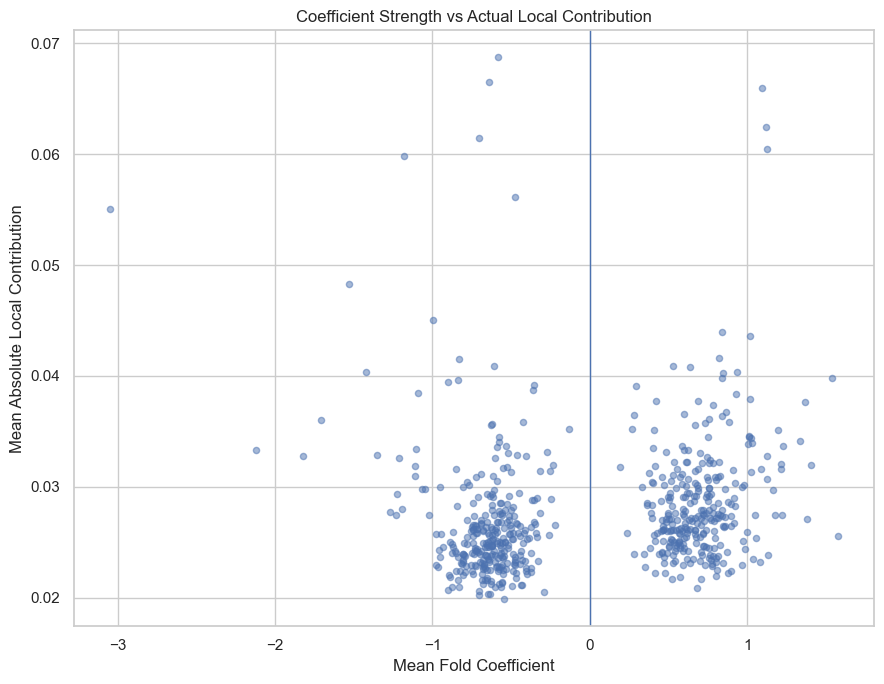

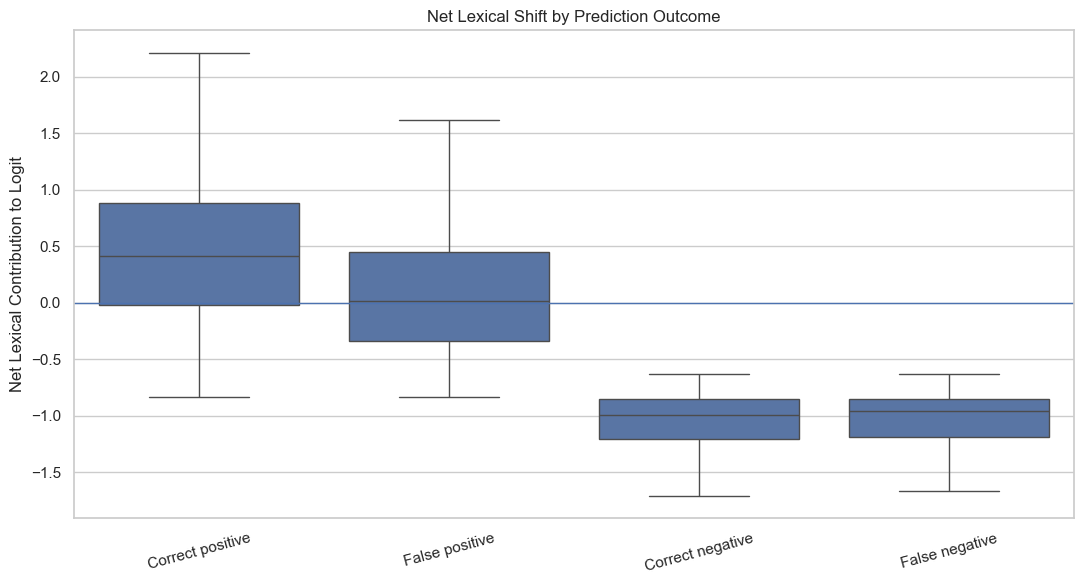

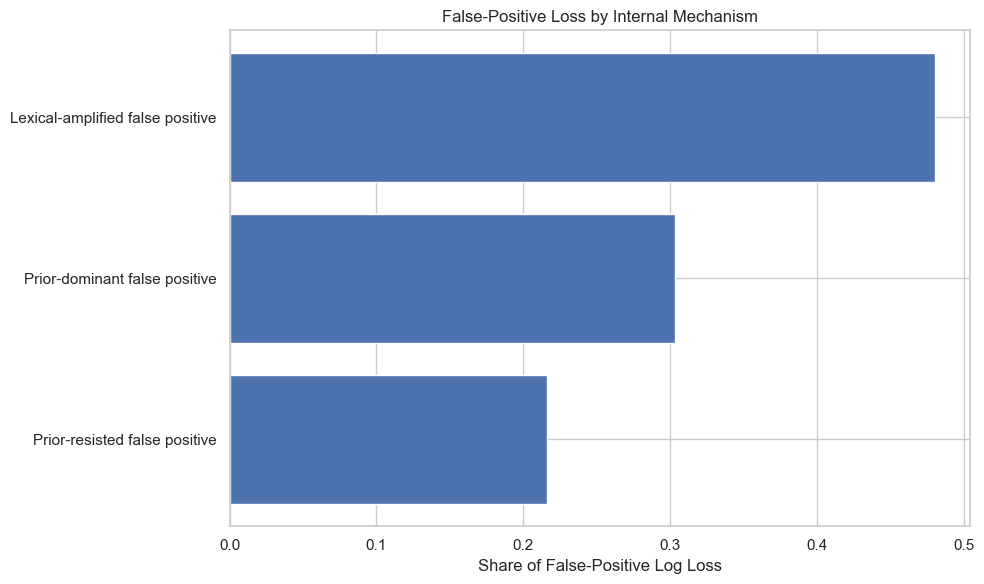

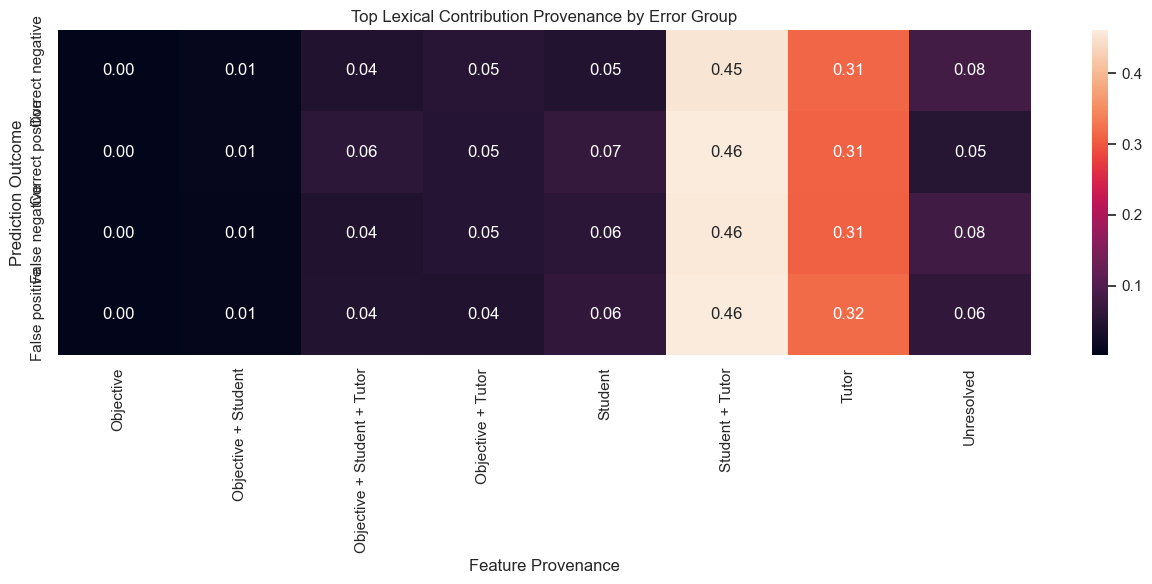

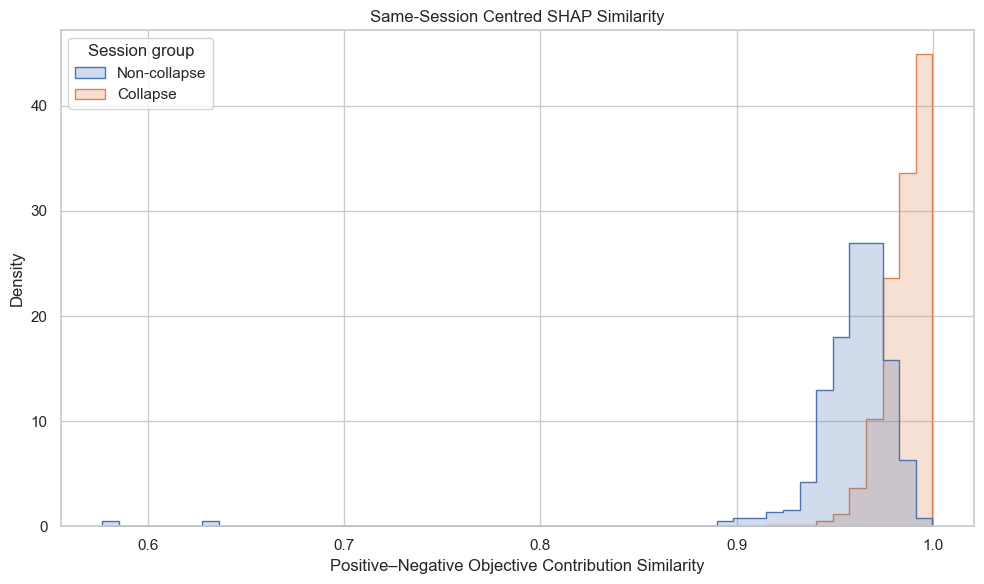

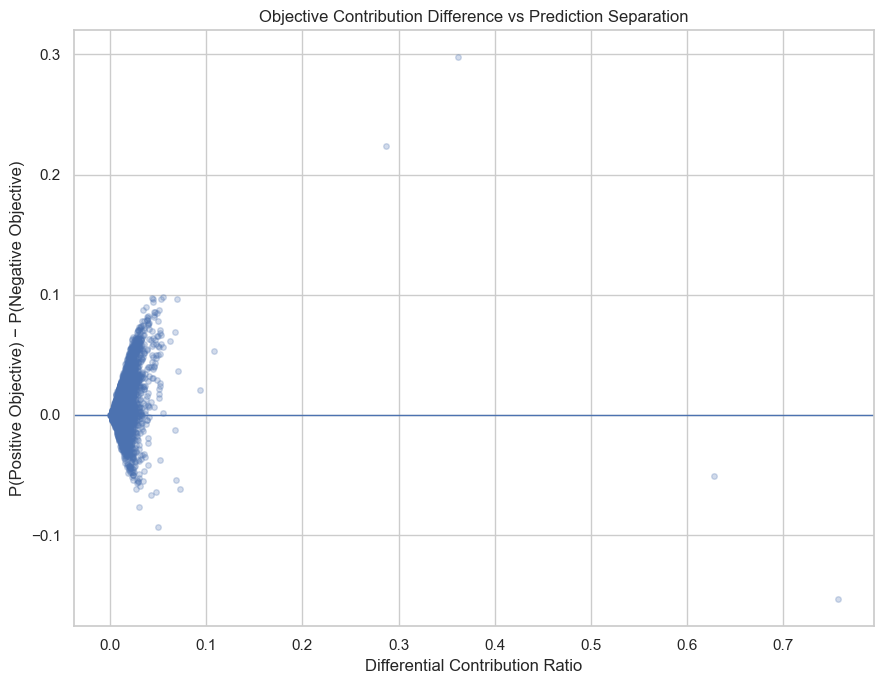

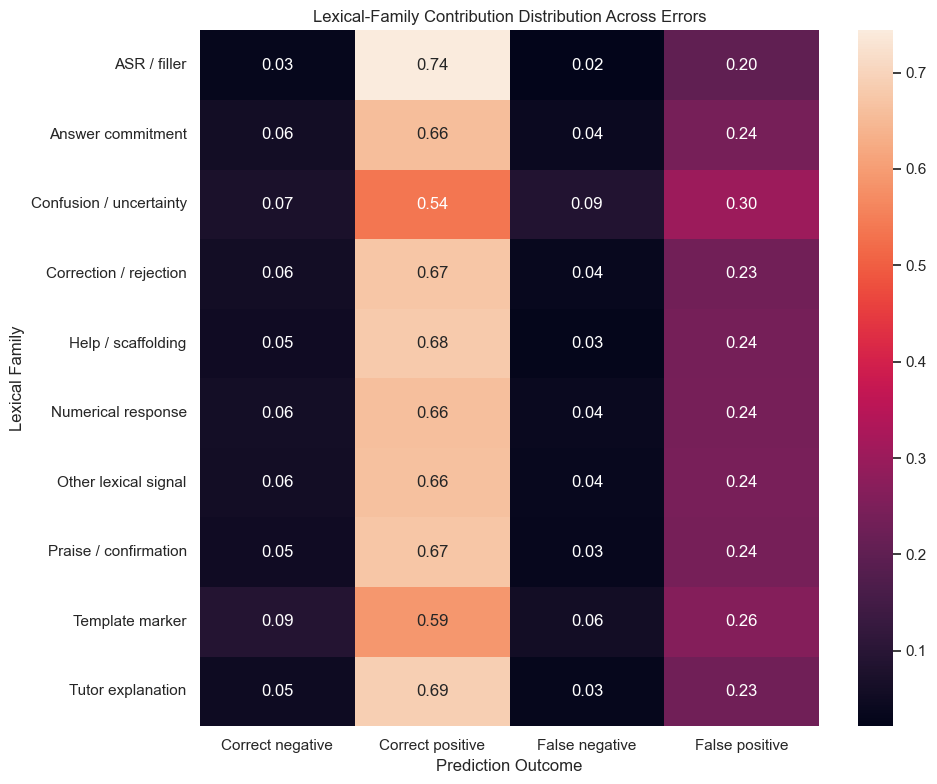

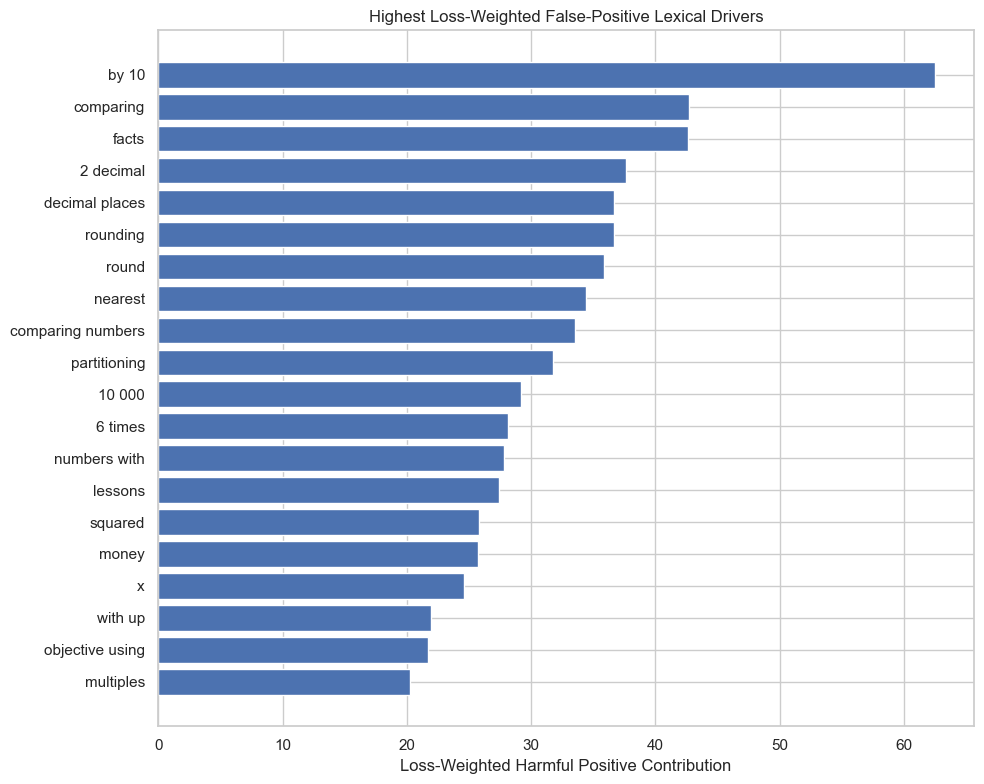

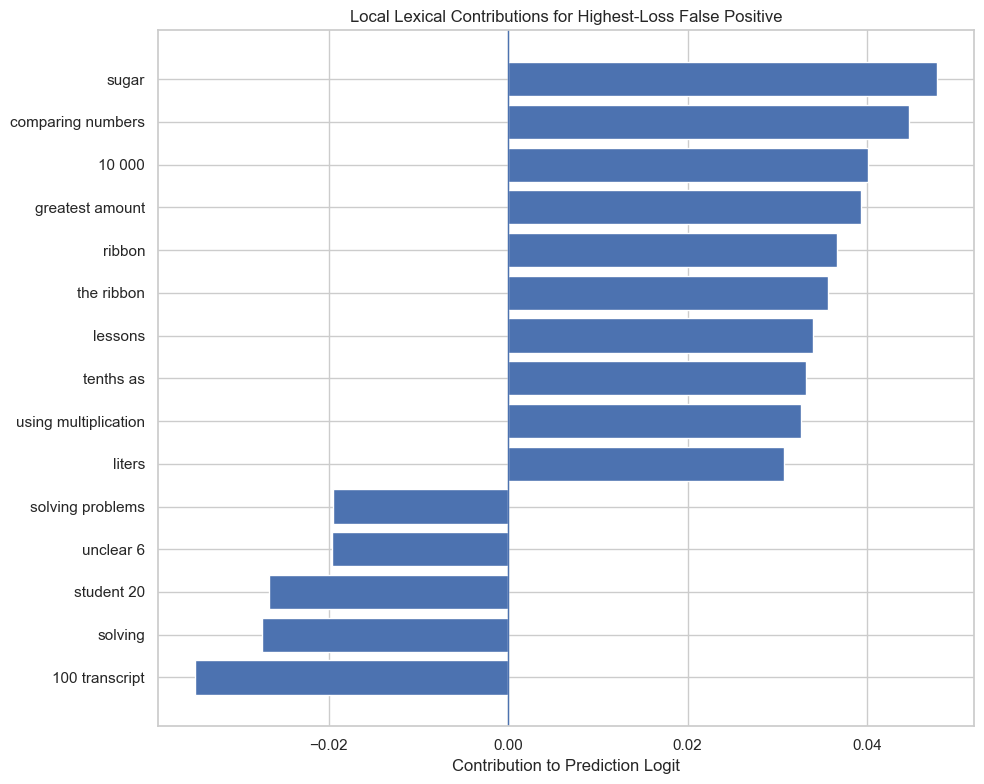

Casebook created with 100 rows.


,response_id,session_id,objective_key,learning_objective,correct,fold_id,objective_frequency,responses_per_session,objectives_per_session,mixed_label_session,objective_words,rare_objective,total_turns,total_words,session_duration_minutes,turns_per_minute,student_turns,tutor_turns,student_turn_ratio,student_word_ratio,avg_student_words_per_turn,avg_tutor_words_per_turn,student_short_turn_ratio,student_long_turn_ratio,student_numeric_turn_ratio,student_question_ratio,tutor_question_ratio,student_response_after_tutor_question_ratio,speaker_switch_rate,longest_tutor_streak_ratio,longest_student_streak_ratio,background_turn_ratio,probability,hard_prediction,true_class_probability,sample_log_loss,residual,absolute_error,confidence,transcript_length_band,turn_count_band,objective_frequency_band,student_word_ratio_band,objective_count_band,label_structure,transcript_text,student_text,tutor_text,prediction_confidence,is_misclassified,error_direction,confidence_band,loss_band,confident_false_positive,confident_false_negative,fold_prior_probability,prior_log_loss,model_regret,session_mean_probability,collapse_candidate,primary_mechanism,model_text,fold_row_index,intercept_logit,intercept_probability,raw_positive_contribution,raw_negative_contribution,raw_contribution_sum,final_logit,reconstructed_probability,centred_shap_base_value,centred_shap_sum,raw_l2_norm,raw_absolute_mass,raw_dot_background,centred_l2_norm,negative_contribution_magnitude,positive_negative_ratio,lexical_override_score,lexical_shift_direction,false_positive_mechanism,negative_evidence_present,negative_evidence_override,casebook_group,top_positive_features,top_negative_features,manual_review_note,suspected_root_cause,evidence_quality,recommended_action
0,frpmsie,dgpvezu,db7b91fd35654e6c,Dividing numbers by 100.,0,3,242,8,8,True,4,False,271,3399,44.883335,6.037876,119,150,0.439114,0.250074,7.142857,16.966667,0.563025,0.252101,0.462185,0.067227,0.586667,0.818182,0.813433,0.033333,0.025210,0.007380,0.972300,1,0.027700,3.586325,-0.972300,0.972300,0.472300,Q2,Q3,Low,Medium-low,Multiple objectives,Mixed labels,[TUTOR] Hello. [STUDENT] Hello. [TUTOR] Hello. Hi. Can you hear me? [STUDENT] Yes. [TUTOR] All right. How are you do...,"Hello. Yes. I'm doing good. Yes. I think it's pretty good because I'm really good at my timetable, so I find it quit...","Hello. Hello. Hi. Can you hear me? All right. How are you doing today, Callum? Oh, so am I pronouncing your name rig...",0.472300,True,False positive,Very high,Catastrophic,True,False,0.703182,1.214637,2.371687,0.974032,True,Mixed-label objective collapse,[OBJECTIVE] Dividing numbers by 100.\n[TRANSCRIPT] [TUTOR] Hello. [STUDENT] Hello. [TUTOR] Hello. Hi. Can you hear m...,2820,0.743685,0.677801,6.702601,-3.888057,2.814544,3.558230,0.972300,0.977930,2.580299,0.309223,10.590658,0.016000,0.277889,3.888057,1.723895,2.814544,Meaningful positive shift,Lexical-amplified false positive,True,True,Highest-loss false positives,sugar: 0.0478 | comparing numbers: 0.0447 | 10 000: 0.0401 | greatest amount: 0.0393 | ribbon: 0.0366 | the ribbon: ...,100 transcript: -0.0349 | solving: -0.0274 | student 20: -0.0267 | unclear 6: -0.0196 | solving problems: -0.0195 | ...,,,,
1,mdrmigs,amuxtst,023af9360e9657b2,Comparing numbers with up to 2 decimal places using money.,0,4,922,5,5,True,10,False,305,3520,45.099998,6.762750,150,152,0.491803,0.304545,7.146667,15.967105,0.593333,0.260000,0.313333,0.106667,0.638158,0.938144,0.870432,0.019737,0.026667,0.009836,0.970056,1,0.029944,3.508428,-0.970056,0.970056,0.470056,Q3,Q4,Frequent,Medium-high,Multiple objectives,Mixed labels,[BACKGROUND] [unclear] [TUTOR] Hello. [STUDENT] Hello. [BACKGROUND] Hello. [TUTOR] Hello. [TUTOR] Can you hear me? O...,Hello. Good. Good. We were like using [unclear] addition and figure out the perimeter of [unclear] Yeah. Okay. Hocke...,"Hello. Hello. Can you hear me? Okay, great. How are you, Declan? Okay, how was school today? All right. So in our pr...",0.470056,True,False positi

In [9]:
figures_dir = step4_dirs["15_figures"]


# --------------------------------------------------
# Plot 1: Coefficient vs actual local contribution
# --------------------------------------------------
coefficient_local_plot = (
    feature_stability
    .merge(
        local_feature_summary,
        on="feature",
        how="inner"
    )
    .nlargest(
        600,
        "total_absolute_contribution"
    )
)

plt.figure(figsize=(9, 7))

plt.scatter(
    coefficient_local_plot["mean_coefficient"],
    coefficient_local_plot[
        "mean_absolute_contribution"
    ],
    alpha=0.50,
    s=20
)

plt.axvline(0, linewidth=1)

plt.title(
    "Coefficient Strength vs Actual Local Contribution"
)
plt.xlabel("Mean Fold Coefficient")
plt.ylabel("Mean Absolute Local Contribution")
plt.tight_layout()

plt.savefig(
    figures_dir
    / "coefficient_vs_local_contribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Plot 2: Intercept and lexical shift by error
# --------------------------------------------------
plt.figure(figsize=(11, 6))

plot_sample = analysis_ledger.sample(
    min(12000, len(analysis_ledger)),
    random_state=42
)

sns.boxplot(
    data=plot_sample,
    x="error_direction",
    y="raw_contribution_sum",
    showfliers=False
)

plt.axhline(0, linewidth=1)

plt.title("Net Lexical Shift by Prediction Outcome")
plt.xlabel("")
plt.ylabel("Net Lexical Contribution to Logit")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    figures_dir
    / "lexical_shift_by_error_direction.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Plot 3: False-positive mechanism loss share
# --------------------------------------------------
fp_plot = false_positive_summary.sort_values(
    "false_positive_loss_share",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    fp_plot["false_positive_mechanism"],
    fp_plot["false_positive_loss_share"]
)

plt.title("False-Positive Loss by Internal Mechanism")
plt.xlabel("Share of False-Positive Log Loss")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    figures_dir
    / "false_positive_mechanism_loss.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Plot 4: Source contribution heatmap
# --------------------------------------------------
source_heatmap = (
    source_contribution_summary
    .groupby(
        ["error_direction", "provenance"]
    )["total_absolute_contribution"]
    .sum()
    .unstack(fill_value=0)
)

source_heatmap = source_heatmap.div(
    source_heatmap.sum(axis=1),
    axis=0
)

plt.figure(figsize=(13, 6))

sns.heatmap(
    source_heatmap,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Top Lexical Contribution Provenance by Error Group"
)
plt.xlabel("Feature Provenance")
plt.ylabel("Prediction Outcome")
plt.tight_layout()

plt.savefig(
    figures_dir
    / "source_contribution_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Plot 5: Same-session SHAP similarity
# --------------------------------------------------
similarity_plot = paired_contribution_analysis.copy()

similarity_plot["Session group"] = np.where(
    similarity_plot["collapse_candidate"],
    "Collapse",
    "Non-collapse"
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=similarity_plot,
    x="centred_shap_cosine_similarity",
    hue="Session group",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title(
    "Same-Session Centred SHAP Similarity"
)
plt.xlabel(
    "Positive–Negative Objective Contribution Similarity"
)
plt.ylabel("Density")
plt.tight_layout()

plt.savefig(
    figures_dir
    / "same_session_shap_similarity.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Plot 6: Differential contribution vs margin
# --------------------------------------------------
pair_plot_sample = paired_contribution_analysis.sample(
    min(10000, len(paired_contribution_analysis)),
    random_state=42
)

plt.figure(figsize=(9, 7))

plt.scatter(
    pair_plot_sample[
        "differential_contribution_ratio"
    ],
    pair_plot_sample["prediction_margin"],
    alpha=0.25,
    s=16
)

plt.axhline(0, linewidth=1)

plt.title(
    "Objective Contribution Difference vs Prediction Separation"
)
plt.xlabel("Differential Contribution Ratio")
plt.ylabel(
    "P(Positive Objective) − P(Negative Objective)"
)
plt.tight_layout()

plt.savefig(
    figures_dir
    / "differential_contribution_vs_margin.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Plot 7: Lexical family × error heatmap
# --------------------------------------------------
family_heatmap = (
    family_error_summary
    .pivot(
        index="lexical_family",
        columns="error_direction",
        values="total_absolute_contribution"
    )
    .fillna(0)
)

family_heatmap = family_heatmap.div(
    family_heatmap.sum(axis=1),
    axis=0
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    family_heatmap,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Lexical-Family Contribution Distribution Across Errors"
)
plt.xlabel("Prediction Outcome")
plt.ylabel("Lexical Family")
plt.tight_layout()

plt.savefig(
    figures_dir
    / "lexical_family_error_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Plot 8: Highest harmful FP features
# --------------------------------------------------
harmful_feature_plot = (
    feature_action_registry
    .sort_values(
        "harmful_false_positive",
        ascending=False
    )
    .head(20)
    .sort_values(
        "harmful_false_positive",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    harmful_feature_plot["feature"],
    harmful_feature_plot[
        "harmful_false_positive"
    ]
)

plt.title(
    "Highest Loss-Weighted False-Positive Lexical Drivers"
)
plt.xlabel("Loss-Weighted Harmful Positive Contribution")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    figures_dir
    / "highest_harmful_false_positive_features.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Plot 9: Local lexical waterfall
# --------------------------------------------------
highest_loss_fp = (
    analysis_ledger.loc[
        analysis_ledger["error_direction"].eq(
            "False positive"
        )
    ]
    .nlargest(1, "sample_log_loss")
    .iloc[0]
)

waterfall_response_id = highest_loss_fp["response_id"]

waterfall_data = (
    top_contributions.loc[
        top_contributions["response_id"].eq(
            waterfall_response_id
        )
    ]
    .nlargest(
        15,
        "absolute_contribution"
    )
    .sort_values("contribution")
)

plt.figure(figsize=(10, 8))

plt.barh(
    waterfall_data["feature"],
    waterfall_data["contribution"]
)

plt.axvline(0, linewidth=1)

plt.title(
    "Local Lexical Contributions for Highest-Loss False Positive"
)
plt.xlabel("Contribution to Prediction Logit")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    figures_dir
    / "highest_loss_fp_local_waterfall.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------------
# Build representative casebook
# --------------------------------------------------
casebook_groups = []


def add_casebook_group(data, group_name, n_rows=20):
    selected = data.nlargest(
        n_rows,
        "sample_log_loss"
    ).copy()

    selected["casebook_group"] = group_name
    casebook_groups.append(selected)


add_casebook_group(
    analysis_ledger.loc[
        analysis_ledger["error_direction"].eq(
            "False positive"
        )
    ],
    "Highest-loss false positives"
)

add_casebook_group(
    analysis_ledger.loc[
        analysis_ledger["error_direction"].eq(
            "False negative"
        )
    ],
    "Highest-loss false negatives"
)

add_casebook_group(
    analysis_ledger.loc[
        analysis_ledger["collapse_candidate"]
    ],
    "Highest-loss collapse responses"
)

add_casebook_group(
    analysis_ledger.loc[
        analysis_ledger[
            "negative_evidence_override"
        ]
    ],
    "Negative-evidence override cases"
)


reversed_response_ids = pd.unique(
    pd.concat([
        paired_contribution_analysis.loc[
            paired_contribution_analysis[
                "prediction_margin"
            ].lt(0),
            "positive_response_id"
        ],
        paired_contribution_analysis.loc[
            paired_contribution_analysis[
                "prediction_margin"
            ].lt(0),
            "negative_response_id"
        ]
    ])
)

add_casebook_group(
    analysis_ledger.loc[
        analysis_ledger["response_id"].isin(
            reversed_response_ids
        )
    ],
    "Reversed objective-pair cases"
)


casebook = pd.concat(
    casebook_groups,
    ignore_index=True
).drop_duplicates(
    ["response_id", "casebook_group"]
)


positive_feature_text = (
    top_contributions.loc[
        top_contributions["direction"].eq("Positive")
    ]
    .sort_values(["response_id", "rank"])
    .groupby("response_id")
    .apply(
        lambda group: " | ".join(
            f"{feature}: {contribution:.4f}"
            for feature, contribution in zip(
                group["feature"],
                group["contribution"]
            )
        )
    )
    .rename("top_positive_features")
)

negative_feature_text = (
    top_contributions.loc[
        top_contributions["direction"].eq("Negative")
    ]
    .sort_values(["response_id", "rank"])
    .groupby("response_id")
    .apply(
        lambda group: " | ".join(
            f"{feature}: {contribution:.4f}"
            for feature, contribution in zip(
                group["feature"],
                group["contribution"]
            )
        )
    )
    .rename("top_negative_features")
)

casebook = (
    casebook
    .merge(
        positive_feature_text,
        on="response_id",
        how="left"
    )
    .merge(
        negative_feature_text,
        on="response_id",
        how="left"
    )
)

casebook["manual_review_note"] = ""
casebook["suspected_root_cause"] = ""
casebook["evidence_quality"] = ""
casebook["recommended_action"] = ""


casebook.to_parquet(
    step4_dirs["14_casebook"]
    / "shap_casebook.parquet",
    index=False
)

casebook.to_csv(
    step4_dirs["14_casebook"]
    / "shap_casebook_review_template.csv",
    index=False
)


print(
    f"Casebook created with {len(casebook):,} rows."
)

display(casebook.head())

## Step 4 Final Decision Framework

Step 4 is complete only when the following questions can be answered with measured evidence:

| Dimension | Required Decision |
|---|---|
| Base confidence | How much probability exists before lexical evidence is added? |
| Lexical direction | Which features raise or lower confidence? |
| Source | Do influential features originate from objectives, students, tutors or shared text? |
| Error mechanism | Are false positives prior-dominant, lexical-amplified or lexical-created? |
| Objective specificity | Do same-session objectives receive different contribution profiles? |
| Collapse mechanism | Are collapsed objectives explained through almost identical shared features? |
| Stability | Do harmful and useful patterns repeat across folds? |
| Actionability | Should a signal be preserved, strengthened, separated, suppressed or semantically reinterpreted? |

## Feature Action Categories

- **PRESERVE:** stable and target-aligned signal;
- **STRENGTHEN:** useful objective-specific signal that is currently weak;
- **SEPARATE:** signal that requires speaker or context separation;
- **SUPPRESS:** stable harmful lexical shortcut;
- **SEMANTIC-REINTERPRET:** lexically relevant but context-dependent signal;
- **REVIEW:** low-support or unstable feature.

## Definition of Done

> **The baseline begins from a fold-level base probability of ______. Its confidence is driven mainly by ______ lexical evidence originating from ______. Objective-origin features contribute approximately ______ of top decision magnitude, while same-session positive and negative objectives show a contribution similarity of ______. High-loss false positives are primarily ______ driven and occur when ______ cues override ______ evidence. Therefore, the scratch model must preserve ______, separate ______ and semantically reinterpret or suppress ______.**

In [11]:
PROBABILITY_TOLERANCE = 2e-6
LOGIT_TOLERANCE = 1e-12

fidelity_summary["fidelity_pass"] = (
    fidelity_summary["maximum_probability_difference"]
    .le(PROBABILITY_TOLERANCE)
    &
    fidelity_summary["maximum_logit_difference"]
    .le(LOGIT_TOLERANCE)
)

fidelity_summary["probability_tolerance"] = (
    PROBABILITY_TOLERANCE
)

fidelity_summary["logit_tolerance"] = (
    LOGIT_TOLERANCE
)

fidelity_summary.to_csv(
    step4_dirs["03_oof_contributions"]
    / "explanation_fidelity.csv",
    index=False
)

print(
    "Global maximum probability difference:",
    f"{fidelity_summary['maximum_probability_difference'].max():.12f}"
)

print(
    "All folds passed:",
    fidelity_summary["fidelity_pass"].all()
)

display(fidelity_summary)

Global maximum probability difference: 0.000001007613
All folds passed: True


,fold_id,maximum_probability_difference,mean_probability_difference,maximum_logit_difference,fidelity_pass,probability_tolerance,logit_tolerance
0,0,0.000001,0.000000,0.000000,True,0.000002,0.000000
1,1,0.000001,0.000000,0.000000,True,0.000002,0.000000
2,2,0.000001,0.000000,0.000000,True,0.000002,0.000000
3,3,0.000001,0.000000,0.000000,True,0.000002,0.000000
4,4,0.000001,0.000000,0.000000,True,0.000002,0.000000


In [10]:
# --------------------------------------------------
# Extract final measured values
# --------------------------------------------------
mean_base_probability = (
    analysis_ledger[
        "intercept_probability"
    ].mean()
)

mean_lexical_shift = (
    analysis_ledger[
        "raw_contribution_sum"
    ].mean()
)

mean_objective_share = (
    response_source_summary[
        "objective_top_absolute_share"
    ].mean()
)

mean_student_share = (
    response_source_summary[
        "student_top_absolute_share"
    ].mean()
)

mean_tutor_share = (
    response_source_summary[
        "tutor_top_absolute_share"
    ].mean()
)


collapse_similarity = (
    collapse_comparison.loc[
        collapse_comparison[
            "collapse_candidate"
        ].eq(True),
        "mean_centred_shap_similarity"
    ].iloc[0]
)

noncollapse_similarity = (
    collapse_comparison.loc[
        collapse_comparison[
            "collapse_candidate"
        ].eq(False),
        "mean_centred_shap_similarity"
    ].iloc[0]
)

collapse_differential_ratio = (
    collapse_comparison.loc[
        collapse_comparison[
            "collapse_candidate"
        ].eq(True),
        "mean_differential_ratio"
    ].iloc[0]
)

noncollapse_differential_ratio = (
    collapse_comparison.loc[
        collapse_comparison[
            "collapse_candidate"
        ].eq(False),
        "mean_differential_ratio"
    ].iloc[0]
)


dominant_fp_row = (
    false_positive_summary
    .sort_values(
        "false_positive_loss_share",
        ascending=False
    )
    .iloc[0]
)

dominant_fp_mechanism = (
    dominant_fp_row[
        "false_positive_mechanism"
    ]
)

dominant_fp_loss_share = (
    dominant_fp_row[
        "false_positive_loss_share"
    ]
)

negative_override_rate = (
    analysis_ledger.loc[
        analysis_ledger[
            "error_direction"
        ].eq("False positive"),
        "negative_evidence_override"
    ].mean()
)


stable_harmful_features = (
    feature_action_registry.loc[
        feature_action_registry[
            "recommended_action"
        ].eq("SUPPRESS")
    ]
)

stable_useful_features = (
    feature_action_registry.loc[
        feature_action_registry[
            "recommended_action"
        ].isin(["PRESERVE", "STRENGTHEN"])
    ]
)

semantic_features = (
    feature_action_registry.loc[
        feature_action_registry[
            "recommended_action"
        ].eq("SEMANTIC-REINTERPRET")
    ]
)


top_harmful_feature_names = ", ".join(
    feature_action_registry.sort_values(
        "harmful_false_positive",
        ascending=False
    )["feature"]
    .head(10)
    .astype(str)
    .tolist()
)

top_useful_feature_names = ", ".join(
    feature_action_registry.sort_values(
        "total_useful_responsibility",
        ascending=False
    )["feature"]
    .head(10)
    .astype(str)
    .tolist()
)


# --------------------------------------------------
# Step 4 scorecard
# --------------------------------------------------
lexical_signal_scorecard = pd.DataFrame([
    {
        "Dimension": "Explanation fidelity",
        "Metric": "Maximum OOF probability reconstruction error",
        "Value": fidelity_summary[
            "maximum_probability_difference"
        ].max(),
        "Interpretation": (
            "Exact contribution reconstruction"
            if fidelity_summary[
                "fidelity_pass"
            ].all()
            else "Explanation pipeline requires review"
        )
    },
    {
        "Dimension": "Base confidence",
        "Metric": "Mean fold intercept probability",
        "Value": mean_base_probability,
        "Interpretation": (
            "Strong positive base confidence"
            if mean_base_probability > 0.60
            else "Moderate base confidence"
        )
    },
    {
        "Dimension": "Objective contribution",
        "Metric": "Mean objective share of top contribution magnitude",
        "Value": mean_objective_share,
        "Interpretation": (
            "Weak objective lexical control"
            if mean_objective_share < 0.20
            else "Meaningful objective contribution"
        )
    },
    {
        "Dimension": "Student contribution",
        "Metric": "Mean student share of top contribution magnitude",
        "Value": mean_student_share,
        "Interpretation": (
            "Student evidence is visible"
            if mean_student_share >= 0.20
            else "Student evidence is underrepresented"
        )
    },
    {
        "Dimension": "Tutor contribution",
        "Metric": "Mean tutor share of top contribution magnitude",
        "Value": mean_tutor_share,
        "Interpretation": (
            "Tutor language is highly influential"
            if mean_tutor_share >= 0.30
            else "Tutor contribution is moderate"
        )
    },
    {
        "Dimension": "Collapse explanation",
        "Metric": "Collapse-session centred SHAP similarity",
        "Value": collapse_similarity,
        "Interpretation": (
            "Highly similar objective explanations"
            if collapse_similarity >= 0.90
            else "Meaningful objective differentiation"
        )
    },
    {
        "Dimension": "Non-collapse explanation",
        "Metric": "Non-collapse centred SHAP similarity",
        "Value": noncollapse_similarity,
        "Interpretation": (
            "More differentiated than collapse sessions"
            if noncollapse_similarity < collapse_similarity
            else "No clear explanation difference"
        )
    },
    {
        "Dimension": "False-positive mechanism",
        "Metric": "Dominant FP mechanism loss share",
        "Value": dominant_fp_loss_share,
        "Interpretation": dominant_fp_mechanism
    },
    {
        "Dimension": "Negative evidence",
        "Metric": "Negative-evidence override rate in false positives",
        "Value": negative_override_rate,
        "Interpretation": (
            "Negative cues are frequently overridden"
            if negative_override_rate >= 0.30
            else "Negative-cue override is limited"
        )
    }
])


# --------------------------------------------------
# Hypothesis register
# --------------------------------------------------
hypothesis_results = pd.DataFrame([
    {
        "Hypothesis": "H23",
        "Statement": (
            "Base confidence and shared transcript cues "
            "dominate lexical prediction."
        ),
        "Result": (
            "Supported"
            if mean_base_probability > 0.60
            else "Partially supported"
        )
    },
    {
        "Hypothesis": "H24",
        "Statement": (
            "Objective-origin features contribute "
            "a small share of the decision."
        ),
        "Result": (
            "Supported"
            if mean_objective_share < 0.20
            else "Not supported"
        )
    },
    {
        "Hypothesis": "H26",
        "Statement": (
            "Positive and negative objectives from the "
            "same session have highly similar explanations."
        ),
        "Result": (
            "Supported"
            if paired_contribution_analysis[
                "centred_shap_cosine_similarity"
            ].mean() >= 0.85
            else "Partially supported"
        )
    },
    {
        "Hypothesis": "H27",
        "Statement": (
            "Collapse sessions have higher explanation "
            "similarity than non-collapse sessions."
        ),
        "Result": (
            "Supported"
            if collapse_similarity >
            noncollapse_similarity
            else "Not supported"
        )
    },
    {
        "Hypothesis": "H29",
        "Statement": (
            "Positive evidence frequently overrides "
            "negative lexical evidence in false positives."
        ),
        "Result": (
            "Supported"
            if negative_override_rate >= 0.30
            else "Partially supported"
        )
    },
    {
        "Hypothesis": "H32",
        "Statement": (
            "Many high-loss false positives are "
            "lexically amplified or created."
        ),
        "Result": (
            "Supported"
            if dominant_fp_mechanism in [
                "Lexical-amplified false positive",
                "Lexical-created false positive"
            ]
            else "Partially supported"
        )
    },
    {
        "Hypothesis": "H33",
        "Statement": (
            "Greater contribution differentiation is "
            "associated with better objective separation."
        ),
        "Result": (
            "Supported"
            if pair_relationships.loc[
                pair_relationships[
                    "Relationship"
                ].eq(
                    "Differential contribution ratio vs prediction margin"
                ),
                "Spearman correlation"
            ].iloc[0] > 0
            else "Not supported"
        )
    }
])


# --------------------------------------------------
# Architecture decisions
# --------------------------------------------------
architecture_requirements = pd.DataFrame([
    {
        "Requirement": (
            "Objective-conditioned relevant-turn retrieval"
        ),
        "Evidence": (
            f"Objective top-contribution share="
            f"{mean_objective_share:.4f}; "
            f"collapse SHAP similarity="
            f"{collapse_similarity:.4f}"
        ),
        "Priority": "Critical"
    },
    {
        "Requirement": (
            "Separate student and tutor evidence encoders"
        ),
        "Evidence": (
            f"Student share={mean_student_share:.4f}; "
            f"tutor share={mean_tutor_share:.4f}"
        ),
        "Priority": "Critical"
    },
    {
        "Requirement": (
            "Within-session contrastive objective loss"
        ),
        "Evidence": (
            f"Collapse differential ratio="
            f"{collapse_differential_ratio:.4f}; "
            f"non-collapse ratio="
            f"{noncollapse_differential_ratio:.4f}"
        ),
        "Priority": "Critical"
    },
    {
        "Requirement": (
            "Negative-evidence-aware confidence gating"
        ),
        "Evidence": (
            f"False-positive negative-evidence "
            f"override rate={negative_override_rate:.4f}"
        ),
        "Priority": "High"
    },
    {
        "Requirement": (
            "Semantic reinterpretation of lexical overlap"
        ),
        "Evidence": (
            f"{len(semantic_features):,} features were "
            f"classified as context-dependent."
        ),
        "Priority": "High"
    },
    {
        "Requirement": (
            "Suppress stable harmful lexical shortcuts"
        ),
        "Evidence": (
            f"{len(stable_harmful_features):,} features "
            f"were classified as suppression candidates."
        ),
        "Priority": "High"
    },
    {
        "Requirement": (
            "Preserve stable target-aligned lexical signals"
        ),
        "Evidence": (
            f"{len(stable_useful_features):,} features "
            f"were classified as preserve or strengthen."
        ),
        "Priority": "High"
    },
    {
        "Requirement": (
            "Probability calibration after ranking improvement"
        ),
        "Evidence": (
            f"Dominant false-positive mechanism: "
            f"{dominant_fp_mechanism}."
        ),
        "Priority": "High"
    }
])


# --------------------------------------------------
# Final Step 4 report
# --------------------------------------------------
report_text = f"""# Step 4 — Lexical Decision-Mechanism Report

## Explanation Fidelity

All OOF responses were explained using their own fold-specific model.

- Maximum probability reconstruction error:
  {fidelity_summary["maximum_probability_difference"].max():.12f}
- All folds passed the fidelity gate:
  {bool(fidelity_summary["fidelity_pass"].all())}

## Base Confidence and Lexical Shift

- Mean fold intercept probability:
  {mean_base_probability:.6f}
- Mean net lexical shift:
  {mean_lexical_shift:.6f}

## Contribution Provenance

The source shares below refer to the top-{TOP_K} active positive and
top-{TOP_K} active negative contributions per response.

- Mean objective-origin share:
  {mean_objective_share:.6f}
- Mean student-origin share:
  {mean_student_share:.6f}
- Mean tutor-origin share:
  {mean_tutor_share:.6f}

## Same-Session Objective Explanations

- Collapse-session centred SHAP similarity:
  {collapse_similarity:.6f}
- Non-collapse centred SHAP similarity:
  {noncollapse_similarity:.6f}
- Collapse differential contribution ratio:
  {collapse_differential_ratio:.6f}
- Non-collapse differential contribution ratio:
  {noncollapse_differential_ratio:.6f}

## False-Positive Mechanism

- Dominant false-positive mechanism:
  {dominant_fp_mechanism}
- Share of false-positive loss from this mechanism:
  {dominant_fp_loss_share:.6f}
- Negative-evidence override rate:
  {negative_override_rate:.6f}

## Feature Responsibility

- Stable harmful suppression candidates:
  {len(stable_harmful_features):,}
- Stable useful preserve/strengthen candidates:
  {len(stable_useful_features):,}
- Context-dependent semantic reinterpretation candidates:
  {len(semantic_features):,}

Top harmful false-positive features:

{top_harmful_feature_names}

Top useful lexical features:

{top_useful_feature_names}

## Architecture Decision

The next model should use objective-conditioned dialogue retrieval,
separate student and tutor evidence channels, within-session contrastive
objective modelling, negative-evidence-aware confidence control and
semantic interpretation of context-dependent lexical overlap.

Contribution subtraction and text masking are diagnostic counterfactuals.
They are not deployable OOF model scores.
"""


with open(
    step4_dirs["16_final_decision"]
    / "step4_lexical_mechanism_report.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(report_text)


# Save final outputs
lexical_signal_scorecard.to_csv(
    step4_dirs["16_final_decision"]
    / "lexical_signal_scorecard.csv",
    index=False
)

hypothesis_results.to_csv(
    step4_dirs["16_final_decision"]
    / "hypothesis_results.csv",
    index=False
)

architecture_requirements.to_csv(
    step4_dirs["16_final_decision"]
    / "architecture_requirements.csv",
    index=False
)

feature_action_registry.to_csv(
    step4_dirs["16_final_decision"]
    / "feature_action_registry.csv",
    index=False
)


final_outputs = pd.DataFrame({
    "Output": [
        "Fold backgrounds",
        "Global coefficient stability",
        "OOF contribution ledger",
        "Explanation fidelity",
        "False-positive mechanisms",
        "Top-feature provenance",
        "Objective identity analysis",
        "Same-session contribution pairs",
        "Collapse lexical mechanism",
        "Lexical-family responsibility",
        "Diagnostic family ablations",
        "SHAP casebook",
        "Lexical signal scorecard",
        "Feature action registry",
        "Architecture requirements",
        "Final Step 4 report"
    ],
    "Folder": [
        "01_fold_backgrounds",
        "02_global_coefficients",
        "03_oof_contributions",
        "03_oof_contributions",
        "04_intercept_lexical_decomposition",
        "05_source_provenance",
        "06_objective_identity",
        "08_same_session_pairs",
        "09_collapse_mechanism",
        "10_lexical_families",
        "12_counterfactual_masking",
        "14_casebook",
        "16_final_decision",
        "16_final_decision",
        "16_final_decision",
        "16_final_decision"
    ]
})


print("Step 4 completed successfully.")

display(lexical_signal_scorecard)
display(hypothesis_results)
display(architecture_requirements)
display(final_outputs)

Step 4 completed successfully.


,Dimension,Metric,Value,Interpretation
0,Explanation fidelity,Maximum OOF probability reconstruction error,0.000001,Explanation pipeline requires review
1,Base confidence,Mean fold intercept probability,0.675927,Strong positive base confidence
2,Objective contribution,Mean objective share of top contribution magnitude,0.105993,Weak objective lexical control
3,Student contribution,Mean student share of top contribution magnitude,0.584395,Student evidence is visible
4,Tutor contribution,Mean tutor share of top contribution magnitude,0.870699,Tutor language is highly influential
5,Collapse explanation,Collapse-session centred SHAP similarity,0.985832,Highly similar objective explanations
6,Non-collapse explanation,Non-collapse centred SHAP similarity,0.958506,More differentiated than collapse sessions
7,False-positive mechanism,Dominant FP mechanism loss share,0.480477,Lexical-amplified false positive
8,Negative evidence,Negative-evidence override rate in false positives,1.000000,Negative cues are frequently overridden


,Hypothesis,Statement,Result
0,H23,Base confidence and shared transcript cues dominate lexical prediction.,Supported
1,H24,Objective-origin features contribute a small share of the decision.,Supported
2,H26,Positive and negative objectives from the same session have highly similar explanations.,Supported
3,H27,Collapse sessions have higher explanation similarity than non-collapse sessions.,Supported
4,H29,Positive evidence frequently overrides negative lexical evidence in false positives.,Supported
5,H32,Many high-loss false positives are lexically amplified or created.,Supported
6,H33,Greater contribution differentiation is associated with better objective separation.,Supported


,Requirement,Evidence,Priority
0,Objective-conditioned relevant-turn retrieval,Objective top-contribution share=0.1060; collapse SHAP similarity=0.9858,Critical
1,Separate student and tutor evidence encoders,Student share=0.5844; tutor share=0.8707,Critical
2,Within-session contrastive objective loss,Collapse differential ratio=0.0128; non-collapse ratio=0.0311,Critical
3,Negative-evidence-aware confidence gating,False-positive negative-evidence override rate=1.0000,High
4,Semantic reinterpretation of lexical overlap,"1,047 features were classified as context-dependent.",High
5,Suppress stable harmful lexical shortcuts,147 features were classified as suppression candidates.,High
6,Preserve stable target-aligned lexical signals,108 features were classified as preserve or strengthen.,High
7,Probability calibration after ranking improvement,Dominant false-positive mechanism: Lexical-amplified false positive.,High


,Output,Folder
0,Fold backgrounds,01_fold_backgrounds
1,Global coefficient stability,02_global_coefficients
2,OOF contribution ledger,03_oof_contributions
3,Explanation fidelity,03_oof_contributions
4,False-positive mechanisms,04_intercept_lexical_decomposition
5,Top-feature provenance,05_source_provenance
6,Objective identity analysis,06_objective_identity
7,Same-session contribution pairs,08_same_session_pairs
8,Collapse lexical mechanism,09_collapse_mechanism
9,Lexical-family responsibility,10_lexical_families


# Step 4 — SHAP & Lexical Contribution: Key Insights

## 1. Core Model Behaviour

| Finding | Result | Meaning |
|---|---:|---|
| Base probability before lexical evidence | **0.6759** | Model শুরু থেকেই positive prediction-এর দিকে biased |
| Objective-related contribution | **≈10.6%** | Objective decision-এর ছোট অংশ নিয়ন্ত্রণ করে |
| Collapse-session SHAP similarity | **0.9858** | Correct ও incorrect objectives প্রায় একই explanation পায় |
| Non-collapse SHAP similarity | **0.9585** | Objective differentiation কিছুটা বেশি |
| False-positive share of total loss | **53.05%** | সবচেয়ে বড় error source হলো false positive |

---

## 2. False-Positive Mechanism

| Mechanism | FP Loss Share | Total OOF Loss Share |
|---|---:|---:|
| Lexical-amplified false positive | **48.05%** | **25.49%** |
| Prior-dominant false positive | **30.36%** | **16.10%** |
| Prior-resisted false positive | **21.59%** | **11.45%** |

- Model-এর positive prior অনেক negative responses-কেও positive রাখে।
- কিছু transcript lexical cues probability অতিরিক্ত বাড়িয়ে দেয়।
- Negative evidence থাকলেও অনেক সময় সেটি prediction নিচে নামানোর জন্য যথেষ্ট নয়।

---

## 3. Collapse vs Non-Collapse Sessions

| Metric | Non-Collapse | Collapse |
|---|---:|---:|
| Mean prediction margin | **0.0364** | **0.0056** |
| Pairwise ranking accuracy | **84.34%** | **66.43%** |
| Mean pair loss | **0.7081** | **0.8763** |
| Differential contribution ratio | **0.0311** | **0.0128** |

- Collapse sessions-এ objective পরিবর্তন হলেও contribution profile প্রায় একই থাকে।
- Correct এবং incorrect objectives-এর probability separation খুব ছোট।
- Objective-specific lexical difference যত বাড়ে, prediction separation তত ভালো হয়।
- এই pattern পাঁচটি fold এবং bootstrap analysis-এ stable ছিল।

---

## 4. Lexical Evidence Findings

- Model প্রধানত **shared transcript এবং tutor-related language** ব্যবহার করছে।
- Objective text মূলত **objective difficulty prior** হিসেবে কাজ করছে।
- Topic words যেমন *rounding, comparing, decimal places, partitioning* probability বাড়াচ্ছে।
- অনেক positive ও negative feature student mastery নয়; বরং curriculum/topic identity নির্দেশ করছে।
- Tutor praise বা correct solution vocabulary সবসময় independent student understanding বোঝায় না।
- Student ও tutor-এর একই শব্দ model আলাদা semantic role হিসেবে বুঝতে পারছে না।

---

## Final Insight

> **The baseline is a positively biased, transcript-dominated session model. It uses objective text mainly as an implicit difficulty prior rather than interpreting the transcript separately for each objective.**

## Next Model Requirements

- Objective-conditioned relevant-turn retrieval
- Separate student and tutor evidence channels
- Pre-feedback and post-feedback separation
- Within-session contrastive objective loss
- Explicit fold-safe objective difficulty prior
- Negative-evidence-aware confidence control
- Semantic interpretation of praise, correction and tutor intervention